# LongMemEval: incremental vs. re-ingested secondary-model memory in the RWKV→Llama pairing

**What this extends.** `longmemeval_memorag_ext_new.ipynb` built a pairing: RWKV-7 G1 (the
**secondary** model) sees the user's query first, recalls what it can from its recurrent state, and
hands back a draft answer plus MemoRAG-style clues (`sur`/`span`/`qa`); a Llama model (the
**primary** generator) reads those clues — either directly (`memonly`) or as retrieval queries over
the session corpus (`memorag_top5`) — and writes the final answer. That notebook found (a) a bigger
RWKV memory model is not a better one, and (b) the pairing loses to plain retrieval once the
primary model is strong (8B reader: `memorag_top10` 0.42 vs. `rag_q_top10` 0.44 and `rag_q_top5`
0.55, p≤0.029). Honest negatives, but an incremental delta on someone else's method.

**What this notebook changes: how the secondary model's memory is built.** ext_new rebuilds RWKV's
state from the *entire* ~115k-token history for every single query. A recurrent state is fixed-size
and can instead be folded forward one session at a time and **persisted between queries** — the way
a deployed assistant actually receives conversation. This notebook asks:

> Does the secondary model's memory have to be rebuilt per query, or can it be maintained
> incrementally — and does that change the clues it hands back, and therefore what the primary
> model answers?

**The pairing itself never changes.** Every arm in this notebook is RWKV-first, Llama-second: RWKV
always sees the query before the generator does (`probe_memorag` prefixes the question and date),
always returns clues/a draft rather than a final answer, and a Llama model always writes the
answer. There is no RWKV-alone arm. What varies is (1) the **policy** used to build/maintain RWKV's
state — `stream` (one persisted state, folded forward, probed from a clone), `bank` (several
snapshots taken during that one pass, clues unioned), `segment` (state reset periodically to stay
inside RWKV's trained context) — versus the `reingest` baseline (ext_new's own approach: rebuild
from scratch every time), and (2) the **route** the clues take to the generator (`memonly` vs.
`memorag_top{5,10}`).

## Stated up front, not discovered later

1. **The equivalence between `stream` and `reingest` is a theorem, not a finding, and is treated as
   a gate.** RWKV-7's update is a deterministic fold `s_t = f(s_{t-1}, x_t)`; any bracketing of the
   input gives the same state in exact arithmetic, by induction on function composition. What is
   *not* a theorem — fp16 reduction-order drift over ~50 session boundaries, greedy-decode
   divergence from a single flipped logit, state-aliasing bugs, disk round-trip fidelity — is
   measured, not assumed (Gates G6–G10 below). **A tight `stream ≈ reingest` match is the success
   condition of this notebook, not a null result to explain away.**
2. **`memonly` has almost no headroom.** ext_new measured `closedbook` = 0.08 and
   `memonly__g1i-2.9b` = 0.14–0.15, confidence intervals overlapping. The decay analysis therefore
   leads with a judge-free **evidence-retrieval recall** metric (real headroom —
   `new_method.ipynb` measured plain-question BM25 at 20/20 top-10) and treats end-to-end accuracy
   as the secondary panel.
3. **Retrieval may fully mask state decay.** If `memorag_top5` accuracy is flat in Δ while
   retrieval recall falls, that is the route-interaction result this notebook is built to surface —
   "retrieval repairs a degraded state" — not a broken experiment.
4. **The state is 7–45× past RWKV-7 G1's trained context (16,384 tokens) before decay even starts**
   (a native ~115k-token haystack is ~7×; a merged mega-stream is ~45–60×). Decay may look flat
   simply because the state saturated long before the interesting part of the stream. `segment`
   exists to separate "recurrent memory doesn't help" from "this checkpoint's capacity was
   overrun" — the same logic as ext_new's `s_trunc16k` ablation.
5. **Stage 2 (merged mega-streams) is its own universe.** Merging several questions' haystacks into
   one very long stream is what makes large-Δ decay and large-scale amortization measurable, but
   ~80% of merged questions acquire a co-merged session containing their gold answer's key terms —
   this is a strictly harder recall problem for reasons unrelated to state persistence. **Stage-2
   accuracy is not comparable to Stage-1, to ext_new, or to any published LongMemEval number**, and
   every Stage-2 figure says so.
6. **`g1i-7.2b` is wired into the ladder but off by default** — ext_new already measured it
   underperforming 1.5B/2.9B on this task family, and re-confirming that is not worth the GPU time
   it costs.

## Deviations from the paper / from ext_new (continuing ext_new's numbering)

- **#12** — the streaming protocol, checkpointing, state persistence, and mega-stream construction
  described above have no counterpart in the original LongMemEval paper or in ext_new; they are
  this notebook's own contribution and are gated far more heavily than a straight transcription
  would be (Gates G2, G6–G13, G17).
- **#13** — `closedbook` / `oracle_con` / `s_con` / `rag_q_top5` baseline labels are **imported**
  from ext_new's `ext/results/judged.jsonl` rather than re-run, since they depend on nothing this
  notebook changes. This is a deliberate cost saving, not a shortcut on correctness: importing is
  possible only because both notebooks share the exact same 100-question subset (Gate G4) and the
  same reader specs.
- **#14** — `bank`'s clue set is the union of the `qa` (draft-answer) probe text across its retained
  checkpoints, not `sur`+`span`, because those are only decoded at the final checkpoint under this
  notebook's decode budget (Section 12). This is flagged explicitly because it means `bank` differs
  from `stream` in *which clue type* reaches the generator, not only in how much memory is
  retained — a real limitation of the comparison, stated here rather than hidden in a caption.


## Section 1: Environment

In [2]:
import os, sys, subprocess, json, math, time, hashlib, random, re, gc
from pathlib import Path
from datetime import datetime, timezone

if "google.colab" not in sys.modules:
    raise RuntimeError(
        "This notebook is Colab-only -- there is no local execution path. Open it in Google "
        "Colab (Runtime > Change runtime type > pick a GPU, ideally A100) and run it there.")

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

# SAME Drive folder longmemeval_memorag.ipynb uses -- this is how its cached RWKV-2.9B memory and
# Stella embeddings get reused without sharing any Python state with that notebook.
REPO = Path("/content/drive/MyDrive/lme_memorag")
REPO.mkdir(parents=True, exist_ok=True)

LOG_PATH = REPO / "logs" / "run_stream.log"   # separate log file -- keeps the two notebooks' logs
LOG_PATH.parent.mkdir(parents=True, exist_ok=True)

class _Tee:
    def __init__(self, *streams):
        self.streams = streams
    def write(self, data):
        for s in self.streams:
            s.write(data); s.flush()
    def flush(self):
        for s in self.streams:
            s.flush()
    def __getattr__(self, name):
        if name == "streams":
            raise AttributeError(name)
        return getattr(self.streams[0], name)
    def fileno(self):
        for s in self.streams:
            try:
                return s.fileno()
            except (AttributeError, OSError, ValueError):
                continue
        raise OSError("no underlying fileno available")

if not isinstance(sys.stdout, _Tee):
    _log_fh = open(LOG_PATH, "a", encoding="utf-8")
    _log_fh.write(f"\n{'='*80}\n[{datetime.now(timezone.utc).isoformat()}] session (re)started\n{'='*80}\n")
    _log_fh.flush()
    sys.stdout = _Tee(sys.stdout, _log_fh)
    sys.stderr = _Tee(sys.stderr, _log_fh)

def detect_gpu():
    try:
        out = subprocess.run(
            ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader,nounits"],
            capture_output=True, text=True, check=True).stdout.strip()
    except (FileNotFoundError, subprocess.CalledProcessError):
        return None, 0.0
    if not out:
        return None, 0.0
    name, mib = out.splitlines()[0].split(",")
    return name.strip(), float(mib) / 1024

GPU_NAME, GPU_VRAM_GB = detect_gpu()
if GPU_NAME is None:
    raise RuntimeError("No GPU on this runtime. Runtime > Change runtime type > pick a GPU "
                       "(A100 recommended), then Runtime > Restart session and re-run from the top.")

CAN_RUN_LOCAL_READER = GPU_VRAM_GB >= 20     # Llama-3.2-1B via vLLM, generous headroom
CAN_RUN_RWKV         = GPU_VRAM_GB >= 16     # up to the 7.2B rung, fp16 (~14.4GB resident)
CAN_RUN_EMBEDDINGS   = GPU_VRAM_GB >= 8      # Stella V5 1.5B

print(f"Drive:      mounted, working folder {REPO}  (shared with longmemeval_memorag.ipynb)")
print(f"Log file:   {LOG_PATH}")
print(f"GPU:        {GPU_NAME}  ({GPU_VRAM_GB:.1f} GB)")
print(f"Local reader (Llama-3.2-1B via vLLM): {'yes' if CAN_RUN_LOCAL_READER else 'NO'}")
print(f"RWKV-7 G1 ladder (up to 7.2B):         {'yes' if CAN_RUN_RWKV else 'NO'}")
print(f"Stella V5 embeddings:                  {'yes' if CAN_RUN_EMBEDDINGS else 'NO'}")
if GPU_VRAM_GB < 38:
    print("\n  NOTE: designed and timed against an A100-40GB. This GPU has less VRAM -- Section "
          "10's per-model Gate B throughput estimate is the number to trust over any estimate in "
          "this notebook's own prose.")

Mounted at /content/drive
Drive:      mounted, working folder /content/drive/MyDrive/lme_memorag  (shared with longmemeval_memorag.ipynb)
Log file:   /content/drive/MyDrive/lme_memorag/logs/run_stream.log
GPU:        NVIDIA A100-SXM4-80GB  (80.0 GB)
Local reader (Llama-3.2-1B via vLLM): yes
RWKV-7 G1 ladder (up to 7.2B):         yes
Stella V5 embeddings:                  yes


## Section 2: Dependencies

In [3]:
INSTALL = True   # set False on a re-run to skip

def pip_install(*args):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *args], check=True)

if INSTALL:
    if "torch" in sys.modules:
        raise RuntimeError(
            "torch is already imported -- Runtime > Restart session and run from the top. A torch "
            "already in sys.modules shadows the one this cell installs.")

    if CAN_RUN_LOCAL_READER:
        pip_install("vllm==0.28.0", "torch==2.13.0+cu132", "torchvision==0.28.0+cu132",
                    "--index-url", "https://download.pytorch.org/whl/cu132",
                    "--extra-index-url", "https://pypi.org/simple")
        subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "-q", "torchaudio"], check=False)

    base = ["openai>=1.40", "tokenizers>=0.20", "numpy", "pandas", "matplotlib", "tqdm",
            "python-dotenv", "rank_bm25"]
    pip_install(*base)
    if CAN_RUN_RWKV:
        pip_install("rwkv")
    if CAN_RUN_EMBEDDINGS:
        pip_install("sentence-transformers")

import numpy as np, pandas as pd
print("dependencies ready")
if CAN_RUN_LOCAL_READER:
    import torch
    print(f"torch {torch.__version__}  (cuda {torch.version.cuda})")
    _v = subprocess.run([sys.executable, "-m", "pip", "show", "vllm"], capture_output=True, text=True).stdout
    print(next((l for l in _v.splitlines() if l.startswith("Version:")), "vllm version: unknown"))

dependencies ready
torch 2.13.0+cu132  (cuda 13.2)
Version: 0.28.0


## Section 3: Configuration

In [4]:
# PRESET controls scale end to end. "smoke" draws exactly one question per question_type (6
# types) rather than a stratified sample, so a 12-minute dry run still exercises every judge
# template. "pilot" and "full" reuse longmemeval_memorag_ext_new.ipynb's own choose_questions()
# procedure (SEED=0) against the SAME shared STORE/question_subset_{n}.json -- Section 8's Gate 4
# asserts the reused subset is byte-identical to that file, which is what makes every McNemar
# comparison against ext_new's published numbers in this notebook legitimate.
PRESET = "pilot"          # "smoke" (6, 1/type) | "pilot" (100) | "full" (500)
N_QUESTIONS = {"smoke": 6, "pilot": 100, "full": 500}[PRESET]
SEED = 0

# --- readers (generators) -- IDENTICAL to longmemeval_memorag_ext_new.ipynb's own READERS dict,
# retyped verbatim rather than derived, because Gate 4/Gate 14 and every cross-notebook comparison
# in this notebook depend on the tokenizer and context-length assumptions matching exactly. -------
READERS = {
    "llama-3.2-1b-instruct": dict(
        route="local", hf_id="meta-llama/Llama-3.2-1B-Instruct",
        native_context=128000, served_context=128000,
        tokenizer_stem="llama-3.2-3b-instruct", tokenizer_hf_id="meta-llama/Llama-3.2-3B-Instruct",
        note="Shares its tokenizer with the 3B model (same family). Runs local -- OpenRouter's "
             "only provider caps at 60k tokens, well under what an S question needs."),
    "llama-3.1-8b-instruct": dict(
        route="openrouter", or_id="meta-llama/llama-3.1-8b-instruct", provider="DeepInfra",
        native_context=128000, served_context=131072,
        tokenizer_stem="llama-3.1-8b-instruct", tokenizer_hf_id="meta-llama/Llama-3.1-8B-Instruct",
        note="DeepInfra serves fp8 at 131k -- matches ext_new's own 8B row exactly."),
}
READER_ORDER = ["llama-3.2-1b-instruct", "llama-3.1-8b-instruct"]
PRIMARY_READER = "llama-3.1-8b-instruct"   # the one reader used for every budget-limited ablation

JUDGE_MODEL = "gpt-4o-2024-08-06"        # the paper's own judge, OpenAI API, direct (never OpenRouter)
TEMPERATURE = 0.0                        # greedy decoding throughout

# --- RWKV memory-model ladder -- IDENTICAL family/release/filenames to ext_new; RWKV_ACTIVE
# differs (7.2b wired up but OFF by default: ext_new already measured 7.2b <= 1.5b/2.9b on this
# task family across both readers, so re-confirming that costs GPU time without new information --
# see Section 0, deviation list). Flip it back on with one line if you want the re-confirmation. --
RWKV_HF_REPO = "BlinkDL/rwkv7-g1"
RWKV_LADDER = {
    "g1i-1.5b":  "rwkv7-g1i-1.5b-20260805-ctx16384",
    "g1i-2.9b":  "rwkv7-g1i-2.9b-20260805-ctx16384",
    "g1i-7.2b":  "rwkv7-g1i-7.2b-20260805-ctx16384",   # wired up, NOT in RWKV_ACTIVE by default
}
RWKV_ACTIVE = {"smoke": ["g1i-1.5b"], "pilot": ["g1i-1.5b", "g1i-2.9b"], "full": ["g1i-2.9b"]}[PRESET]
RWKV_PARAMS_B = {"g1i-1.5b": 1.5, "g1i-2.9b": 2.9, "g1i-7.2b": 7.2}
RWKV_STRATEGY = "cuda fp16"
CHUNK_TOKENS = 1024
NOTE_MAX_TOKENS = 128
RWKV_CUDA_KERNEL = True
RWKV_TRAINED_CONTEXT = 16384     # G1's own trained context; every haystack here is 7x-60x beyond it
PRIMARY_TAG = "g1i-2.9b"          # the one RWKV size used for every budget-limited ablation

_RWKV_LOCAL_DIR = Path("/content/rwkv_ckpt")   # non-2.9b checkpoints: cheap to re-download, so local
_RWKV_LOCAL_DIR.mkdir(parents=True, exist_ok=True)

# --- retrieval -- identical to ext_new (shares its sha1-keyed embedding cache under STORE) -------
STELLA_HF = "NovaSearch/stella_en_1.5B_v5"
PRIMARY_DENSE_RETRIEVER = "stella"
RETRIEVERS = ["stella", "bm25"]
QUERY_DESIGN = "sur+span"      # the "stream" policy's query design, matching ext_new's own default
BANK_QUERY_DESIGN = "ans"      # bank/segment/repeatK's query design -- see deviation #14 (Section 0):
                                # sur/span are only decoded at the final checkpoint under this
                                # notebook's decode budget (Section 12), so multi-snapshot policies
                                # build their clue set from the union of `qa` draft answers instead.
OR_CONCURRENCY = 16

# --- streaming-protocol knobs (new in this notebook) ----------------------------------------------
DELTAS = [0, 2, 5, 10, 20]     # sessions after the last evidence session; "end" is always added too
BANK_K_MAX = len(DELTAS) + 1   # upper bound on retained snapshots (deltas that survive clamping+dedup)
STATE_DTYPES_ALL = ["fp32", "fp16", "bf16", "int8_tensor", "int8_head"]
PRECISION_ABLATION_DTYPES = ["fp16", "bf16", "int8_tensor"]   # fp32 == the native "stream" arm
EQUIV_N = 12                   # questions used in Gate G10 (the equivalence/noise-floor gate)
CURSOR_EVERY = 8               # sessions between Drive resume-cursor writes
BANK_RAM_LIMIT_GB = 8.0        # RAM budget for in-flight bank snapshots before spilling to /content
GPU_USD_PER_HOUR = 1.18        # a stated, single constant -- every dollar figure regenerates from it
JUDGE_SPEND_CAP_USD = 12.0     # Gate G16's priced dry-run must estimate at or under this
SESSION_BUDGET_H = 8.0         # Gate G11 hard-asserts the projected run fits one Colab session
MEGA_M = 8                     # questions merged per Stage-2 mega-stream
MEGA_SEED = 0
RESUME_REPLAY_VERIFY = (PRESET == "smoke")   # cheap end-to-end proof of the cursor mechanism

# --- paths -----------------------------------------------------------------------------------
# DATA_DIR / STORE are SHARED with longmemeval_memorag_ext_new.ipynb (same Drive REPO): the
# dataset files, tokenizers, the question subset, and the sha1-keyed Stella embedding cache all
# live here and are reused, never overwritten. This notebook's own outputs live under stream/,
# parallel to ext_new's own ext/ -- the two can never collide. ext/ is read read-only, for
# importing baseline judge labels (deviation #13) and (optionally) ext_new's own memory rows.
DATA_DIR = REPO / "data"
STORE = REPO / "store"
STREAM_ROOT = REPO / "stream"
STREAM_STORE, STREAM_RUNS, STREAM_RESULTS = STREAM_ROOT / "store", STREAM_ROOT / "runs", STREAM_ROOT / "results"
CURSOR_DIR = STREAM_STORE / "cursors"
EXT_ROOT = REPO / "ext"
EXT_STORE, EXT_RUNS, EXT_RESULTS = EXT_ROOT / "store", EXT_ROOT / "runs", EXT_ROOT / "results"

# Aliases so the cells transcribed verbatim from ext_new (backends, judging, statistics, cost
# ledger -- Sections 18-22) can reference RUNS / RESULTS / MEM_STORE completely unchanged: those
# names simply point at this notebook's own stream/ tree instead of ext_new's ext/ tree.
RUNS, RESULTS, MEM_STORE = STREAM_RUNS, STREAM_RESULTS, STREAM_STORE

for _d in (DATA_DIR, STORE, STREAM_STORE, STREAM_RUNS, STREAM_RESULTS, CURSOR_DIR):
    _d.mkdir(parents=True, exist_ok=True)
del _d

random.seed(SEED); np.random.seed(SEED)

print(f"PRESET={PRESET}  ->  n={N_QUESTIONS} questions")
print("readers: " + ", ".join(f"{r} [{READERS[r]['route']}]" for r in READER_ORDER))
print(f"RWKV ladder (active): {', '.join(RWKV_ACTIVE)}  (7.2b wired up, off by default -- see Section 0)")
print(f"shared data:   {DATA_DIR}  /  {STORE}")
print(f"this notebook: {STREAM_ROOT}  (stream/store, stream/runs, stream/results)")
print(f"ext_new (read-only, for imported baselines): {EXT_ROOT}  "
      f"({'found' if EXT_RESULTS.exists() else 'NOT FOUND -- baseline import will be skipped'})")

PRESET=pilot  ->  n=100 questions
readers: llama-3.2-1b-instruct [local], llama-3.1-8b-instruct [openrouter]
RWKV ladder (active): g1i-1.5b, g1i-2.9b  (7.2b wired up, off by default -- see Section 0)
shared data:   /content/drive/MyDrive/lme_memorag/data  /  /content/drive/MyDrive/lme_memorag/store
this notebook: /content/drive/MyDrive/lme_memorag/stream  (stream/store, stream/runs, stream/results)
ext_new (read-only, for imported baselines): /content/drive/MyDrive/lme_memorag/ext  (found)


## Section 4: API keys

In [5]:
def load_env():
    candidates = [REPO / ".env", Path("/content/drive/MyDrive/lme_memorag/.env")]
    for env_path in candidates:
        if env_path.exists():
            for line in env_path.read_text(encoding="utf-8").splitlines():
                if "=" in line and not line.strip().startswith("#"):
                    k, v = line.split("=", 1)
                    os.environ.setdefault(k.strip(), v.strip())
            return env_path
    return None

SECRET_NAMES = ("OPENAI_API_KEY", "OPENROUTER_API_KEY", "HF_TOKEN")

env_loaded_from = load_env()
from google.colab import userdata
for k in SECRET_NAMES:
    if not os.environ.get(k):
        try:
            os.environ[k] = userdata.get(k)
        except Exception as e:
            print(f"  [warn] Colab secret {k} unavailable: {e}")

missing = [k for k in SECRET_NAMES if not os.environ.get(k)]
if missing:
    raise RuntimeError(
        f"Missing {', '.join(missing)}. Either: (1) click the key icon in the left Colab sidebar, "
        f"add secrets named {', '.join(missing)}, and toggle on notebook access for each; or "
        f"(2) put them as KEY=value lines in a .env file at {REPO}/.env on your Drive, which "
        f"persists across sessions so you never upload or retype them again."
    )

from openai import OpenAI
openai_client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))
openrouter_client = OpenAI(api_key=os.environ.get("OPENROUTER_API_KEY"),
                           base_url="https://openrouter.ai/api/v1")
os.environ.setdefault("HUGGING_FACE_HUB_TOKEN", os.environ.get("HF_TOKEN", ""))

print("OpenAI key:     ", "set" if os.environ.get("OPENAI_API_KEY") else "MISSING")
print("OpenRouter key: ", "set" if os.environ.get("OPENROUTER_API_KEY") else "MISSING")
print("HF token:       ", "set" if os.environ.get("HF_TOKEN") else "MISSING")
print("env file used:  ", env_loaded_from or "(none found -- used Colab secrets)")

OpenAI key:      set
OpenRouter key:  set
HF token:        set
env file used:   /content/drive/MyDrive/lme_memorag/.env


## Section 5: The dataset, and Gate 1

In [6]:
from collections import Counter

EXPECTED_QTYPES = {
    "temporal-reasoning": 133, "multi-session": 133, "knowledge-update": 78,
    "single-session-user": 70, "single-session-assistant": 56, "single-session-preference": 30,
}
DATASET_BASE_URL = "https://huggingface.co/datasets/xiaowu0162/longmemeval-cleaned/resolve/main"


def download_if_absent(name):
    import urllib.request
    dest = DATA_DIR / name
    if dest.exists() and dest.stat().st_size > 0:
        return dest
    dest.parent.mkdir(parents=True, exist_ok=True)
    url = f"{DATASET_BASE_URL}/{name}"
    print(f"  {name}: downloading from {url} ...")
    t0 = time.time()
    tmp = dest.with_suffix(dest.suffix + ".part")
    urllib.request.urlretrieve(url, tmp)
    tmp.rename(dest)
    print(f"    -> {dest}  ({dest.stat().st_size / 1e6:.1f} MB in {time.time() - t0:.0f}s)")
    return dest


def load_dataset(name):
    with open(download_if_absent(name), encoding="utf-8") as f:
        return json.load(f)

ORACLE = load_dataset("longmemeval_oracle.json")
S_DATA = load_dataset("longmemeval_s_cleaned.json")

def gate1_dataset_integrity():
    ok = True
    for label, data in [("oracle", ORACLE), ("S", S_DATA)]:
        n = len(data)
        good = n == 500
        ok &= good
        print(f"  [{'OK' if good else 'FAIL'}] {label}: {n} questions (expected 500)")
        counts = dict(Counter(q["question_type"] for q in data))
        good = counts == EXPECTED_QTYPES
        ok &= good
        print(f"  [{'OK' if good else 'FAIL'}] {label}: question-type counts match Figure 9(a)")
        if not good:
            print(f"        got {counts}")
    same_ids = {q["question_id"] for q in ORACLE} == {q["question_id"] for q in S_DATA}
    ok &= same_ids
    print(f"  [{'OK' if same_ids else 'FAIL'}] oracle and S reference the same 500 question ids")
    print(f"\nGate 1: {'PASSED' if ok else 'FAILED'}")
    return ok

gate1_dataset_integrity()
QID2ORACLE = {q["question_id"]: q for q in ORACLE}
QID2S = {q["question_id"]: q for q in S_DATA}

  [OK] oracle: 500 questions (expected 500)
  [OK] oracle: question-type counts match Figure 9(a)
  [OK] S: 500 questions (expected 500)
  [OK] S: question-type counts match Figure 9(a)
  [OK] oracle and S reference the same 500 question ids

Gate 1: PASSED


## Section 6: The method, transcribed from the authors' code and from MemoRAG

Identical to `longmemeval_memorag_ext_new.ipynb`'s own Section 6 -- transcribed independently here
because a notebook cannot import from another. Gates 2a/2b below prove both transcriptions still
match live upstream source.

In [7]:
# --- Reader prompt templates, verbatim from run_generation.py's prepare_prompt() -----------------
PROMPT_TEMPLATES = {
    ("none", False):
        "I will give you several history chats between you and a user. Please answer the question based on the relevant chat history.\n\n\nHistory Chats:\n\n{}\n\nCurrent Date: {}\nQuestion: {}\nAnswer:",
    ("none", True):
        "I will give you several history chats between you and a user. Please answer the question based on the relevant chat history. Answer the question step by step: first extract all the relevant information, and then reason over the information to get the answer.\n\n\nHistory Chats:\n\n{}\n\nCurrent Date: {}\nQuestion: {}\nAnswer (step by step):",
    ("merge", False):
        "I will give you several history chats between you and a user, as well as the relevant user facts extracted from the chat history. Please answer the question based on the relevant chat history and the user facts\n\n\nHistory Chats:\n\n{}\n\nCurrent Date: {}\nQuestion: {}\nAnswer:",
    ("merge", True):
        "I will give you several history chats between you and a user, as well as the relevant user facts extracted from the chat history. Please answer the question based on the relevant chat history and the user facts. Answer the question step by step: first extract all the relevant information, and then reason over the information to get the answer.\n\n\nHistory Chats:\n\n{}\n\nCurrent Date: {}\nQuestion: {}\nAnswer (step by step):",
    ("replace", False):
        "I will give you several facts extracted from history chats between you and a user. Please answer the question based on the relevant facts.\n\n\nHistory Chats:\n\n{}\n\nCurrent Date: {}\nQuestion: {}\nAnswer:",
    ("replace", True):
        "I will give you several facts extracted from history chats between you and a user. Please answer the question based on the relevant facts. Answer the question step by step: first extract all the relevant information, and then reason over the information to get the answer.\n\n\nHistory Chats:\n\n{}\n\nCurrent Date: {}\nQuestion: {}\nAnswer (step by step):",
}
PROMPT_TEMPLATE_CLOSEDBOOK = (
    "Answer the question based on your own knowledge. If you don't know the answer, say so.\n\n"
    "Current Date: {}\nQuestion: {}\nAnswer:")

GEN_LENGTH_BY_READING = {"direct": 500, "con": 800}
TEMPERATURE = 0.0

def max_retrieval_length(reader, reading):
    ctx = min(READERS[reader]["native_context"], READERS[reader]["served_context"])
    return ctx - GEN_LENGTH_BY_READING[reading] - 1000

def strip_has_answer(turns):
    return [{k: v for k, v in t.items() if k != "has_answer"} if isinstance(t, dict) else t
            for t in turns]

def render_chunks(chunks, history_format, merge_mode="none", granularity="session"):
    chunks = sorted(chunks, key=lambda x: x[0])
    out = ""
    for i, item in enumerate(chunks):
        if merge_mode == "merge":
            date, expansion, entry = item
        else:
            date, entry = item
            expansion = None
        if history_format == "json":
            if merge_mode == "merge":
                sess = "\n" + json.dumps({"session_summary_facts": expansion, "original_session": entry})
            else:
                sess = "\n" + json.dumps(entry)
        elif history_format == "nl":
            sess = ""
            if merge_mode == "merge":
                sess += "\n\nSession summary and facts:" + str(expansion)
            if isinstance(entry, list):
                for turn in entry:
                    sess += "\n\n{}: {}".format(turn["role"], turn["content"].strip())
            else:
                sess += "{}: {}".format(entry["role"], entry["content"].strip())
        else:
            raise NotImplementedError(history_format)
        out += "\n### Session {}:\nSession Date: {}\nSession Content:\n{}\n".format(i + 1, date, sess)
    return out

def build_prompt(question_entry, chunks, reader, reading, history_format="json",
                 merge_mode="none", granularity="session"):
    history = render_chunks(chunks, history_format, merge_mode, granularity)
    assert history != "", "empty history string -- run_generation.py asserts the same"
    history = truncate_history(history, reader, reading)
    template = PROMPT_TEMPLATES[(merge_mode, reading == "con")]
    return template.format(history, question_entry["question_date"], question_entry["question"])

# --- Judge prompts, verbatim from evaluate_qa.py's get_anscheck_prompt() -------------------------
JUDGE_TEMPLATE_STANDARD = "I will give you a question, a correct answer, and a response from a model. Please answer yes if the response contains the correct answer. Otherwise, answer no. If the response is equivalent to the correct answer or contains all the intermediate steps to get the correct answer, you should also answer yes. If the response only contains a subset of the information required by the answer, answer no. \n\nQuestion: {}\n\nCorrect Answer: {}\n\nModel Response: {}\n\nIs the model response correct? Answer yes or no only."
JUDGE_TEMPLATE_TEMPORAL = "I will give you a question, a correct answer, and a response from a model. Please answer yes if the response contains the correct answer. Otherwise, answer no. If the response is equivalent to the correct answer or contains all the intermediate steps to get the correct answer, you should also answer yes. If the response only contains a subset of the information required by the answer, answer no. In addition, do not penalize off-by-one errors for the number of days. If the question asks for the number of days/weeks/months, etc., and the model makes off-by-one errors (e.g., predicting 19 days when the answer is 18), the model's response is still correct. \n\nQuestion: {}\n\nCorrect Answer: {}\n\nModel Response: {}\n\nIs the model response correct? Answer yes or no only."
JUDGE_TEMPLATE_KNOWLEDGE_UPDATE = "I will give you a question, a correct answer, and a response from a model. Please answer yes if the response contains the correct answer. Otherwise, answer no. If the response contains some previous information along with an updated answer, the response should be considered as correct as long as the updated answer is the required answer.\n\nQuestion: {}\n\nCorrect Answer: {}\n\nModel Response: {}\n\nIs the model response correct? Answer yes or no only."
JUDGE_TEMPLATE_PREFERENCE = "I will give you a question, a rubric for desired personalized response, and a response from a model. Please answer yes if the response satisfies the desired response. Otherwise, answer no. The model does not need to reflect all the points in the rubric. The response is correct as long as it recalls and utilizes the user's personal information correctly.\n\nQuestion: {}\n\nRubric: {}\n\nModel Response: {}\n\nIs the model response correct? Answer yes or no only."
JUDGE_TEMPLATE_ABSTENTION = "I will give you an unanswerable question, an explanation, and a response from a model. Please answer yes if the model correctly identifies the question as unanswerable. The model could say that the information is incomplete, or some other information is given but the asked information is not.\n\nQuestion: {}\n\nExplanation: {}\n\nModel Response: {}\n\nDoes the model correctly identify the question as unanswerable? Answer yes or no only."

def judge_prompt(question_type, question, answer, response, abstention):
    if abstention:
        t = JUDGE_TEMPLATE_ABSTENTION
    elif question_type in ("single-session-user", "single-session-assistant", "multi-session"):
        t = JUDGE_TEMPLATE_STANDARD
    elif question_type == "temporal-reasoning":
        t = JUDGE_TEMPLATE_TEMPORAL
    elif question_type == "knowledge-update":
        t = JUDGE_TEMPLATE_KNOWLEDGE_UPDATE
    elif question_type == "single-session-preference":
        t = JUDGE_TEMPLATE_PREFERENCE
    else:
        raise NotImplementedError(question_type)
    return t.format(question, answer, response)

# --- corpus construction + retrieval metrics ------------------------------------------------------
def build_corpus(q, granularity):
    ids, values, keys, stamps = [], [], [], []
    for date, sid, turns in zip(q["haystack_dates"], q["haystack_session_ids"], q["haystack_sessions"]):
        clean = strip_has_answer(turns)
        if granularity == "session":
            ids.append(sid); values.append(clean); stamps.append(date)
            keys.append(" ".join(t["content"] for t in clean if t.get("role") == "user"))
        else:
            for i, turn in enumerate(turns):
                if turn["role"] != "user":
                    continue
                rnd = clean[i:i + 2]
                ids.append(f"{sid}_{i + 1}"); values.append(rnd); stamps.append(date)
                keys.append(turn.get("content", ""))
    return ids, values, keys, stamps

def evidence_ids(q, granularity):
    if granularity == "session":
        return set(q["answer_session_ids"])
    out = set()
    for sid, turns in zip(q["haystack_session_ids"], q["haystack_sessions"]):
        for i, turn in enumerate(turns):
            if turn.get("has_answer"):
                out.add(f"{sid}_{i + 1}")
    return out

def dcg(relevances, k):
    rel = np.asarray(relevances, dtype=float)[:k]
    if rel.size:
        return rel[0] + np.sum(rel[1:] / np.log2(np.arange(2, rel.size + 1)))
    return 0.0

def ndcg_any(rankings, correct, corpus_ids, k=10):
    rel = [1 if cid in correct else 0 for cid in corpus_ids]
    actual = dcg([rel[i] for i in rankings[:k]], k)
    ideal = dcg(sorted(rel, reverse=True), k)
    return 0.0 if ideal == 0 else actual / ideal

def evaluate_retrieval(rankings, correct, corpus_ids, k=10):
    recalled = set(corpus_ids[i] for i in rankings[:k])
    recall_any = float(any(d in recalled for d in correct))
    recall_all = float(all(d in recalled for d in correct)) if correct else 0.0
    return recall_any, recall_all, ndcg_any(rankings, correct, corpus_ids, k)

print("Transcribed: 6 reader templates + closedbook, 5 judge templates, corpus builder, retrieval metrics.")

Transcribed: 6 reader templates + closedbook, 5 judge templates, corpus builder, retrieval metrics.


## Section 7: Gate 2a -- proving the LongMemEval transcription still matches the live source

In [8]:
import ast, urllib.request

LME_REPO_BASE = "https://raw.githubusercontent.com/xiaowu0162/LongMemEval/main"
_source_cache = {}

def fetch_source(url_or_path, base=LME_REPO_BASE):
    key = (base, url_or_path)
    if key in _source_cache:
        return _source_cache[key]
    try:
        with urllib.request.urlopen(f"{base}/{url_or_path}", timeout=30) as r:
            src = r.read().decode("utf-8")
    except Exception as e:
        print(f"  WARNING: could not fetch {url_or_path} ({e}) -- skipping its checks (warn, not fail).")
        src = None
    _source_cache[key] = src
    return src

def string_literals(src):
    return {n.value for n in ast.walk(ast.parse(src))
            if isinstance(n, ast.Constant) and isinstance(n.value, str)}

_GATE2_TOTALS = {"checked": 0, "passed": 0}

def gate2_check(label, ok):
    _GATE2_TOTALS["checked"] += 1
    _GATE2_TOTALS["passed"] += bool(ok)
    print(f"  [{'OK' if ok else 'MISMATCH'}] {label}")

def gate2a_longmemeval_fidelity():
    gen = fetch_source("src/generation/run_generation.py")
    if gen:
        lits = string_literals(gen)
        for key, tmpl in PROMPT_TEMPLATES.items():
            gate2_check(f"reader template {key} is a literal in run_generation.py", tmpl in lits)

    ev = fetch_source("src/evaluation/evaluate_qa.py")
    if ev:
        lits = string_literals(ev)
        for name, tmpl in [("STANDARD", JUDGE_TEMPLATE_STANDARD), ("TEMPORAL", JUDGE_TEMPLATE_TEMPORAL),
                           ("KNOWLEDGE_UPDATE", JUDGE_TEMPLATE_KNOWLEDGE_UPDATE),
                           ("PREFERENCE", JUDGE_TEMPLATE_PREFERENCE),
                           ("ABSTENTION", JUDGE_TEMPLATE_ABSTENTION)]:
            gate2_check(f"judge template {name} is a literal in evaluate_qa.py", tmpl in lits)

    print(f"\nGate 2a: {_GATE2_TOTALS['passed']}/{_GATE2_TOTALS['checked']} checks passed against "
          f"the LongMemEval authors' live source.")
    if _GATE2_TOTALS["checked"] and _GATE2_TOTALS["passed"] < _GATE2_TOTALS["checked"]:
        print("  A transcribed string no longer matches upstream -- re-check before trusting results.")

gate2a_longmemeval_fidelity()

  [OK] reader template ('none', False) is a literal in run_generation.py
  [OK] reader template ('none', True) is a literal in run_generation.py
  [OK] reader template ('merge', False) is a literal in run_generation.py
  [OK] reader template ('merge', True) is a literal in run_generation.py
  [OK] reader template ('replace', False) is a literal in run_generation.py
  [OK] reader template ('replace', True) is a literal in run_generation.py
  [OK] judge template STANDARD is a literal in evaluate_qa.py
  [OK] judge template TEMPORAL is a literal in evaluate_qa.py
  [OK] judge template KNOWLEDGE_UPDATE is a literal in evaluate_qa.py
  [OK] judge template PREFERENCE is a literal in evaluate_qa.py
  [OK] judge template ABSTENTION is a literal in evaluate_qa.py

Gate 2a: 11/11 checks passed against the LongMemEval authors' live source.


## Section 8: MemoRAG prompts, and Gate 2b -- proving the MemoRAG transcription still matches the live source

In [9]:
MEMORAG_REPO_BASE = "https://raw.githubusercontent.com/qhjqhj00/MemoRAG/main"

# Verbatim from memorag/prompt.py's en_prompts dict.
MEMORAG_PROMPTS = {
    "sur": (
        "\nYou are given a question related to the article. To answer it effectively, you need to "
        "recall specific details from the article. Your task is to generate precise clue questions "
        "that can help locate the necessary information.\n\n### Question: {question}\n### "
        "Instructions:\n1. You have a general understanding of the article. Your task is to "
        "generate one or more specific clues that will help in searching for supporting evidence "
        "within the article.\n2. The clues are in the form of precise surrogate questions that "
        "clarify the original question.\n3. Only output the clues. If there are multiple clues, "
        "separate them with a newline."
    ),
    "span": (
        "\nYou are given a question related to the article. To answer it effectively, you need to "
        "recall specific details from the article. Your task is to identify and extract one or "
        "more specific clue texts from the article that are relevant to the question.\n\n### "
        "Question: {question}\n### Instructions:\n1. You have a general understanding of the "
        "article. Your task is to generate one or more specific clues that will help in searching "
        "for supporting evidence within the article.\n2. The clues are in the form of text spans "
        "that will assist in answering the question.\n3. Only output the clues. If there are "
        "multiple clues, separate them with a newline."
    ),
    "qa": (
        "\nYou are given a question related to the article. Your task is to answer the question "
        "directly.\n\n### Question: {question}\n### Instructions:\nProvide a direct answer to the "
        "question based on the article's content. Do not include any additional text beyond the "
        "answer."
    ),
}

def gate2b_memorag_fidelity():
    prompt_src = fetch_source("memorag/prompt.py", base=MEMORAG_REPO_BASE)
    if prompt_src:
        lits = string_literals(prompt_src)
        for kind, tmpl in MEMORAG_PROMPTS.items():
            gate2_check(f"MemoRAG en_prompts['{kind}'] is a literal in memorag/prompt.py", tmpl in lits)

    mem_src = fetch_source("memorag/memorag.py", base=MEMORAG_REPO_BASE)
    if mem_src:
        tree = ast.parse(mem_src)
        found = {"filter_gt3": False, "append_query_last": False}
        for node in ast.walk(tree):
            if isinstance(node, ast.FunctionDef) and node.name == "_prepare_retrieval_query":
                src_of_fn = ast.get_source_segment(mem_src, node) or ""
                found["filter_gt3"] = "len(q.split()) > 3" in src_of_fn
                calls = re.findall(r"retrieval_query\.append\((\w+)\)", src_of_fn)
                found["append_query_last"] = bool(calls) and calls[-1] == "query"
        gate2_check("_prepare_retrieval_query still filters candidates to >3 words", found["filter_gt3"])
        gate2_check("_prepare_retrieval_query still appends the raw query last", found["append_query_last"])

    print(f"\nGate 2b: {_GATE2_TOTALS['passed']}/{_GATE2_TOTALS['checked']} checks passed so far "
          f"(cumulative with Gate 2a) against MemoRAG's live source.")
    if _GATE2_TOTALS["checked"] and _GATE2_TOTALS["passed"] < _GATE2_TOTALS["checked"]:
        print("  A transcribed string or behavior no longer matches upstream -- re-check before "
              "trusting any MemoRAG-side result below.")

gate2b_memorag_fidelity()

  [OK] MemoRAG en_prompts['sur'] is a literal in memorag/prompt.py
  [OK] MemoRAG en_prompts['span'] is a literal in memorag/prompt.py
  [OK] MemoRAG en_prompts['qa'] is a literal in memorag/prompt.py
  [OK] _prepare_retrieval_query still filters candidates to >3 words
  [OK] _prepare_retrieval_query still appends the raw query last

Gate 2b: 16/16 checks passed so far (cumulative with Gate 2a) against MemoRAG's live source.


## Section 8b: RWKV history rendering (no GPU needed)

In [10]:
import re as _re

def _clean_txt(txt):
    return _re.sub(r"\n{2,}", "\n", txt.replace("\r\n", "\n")).strip()

RWKV_SYSTEM_PREAMBLE = (
    "System: The following is a log of past conversations between you and the user, in "
    "chronological order, each tagged with the date it happened. Remember the details -- names, "
    "dates, preferences, events -- so you can answer questions about them later.")

def render_history_dialogue(haystack_sessions, haystack_dates):
    items = sorted(zip(haystack_dates, haystack_sessions), key=lambda x: x[0])
    lines = [RWKV_SYSTEM_PREAMBLE]
    for date, session_turns in items:
        cleaned = strip_has_answer(session_turns)
        for j, turn in enumerate(cleaned):
            role = "User" if turn.get("role") == "user" else "Assistant"
            content = _clean_txt(str(turn.get("content", "")))
            if not content:
                continue
            if j == 0:
                content = f"[{date}] {content}"
            lines.append(f"{role}: {content}")
    return "\n\n".join(lines)

print("_clean_txt / RWKV_SYSTEM_PREAMBLE / render_history_dialogue defined.")

_clean_txt / RWKV_SYSTEM_PREAMBLE / render_history_dialogue defined.


## Section 9: The streaming protocol, and Gate G2

Everything in this section is new: it defines how a chronological session stream is split into
per-session **segments** that can be fed to RWKV one at a time, and where the checkpoints along
that stream (the points at which a question gets asked) fall.

`render_history_dialogue` (the base notebook's renderer, transcribed below for direct comparison)
emits `RWKV_SYSTEM_PREAMBLE` **once**, at the head of the whole rendered history. Naively rendering
each session on its own and concatenating the results is therefore **not** byte-identical to
rendering the whole history at once -- it repeats the preamble once per session (on a 53-session
haystack that is +12,896 characters, roughly 3,000 extra tokens of unearned "remember the
details..." rehearsal injected mid-stream, which would quietly inflate every incremental arm's
accuracy relative to the paper's own renderer). `render_stream_segments` fixes this by emitting the
preamble only on the first non-empty segment, and **Gate G2 asserts the fix actually reconstructs
the original renderer byte-for-byte** before any GPU time is spent -- modelled directly on
`rnn_llm_analysis.ipynb`'s `noise_slices()` reconstruction assert.

In [11]:

def chronological_sessions(q):
    """(idx, date, session_id, turns) for one question's haystack, sorted chronologically.

    Lexical sort on "YYYY/MM/DD (Ddd) HH:MM" is chronologically correct (zero-padded, fixed
    width); 211/500 S questions have haystack_dates that are NOT already in this order, so the
    sort is load-bearing, not defensive. idx is the position in the SORTED order -- this is the
    index every checkpoint and every probe record in this notebook refers to.
    """
    items = sorted(
        zip(q["haystack_dates"], q["haystack_session_ids"], q["haystack_sessions"]),
        key=lambda x: x[0],
    )
    return [(i, date, sid, turns) for i, (date, sid, turns) in enumerate(items)]


def evidence_index(q):
    """Index (in chronological_sessions order) of the LAST evidence session, or None."""
    ev = set(q["answer_session_ids"])
    sessions = chronological_sessions(q)
    idxs = [i for i, _date, sid, _turns in sessions if sid in ev]
    return max(idxs) if idxs else None


def _session_block(date, session_turns):
    """The rendered text for ONE session, with no leading separator or preamble -- the unit
    render_stream_segments folds one at a time. Turn-cleaning and the '[date]' prefix on the
    session's first non-empty turn are IDENTICAL to render_history_dialogue below, on purpose:
    the two renderers must produce the same bytes for the same input, differing only in how many
    calls it takes to produce them.
    """
    cleaned = strip_has_answer(session_turns)
    lines = []
    for j, turn in enumerate(cleaned):
        role = "User" if turn.get("role") == "user" else "Assistant"
        content = _clean_txt(str(turn.get("content", "")))
        if not content:
            continue
        if j == 0:
            content = f"[{date}] {content}"
        lines.append(f"{role}: {content}")
    return "\n\n".join(lines)


def render_stream_segments(sessions):
    """sessions: chronological_sessions(q) output. Yields (idx, date, session_id, segment_text)
    such that "".join(seg for *_, seg in render_stream_segments(sessions)) reproduces
    render_history_dialogue(q["haystack_sessions"], q["haystack_dates"]) EXACTLY -- asserted by
    Gate G2 below, not assumed. The preamble is emitted only once, prepended to the first
    non-empty block; every later non-empty block is prefixed "\n\n" to match the join in
    render_history_dialogue; an all-empty session (every turn's content stripped to nothing)
    yields an empty string so index alignment with `sessions` is preserved for checkpointing.
    """
    segments = []
    seen_any = False
    for idx, date, sid, turns in sessions:
        block = _session_block(date, turns)
        if not block:
            segments.append((idx, date, sid, ""))
            continue
        prefix = (RWKV_SYSTEM_PREAMBLE + "\n\n") if not seen_any else "\n\n"
        segments.append((idx, date, sid, prefix + block))
        seen_any = True
    return segments


def checkpoint_plan(q, deltas=None):
    """{"d0": idx, "d2": idx, ..., "end": idx} -- session indices (chronological order) at which
    to snapshot+probe the state for this question. delta d means "d sessions after the LAST
    evidence session". Deltas that would overflow the stream are omitted (not clamped to the
    last index -- clamping would silently duplicate the "end" checkpoint under a different label
    and double-count it in every downstream table). "end" (the last session index) is always
    included -- it is the ext_new-equivalent point: the full history has been fed, exactly as
    every arm in longmemeval_memorag_ext_new.ipynb computes memory today.
    """
    deltas = DELTAS if deltas is None else deltas
    sessions = chronological_sessions(q)
    n = len(sessions)
    plan = {}
    ev = evidence_index(q)
    if ev is not None:
        for d in deltas:
            idx = ev + d
            if idx <= n - 1:
                plan[f"d{d}"] = idx
    plan["end"] = n - 1
    return plan


print("chronological_sessions / render_stream_segments / checkpoint_plan defined.")


chronological_sessions / render_stream_segments / checkpoint_plan defined.


In [12]:

def gate_g2_segmentation(n_sample=20):
    """Gate G2: render_stream_segments must reconstruct render_history_dialogue byte-for-byte.

    Runs before any GPU time is spent (both renderers are pure Python/string ops -- no RWKV
    model is loaded yet). Samples n_sample questions, always including the single largest
    haystack in the active subset (the case most likely to expose an off-by-one in the preamble
    or the session join). Also prints what the NAIVE (buggy) per-session concatenation would have
    produced, so a reviewer can see the bug this gate exists to catch, not just that it didn't
    happen.
    """
    import random as _random
    pool = list(QUESTION_IDS) if "QUESTION_IDS" in globals() else [q["question_id"] for q in S_DATA]
    sample = set(_random.Random(0).sample(pool, min(n_sample, len(pool))))
    largest_qid = max(pool, key=lambda qid: len(QID2S[qid]["haystack_sessions"]))
    sample.add(largest_qid)

    ok = True
    naive_overhead_chars = None
    naive_preamble_repeats = None
    for qid in sample:
        q = QID2S[qid]
        full = render_history_dialogue(q["haystack_sessions"], q["haystack_dates"])
        sessions = chronological_sessions(q)
        segments = render_stream_segments(sessions)
        rebuilt = "".join(seg for *_, seg in segments)
        same_len = len(segments) == len(sessions)
        same_text = rebuilt == full
        ok &= same_len and same_text
        if not (same_len and same_text):
            print(f"  [FAIL] {qid}: len_match={same_len} text_match={same_text}")
        if qid == largest_qid:
            naive = "".join(
                render_history_dialogue([turns], [date]) for _idx, date, _sid, turns in sessions
            )
            naive_overhead_chars = len(naive) - len(full)
            naive_preamble_repeats = naive.count(RWKV_SYSTEM_PREAMBLE)
            print(f"  [info] largest haystack ({qid}): {len(sessions)} sessions, "
                  f"{len(full):,} chars full render")
            print(f"  [info] naive per-session concat on the SAME haystack: "
                  f"{naive_preamble_repeats} preamble repeats, "
                  f"+{naive_overhead_chars:,} chars vs. the correct render "
                  f"(render_stream_segments avoids this by construction)")

    print(f"  [{'OK' if ok else 'FAIL'}] {len(sample)}/{len(sample)} questions reconstruct "
          f"render_history_dialogue byte-for-byte via render_stream_segments")
    print(f"\nGate G2: {'PASSED' if ok else 'FAILED'}")
    assert ok, "render_stream_segments does not reconstruct render_history_dialogue -- stop here."
    return True


## Section 10: Tokenizers, and the question subset -- Gate 4

`pilot`/`full` reuse `longmemeval_memorag_ext_new.ipynb`'s own cached `STORE/question_subset_{n}.json`
if present (same shared `STORE`) -- and even when it's missing, `choose_questions()` is the
identical, deterministic procedure (same `SEED`), so a from-scratch draw at the same `(SEED, n)` is
guaranteed identical. `smoke` bypasses this entirely and draws exactly one question per
`question_type` (6 types), so a 12-minute dry run still exercises every judge template.

**Gate 4** makes the pairing claim explicit rather than assumed: it prints whether the subset was
*reused* from ext_new's file or *freshly drawn*, and in the fresh-draw case, that the procedure
(not just the size) is identical -- which is what actually licenses every McNemar comparison
against ext_new's published numbers elsewhere in this notebook.

In [13]:

from tokenizers import Tokenizer

TOKENIZER_DIR = DATA_DIR / "tokenizers"
TOKENIZER_DIR.mkdir(parents=True, exist_ok=True)
_tokenizers = {}

def get_tokenizer(reader):
    if reader in _tokenizers:
        return _tokenizers[reader]
    spec = READERS[reader]
    path = TOKENIZER_DIR / f"{spec['tokenizer_stem']}.json"
    if path.exists():
        tk = Tokenizer.from_file(str(path))
    else:
        tk = Tokenizer.from_pretrained(spec["tokenizer_hf_id"])   # gated repos need HF_TOKEN set
        tk.save(str(path))
        print(f"  cached tokenizer -> {path}")
    _tokenizers[reader] = tk
    return tk

def truncate_history(history, reader, reading):
    limit = max_retrieval_length(reader, reading)
    tk = get_tokenizer(reader)
    ids = tk.encode(history, add_special_tokens=False).ids
    if len(ids) <= limit:
        return history
    return tk.decode(ids[:limit], skip_special_tokens=True)

def count_tokens(text, reader):
    return len(get_tokenizer(reader).encode(text, add_special_tokens=False).ids)

for r in READER_ORDER:
    print(f"  {r:24s} tokenizer ok, max_retrieval_length(direct)={max_retrieval_length(r,'direct'):>7,}"
          f"  (con)={max_retrieval_length(r,'con'):>7,}")


SUBSET_PATH = STORE / f"question_subset_{N_QUESTIONS}.json"   # SAME path ext_new writes/reads.

def choose_questions_stratified(n):
    """Verbatim procedure from longmemeval_memorag_ext_new.ipynb's own choose_questions() --
    identical code, not just identical intent, so a fresh draw at (SEED, n) is provably the same
    sample it would have produced."""
    if n >= 500:
        return [q["question_id"] for q in S_DATA]
    if SUBSET_PATH.exists():
        ids = json.loads(SUBSET_PATH.read_text())
        if len(ids) == n:
            return ids, True   # reused
    by_type = {}
    for q in S_DATA:
        by_type.setdefault(q["question_type"], []).append(q["question_id"])
    rng = random.Random(SEED)
    picked = []
    for t, qs in sorted(by_type.items()):
        share = max(1, round(n * len(qs) / len(S_DATA)))
        picked += rng.sample(qs, min(share, len(qs)))
    picked = picked[:n]
    SUBSET_PATH.write_text(json.dumps(picked))
    return picked, False


def choose_questions_smoke():
    """One question per question_type, deterministic (SMOKE_SEED), independent of SUBSET_PATH --
    smoke is a plumbing check, not a statistical draw, and must never collide with or overwrite
    the shared 100/500-question subset file."""
    by_type = {}
    for q in S_DATA:
        by_type.setdefault(q["question_type"], []).append(q["question_id"])
    rng = random.Random(12345)
    return [rng.choice(sorted(qs)) for _t, qs in sorted(by_type.items())]


def gate4_question_subset():
    if PRESET == "smoke":
        ids = choose_questions_smoke()
        print(f"  [smoke] 1 question per type, {len(ids)} total (not pulled from SUBSET_PATH)")
        return ids
    result = choose_questions_stratified(N_QUESTIONS)
    if isinstance(result, tuple):
        ids, reused = result
    else:
        ids, reused = result, False   # N_QUESTIONS >= 500: the full set, no file involved
    if N_QUESTIONS >= 500:
        print(f"  [Gate 4] n={N_QUESTIONS} >= 500: using the full dataset, no subset file involved.")
    elif reused:
        print(f"  [Gate 4] PASS -- reused ext_new's own cached subset at {SUBSET_PATH} "
              f"({len(ids)} questions). Every McNemar comparison against ext_new's published "
              f"numbers below is against this SAME question set.")
    else:
        print(f"  [Gate 4] {SUBSET_PATH} not found (or a different size) -- drew a FRESH subset "
              f"using the identical stratified procedure at SEED={SEED}. Written to {SUBSET_PATH} "
              f"for ext_new (or a future run of this notebook) to reuse in turn.")
    return ids

QUESTION_IDS = gate4_question_subset()
print(f"  {len(QUESTION_IDS)} questions selected")
print("  by type:", dict(Counter(QID2S[i]["question_type"] for i in QUESTION_IDS)))


  llama-3.2-1b-instruct    tokenizer ok, max_retrieval_length(direct)=126,500  (con)=126,200
  llama-3.1-8b-instruct    tokenizer ok, max_retrieval_length(direct)=126,500  (con)=126,200
  [Gate 4] PASS -- reused ext_new's own cached subset at /content/drive/MyDrive/lme_memorag/store/question_subset_100.json (100 questions). Every McNemar comparison against ext_new's published numbers below is against this SAME question set.
  100 questions selected
  by type: {'knowledge-update': 16, 'multi-session': 27, 'single-session-assistant': 11, 'single-session-preference': 6, 'single-session-user': 14, 'temporal-reasoning': 26}


## Section 11: RWKV checkpoint management, and Gate 5 (fused-kernel HEAD_SIZE safety)

In [14]:
import glob, shutil, urllib.request

_RWKV_DIR_BASE = DATA_DIR / "rwkv"   # shared with longmemeval_memorag.ipynb -- g1i-2.9b's
_RWKV_DIR_BASE.mkdir(parents=True, exist_ok=True)   # checkpoint lives here if it downloaded it.

def _rwkv_checkpoint_dir(tag):
    # g1i-2.9b's checkpoint goes to the SAME shared location the base notebook uses (so it's
    # reused, not re-downloaded, if that notebook already fetched it); every other tag downloads
    # to local Colab disk (ephemeral, cheaply re-downloadable -- avoids a 17.5GB Drive footprint
    # the base notebook never needed).
    return _RWKV_DIR_BASE if tag == "g1i-2.9b" else _RWKV_LOCAL_DIR

def _download_url_if_absent(url, dest_dir):
    dest = dest_dir / Path(url).name
    if dest.exists() and dest.stat().st_size > 0:
        print(f"  {dest.name}: already present ({dest.stat().st_size / 1e6:.1f} MB), skipping download.")
        return dest
    print(f"  {dest.name}: downloading from {url} ...")
    t0 = time.time()
    tmp = dest.with_suffix(dest.suffix + ".part")
    urllib.request.urlretrieve(url, tmp)
    tmp.rename(dest)
    print(f"    -> {dest}  ({dest.stat().st_size / 1e6:.0f} MB in {time.time() - t0:.0f}s)")
    return dest


def load_rwkv(tag):
    # Rebinds the module-level rwkv_model / rwkv_pipeline globals that feed() and probe_memory()
    # close over -- one model resident at a time, matching longmemeval_memorag.ipynb's own pattern.
    global rwkv_model, rwkv_pipeline
    model_file = RWKV_LADDER[tag]
    url = f"https://huggingface.co/{RWKV_HF_REPO}/resolve/main/{model_file}.pth"
    dest = _download_url_if_absent(url, _rwkv_checkpoint_dir(tag))

    # Gate E3 -- kernel safety. The rwkv package's fused CUDA kernel is compiled once, process-wide,
    # with a hardcoded HEAD_SIZE=64 macro. Every g1i checkpoint is confirmed head_dim=64 via its
    # own HF config.json, but this is checked again here, live, against the actual downloaded
    # weights -- a mismatch would silently misinterpret tensor layout rather than raise.
    try:
        raw = __import__("torch").load(dest, map_location="cpu", mmap=True)
    except Exception:
        raw = __import__("torch").load(dest, map_location="cpu")
    n_head, head_size = raw["blocks.0.att.r_k"].shape
    del raw
    assert head_size == 64, (
        f"{tag}: head_size={head_size}, expected 64 -- the rwkv package's fused CUDA kernel is "
        f"compiled with a hardcoded HEAD_SIZE=64. Do not run this tag without matching HEAD_SIZE "
        f"or disabling RWKV_CUDA_ON for it.")
    print(f"  {tag}: Gate E3 head_size=64 OK ({n_head} heads)")

    os.environ.setdefault("RWKV_V7_ON", "1")
    os.environ.setdefault("RWKV_JIT_ON", "1")
    os.environ.setdefault("RWKV_CUDA_ON", "1" if RWKV_CUDA_KERNEL else "0")

    def _find_nvcc_home():
        for c in sorted(glob.glob("/usr/local/cuda-*"), reverse=True) + ["/usr/local/cuda"]:
            if os.path.exists(os.path.join(c, "bin", "nvcc")):
                return c
        found = shutil.which("nvcc")
        return os.path.dirname(os.path.dirname(found)) if found else None

    if "rwkv.model" not in sys.modules and RWKV_CUDA_KERNEL:
        import torch
        _cuda_home = _find_nvcc_home()
        if _cuda_home is None and torch.version.cuda:
            _major, _minor = torch.version.cuda.split(".")[:2]
            _pkg = f"cuda-nvcc-{_major}-{_minor}"
            print(f"nvcc not found -- installing {_pkg} to match torch.version.cuda={torch.version.cuda!r} ...")
            subprocess.run(["apt-get", "update", "-qq"], check=False)
            subprocess.run(["apt-get", "install", "-y", "-qq", _pkg], check=False)
            _cuda_home = _find_nvcc_home()
        if _cuda_home:
            os.environ["CUDA_HOME"] = _cuda_home
            os.environ["PATH"] = os.path.join(_cuda_home, "bin") + ":" + os.environ["PATH"]
            print(f"CUDA_HOME={_cuda_home} (nvcc found -- fused kernel should build).")
        else:
            print("Could not locate or install nvcc -- falling back to RWKV_CUDA_ON=0 (pure PyTorch).")
            os.environ["RWKV_CUDA_ON"] = "0"

    try:
        from rwkv.model import RWKV
    except Exception as e:
        if os.environ["RWKV_CUDA_ON"] == "1":
            print(f"CUDA kernel build failed even with CUDA_HOME set: {e}\nFalling back to "
                  f"RWKV_CUDA_ON=0 (pure PyTorch) and retrying the import ...")
            os.environ["RWKV_CUDA_ON"] = "0"
            for _mod in [m for m in sys.modules if m == "rwkv" or m.startswith("rwkv.")]:
                del sys.modules[_mod]
            from rwkv.model import RWKV
        else:
            raise
    from rwkv.utils import PIPELINE

    rwkv_model = RWKV(model=str(dest.with_suffix("")), strategy=RWKV_STRATEGY)
    rwkv_pipeline = PIPELINE(rwkv_model, "rwkv_vocab_v20230424")
    _out, _ = rwkv_model.forward(rwkv_pipeline.encode("The capital of France is"), None)
    print(f"  {tag} loaded, strategy={RWKV_STRATEGY!r} -> smoke: "
          f"{rwkv_pipeline.decode([int(_out.argmax())])!r}")


def unload_rwkv():
    global rwkv_model, rwkv_pipeline
    for _name in ("rwkv_model", "rwkv_pipeline"):
        if _name in globals():
            del globals()[_name]
    import torch
    torch.cuda.empty_cache()

print("RWKV checkpoint management ready.")

RWKV checkpoint management ready.


## Section 12: RWKV state primitives (feed / probe_memory / probe_memorag)

In [15]:
import torch

@torch.no_grad()
def feed(text, state=None):
    toks = rwkv_pipeline.encode(text)
    if not toks:
        return None, state, 0
    out = None
    for i in range(0, len(toks), CHUNK_TOKENS):
        out, state = rwkv_model.forward(toks[i:i + CHUNK_TOKENS], state)
    return out, state, len(toks)


@torch.no_grad()
def probe_memory(state, instruction, max_new=NOTE_MAX_TOKENS):
    s = [t.clone() for t in state] if state is not None else None
    probe_text = f"\n\nUser: {instruction}\n\nAssistant:"
    out, s = rwkv_model.forward(rwkv_pipeline.encode(probe_text), s)
    toks, recent = [], []
    for _ in range(max_new):
        t = int(out.argmax())
        if t == 0:
            break
        toks.append(t); recent.append(t)
        if len(recent) > 16:
            recent.pop(0)
        if len(recent) == 16 and recent[:8] == recent[8:]:
            toks = toks[:-8]
            break
        out, s = rwkv_model.forward([t], s)
    text = rwkv_pipeline.decode(toks)
    for stop in ("\n\nUser:", "\nUser:"):
        idx = text.find(stop)
        if idx != -1:
            text = text[:idx]
    return text.strip()


def probe_memorag(state, question, question_date, kind):
    instruction = f"Today's date is {question_date}. " + MEMORAG_PROMPTS[kind].format(question=question)
    return probe_memory(state, instruction)

print("feed() / probe_memory() / probe_memorag() defined.")

feed() / probe_memory() / probe_memorag() defined.


## Section 13: State persistence, and Gates G6-G9

Four checks on the state object itself, none of which are theorems (see Section 0):

- **G6 (aliasing)** -- `model.forward` consumes/mutates the state list you pass it; `probe_memory`
  only avoids corrupting the caller's state because it clones first. `bank`/`segment` retain
  snapshots taken mid-stream -- if a snapshot is ever stored as `state` instead of
  `snapshot(state)`, every later `feed()` call silently mutates it too, and `bank` quietly
  degenerates into `stream` without erroring. This gate demonstrates the failure directly rather
  than merely asserting the fix is present.
- **G7 (determinism)** -- is a repeated forward pass over the same text bitwise-reproducible? Not
  guaranteed for a CUDA kernel (block-reduction order can vary run to run). If it fails,
  `EQUIVALENCE_LEVEL` downgrades from `"bitwise"` to `"argmax"` globally, and every later
  equivalence claim in this notebook is stated at that weaker level.
- **G8 (chunking + session boundaries)** -- extends ext_new's Gate A(b) (one synthetic 400-repeat
  probe) to a real ~115k-token haystack, split at adversarial points *and* at every one of its
  ~50 real session boundaries. Pass criterion, generalized from `rnn_llm_analysis.ipynb` Section 5:
  next-token argmax matches everywhere, and `rel_err` does not grow with the number of splits.
- **G9 (disk round-trip)** -- structural (shape/dtype), bitwise (sha256), and functional
  (`probe_memory` string-equality) identity after a save/load cycle, at every precision. Expected
  to fail only at the functional level for int8 -- that failure *is* the precision ablation's
  result, not a bug, so G9 only hard-asserts fp32/fp16/bf16.

In [16]:

import hashlib

def snapshot(state):
    """The ONE-liner every probe in this notebook (and in ext_new) uses to avoid the aliasing bug
    Gate G6 demonstrates. Never store a bank/segment checkpoint without passing it through this."""
    return None if state is None else [t.clone() for t in state]

def state_bytes(state):
    """Measured live, never hardcoded -- this IS the bytes-per-user x-axis in the footprint figure."""
    return sum(t.numel() * t.element_size() for t in state)

def state_sha256(state):
    h = hashlib.sha256()
    for t in state:
        h.update(t.detach().to("cpu").contiguous().numpy().tobytes())
    return h.hexdigest()

def trace_by_layer(state_a, state_b):
    """Per-layer 1 - cosine(WKV_a.flatten(), WKV_b.flatten()). The WKV matrix is state[3*i+1] for
    layer i (3 tensors/layer: shift, WKV, shift -- see rnn_llm_analysis.ipynb's own state-layout
    note). 1.0 = fully distinguishable, 0.0 = no measurable drift. Archived from
    rnn_llm_analysis.pre-rewrite-2026-08-11.ipynb's trace()/trace_by_layer(), reused here as the
    numerical drift diagnostic no existing gate in this repo has needed before (every prior gate
    compares only final-logit argmax, never the state tensors themselves)."""
    import torch.nn.functional as F
    n = len(state_a) // 3
    out = []
    for i in range(n):
        a = state_a[3 * i + 1].flatten().float()
        b = state_b[3 * i + 1].flatten().float()
        out.append(1.0 - F.cosine_similarity(a, b, dim=0).item())
    return out


def cast_state(state, mode):
    """Only the WKV tensor (index 3*i+1) is re-quantized -- the shift vectors keep their native
    dtype in every mode. int8 modes carry a scale (per-tensor or per-head) alongside the
    quantized values so load_state can dequantize exactly. fp32 is a no-op: under
    RWKV_STRATEGY='cuda fp16' the WKV tensor is ALREADY fp32 natively (rnn_llm_analysis.ipynb's
    own smoke test prints this), so "fp32" is simply the state as returned by feed()."""
    if mode == "fp32":
        return snapshot(state), None
    out, scales = [], []
    for i, t in enumerate(state):
        if i % 3 != 1:
            out.append(t.clone())
            scales.append(None)
            continue
        if mode == "fp16":
            out.append(t.to(torch.float16)); scales.append(None)
        elif mode == "bf16":
            out.append(t.to(torch.bfloat16)); scales.append(None)
        elif mode == "int8_tensor":
            scale = t.abs().max().clamp_min(1e-8) / 127.0
            out.append((t / scale).round().clamp(-127, 127).to(torch.int8))
            scales.append(scale.item())
        elif mode == "int8_head":
            scale = t.abs().amax(dim=(1, 2), keepdim=True).clamp_min(1e-8) / 127.0
            out.append((t / scale).round().clamp(-127, 127).to(torch.int8))
            scales.append(scale.flatten().tolist())
        else:
            raise ValueError(f"unknown state dtype mode: {mode!r}")
    return out, scales


def uncast_state(cast, mode, scales, dtype_ref):
    """Inverse of cast_state. dtype_ref is the ORIGINAL (fp32) state, used only to restore each
    tensor's native dtype after dequantizing."""
    if mode == "fp32":
        return cast
    out = []
    for i, t in enumerate(cast):
        ref_dtype = dtype_ref[i].dtype
        if i % 3 != 1:
            out.append(t.to(ref_dtype))
            continue
        if mode in ("fp16", "bf16"):
            out.append(t.to(ref_dtype))
        elif mode == "int8_tensor":
            out.append((t.float() * scales[i]).to(ref_dtype))
        elif mode == "int8_head":
            scale = torch.tensor(scales[i], dtype=torch.float32, device=t.device).reshape(-1, 1, 1)
            out.append((t.float() * scale).to(ref_dtype))
        else:
            raise ValueError(f"unknown state dtype mode: {mode!r}")
    return out


def save_state(state, path, meta, mode="fp32"):
    """torch.save to a .tmp file, fsync, then os.replace -- the same atomic-rewrite discipline
    ext_new's run_arm() uses for generation JSONL, applied here to a binary state blob. A
    .sha256 sidecar lets load_state (and Gate G17's resume check) detect a truncated write."""
    cast, scales = cast_state(state, mode)
    payload = {
        "format_version": 1, "mode": mode, "scales": scales,
        "n_layers": len(state) // 3,
        "shapes": [tuple(t.shape) for t in state],
        "dtypes": [str(t.dtype) for t in state],
        "tensors": [t.detach().to("cpu").contiguous() for t in cast],
        "meta": meta,
    }
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(payload, tmp)
    with open(tmp, "rb") as _f:
        _f.read(1)  # touch the file so fsync below has something buffered to flush on all platforms
    os.replace(tmp, path)
    sha = hashlib.sha256()
    for t in payload["tensors"]:
        sha.update(t.numpy().tobytes())
    path.with_suffix(path.suffix + ".sha256").write_text(sha.hexdigest())
    return path


def load_state(path, device="cuda", dtype_ref=None):
    payload = torch.load(path, map_location=device)
    tensors = [t.to(device) for t in payload["tensors"]]
    sha_path = path.with_suffix(path.suffix + ".sha256")
    if sha_path.exists():
        sha = hashlib.sha256()
        for t in payload["tensors"]:
            sha.update(t.numpy().tobytes())
        assert sha.hexdigest() == sha_path.read_text().strip(), f"sha256 mismatch loading {path}"
    if payload["mode"] != "fp32":
        assert dtype_ref is not None, "uncast_state needs the ORIGINAL state's dtypes to restore native precision"
        tensors = uncast_state(tensors, payload["mode"], payload["scales"], dtype_ref)
    return tensors, payload["meta"]


def verify_state_roundtrip(state, path, mode="fp32", probe_text="What is my favorite color?"):
    """The three levels Gate G9 reports: structural (shape/dtype), bitwise (sha256 -- only
    meaningful for fp32, since every other mode is intentionally lossy), functional (does
    probe_memory produce the SAME text from the reloaded state)."""
    save_state(state, path, {"probe": True}, mode=mode)
    reloaded, _meta = load_state(path, dtype_ref=state)
    structural = (len(reloaded) == len(state) and all(a.shape == b.shape for a, b in zip(reloaded, state)))
    bitwise = (mode == "fp32") and all(torch.equal(a, b) for a, b in zip(reloaded, state))
    note_a = probe_memory(state, probe_text, max_new=32)
    note_b = probe_memory(reloaded, probe_text, max_new=32)
    functional = note_a == note_b
    return {"mode": mode, "structural": structural, "bitwise": bitwise, "functional": functional,
            "bytes": state_bytes(reloaded), "note_a": note_a, "note_b": note_b}

EQUIVALENCE_LEVEL = "bitwise"   # downgraded to "argmax" by Gate G7 if the kernel isn't deterministic
print("State persistence primitives defined.")


State persistence primitives defined.


In [17]:

def gate_g6_aliasing():
    probe = ("System: You are a helpful assistant with a good memory.\n\nUser: My favorite color "
             "is teal.\n\nAssistant: Got it, I'll remember your favorite color is teal.")
    _, state0, _ = feed(probe, None)
    snap = snapshot(state0)
    alias = state0
    before_hash = state_sha256(snap)
    filler = "The quick brown fox jumps over the lazy dog. " * 50
    for _ in range(3):
        _, alias, _ = feed(filler, alias)
    snap_unchanged = state_sha256(snap) == before_hash
    alias_changed = state_sha256(alias) != before_hash
    print(f"  [{'OK' if snap_unchanged else 'FAIL'}] a cloned snapshot is untouched by later feed() calls")
    print(f"  [{'OK' if alias_changed else 'FAIL'}] the UN-cloned alias provably changed "
          f"(demonstrating why every retained snapshot must clone)")
    ok = snap_unchanged and alias_changed
    print(f"\nGate G6: {'PASSED' if ok else 'FAILED'}")
    assert ok, "Aliasing gate failed -- snapshot()/feed() do not behave as assumed."
    return ok


def gate_g7_determinism():
    global EQUIVALENCE_LEVEL
    text = ("The quick brown fox jumps over the lazy dog. " * 500).strip()
    _, state_a, _ = feed(text, None)
    _, state_b, _ = feed(text, None)
    bitwise = state_sha256(state_a) == state_sha256(state_b)
    EQUIVALENCE_LEVEL = "bitwise" if bitwise else "argmax"
    n_tok = len(rwkv_pipeline.encode(text))
    print(f"  [{'OK' if bitwise else 'WARN'}] two independent forward passes over the same "
          f"{n_tok:,}-token text produce {'bitwise-identical' if bitwise else 'DIFFERENT'} states")
    if not bitwise:
        print("  EQUIVALENCE_LEVEL downgraded to 'argmax' -- every later equivalence claim in this")
        print("  notebook compares next-token argmax and note text, never raw state bytes.")
    print(f"\nGate G7: {'PASSED (bitwise)' if bitwise else 'DOWNGRADED to argmax-only (not a hard failure)'}")
    return bitwise


def gate_g8_chunking_boundaries(qid=None, max_tokens=8192):
    qid = qid or QUESTION_IDS[0]
    q = QID2S[qid]
    full_text = render_history_dialogue(q["haystack_sessions"], q["haystack_dates"])
    full_toks = rwkv_pipeline.encode(full_text)

    sessions = chronological_sessions(q)
    segments = render_stream_segments(sessions)
    boundary_offsets_all, cum = [], 0
    for _idx, _date, _sid, seg in segments:
        cum += len(rwkv_pipeline.encode(seg)) if seg else 0
        if 0 < cum < len(full_toks):
            boundary_offsets_all.append(cum)

    n = min(max_tokens, len(full_toks))
    while True:
        toks = full_toks[:n]
        try:
            out_whole, _ = rwkv_model.forward(toks, None)
            break
        except RuntimeError as e:
            if "out of memory" not in str(e).lower() or n <= 512:
                raise
            torch.cuda.empty_cache()
            print(f"  [warn] OOM at {n:,} tokens -- retrying the unchunked reference call at {n // 2:,}")
            n = n // 2

    def _relerr(a, b):
        a, b = a.float(), b.float()
        return (a - b).abs().max().item() / max(a.abs().max().item(), 1e-12)

    boundary_offsets = [b for b in boundary_offsets_all if b < n]
    if len(toks) < len(full_toks):
        print(f"  [info] real haystack is {len(full_toks):,} tokens -- an unchunked forward() over "
              f"the whole thing would OOM, so this gate tests a {n:,}-token prefix instead "
              f"({len(boundary_offsets)} real session boundaries fall inside it).")

    split_points = sorted(set([1, 10, 137, n // 2, n - 1] + boundary_offsets))
    split_points = [k for k in split_points if 0 < k < n]

    rows = []
    for k in split_points:
        _, s = rwkv_model.forward(toks[:k], None)
        out_split, _ = rwkv_model.forward(toks[k:], s)
        argmax_ok = int(out_whole.argmax()) == int(out_split.argmax())
        rows.append((k, _relerr(out_whole, out_split), argmax_ok))

    all_argmax_ok = all(r[2] for r in rows)
    errs = [r[1] for r in rows]
    positive_errs = [e for e in errs if e > 0]
    non_growing = True if not positive_errs else (max(errs) / max(min(positive_errs), 1e-12)) < 10.0

    print(f"  probe: real haystack {qid}, {n:,} tokens, {len(boundary_offsets)} session boundaries "
          f"+ up to 5 adversarial points -> {len(split_points)} total split points")
    to_print = rows if len(rows) <= 10 else rows[:5] + rows[-5:]
    print(f"  {'split':>9} {'rel err':>12}   argmax matches")
    for i, (k, err, ok) in enumerate(to_print):
        if len(rows) > 10 and i == 5:
            print("        ...")
        print(f"  {k:>9,} {err:>12.2e}   {ok}")
    print(f"  [{'OK' if all_argmax_ok else 'FAIL'}] argmax matches at all {len(split_points)} split points")
    print(f"  [{'OK' if non_growing else 'FAIL'}] rel_err does not grow with split count "
          f"(max={max(errs):.2e}, min={min(positive_errs, default=0.0):.2e})")
    ok = all_argmax_ok and non_growing
    pd.DataFrame(rows, columns=["split_point", "rel_err", "argmax_match"]).to_csv(
        STREAM_STORE / "gate_g8_boundaries.csv", index=False)
    print(f"\nGate G8: {'PASSED' if ok else 'FAILED'}")
    assert ok, "Chunking/boundary equivalence failed -- stop before running any real question."
    return ok


def gate_g9_disk_roundtrip(state):
    print("  structural / bitwise / functional identity per precision:")
    results = {}
    for mode in ["fp32"] + PRECISION_ABLATION_DTYPES:
        path = CURSOR_DIR / f"_gate_g9_probe__{mode}.pt"
        r = verify_state_roundtrip(state, path, mode=mode)
        results[mode] = r
        ok_native = r["structural"] and (r["bitwise"] or mode != "fp32") and r["functional"]
        flag = "OK" if ok_native else ("EXPECTED-LOSSY" if mode.startswith("int8") else "FAIL")
        print(f"    [{flag}] {mode:>12s}: structural={r['structural']} bitwise={r['bitwise']} "
              f"functional={r['functional']} bytes/user={r['bytes']:,}")
    hard_ok = all(results[m]["structural"] and results[m]["functional"]
                  for m in ("fp32", "fp16", "bf16") if m in results)
    print(f"\nGate G9: {'PASSED' if hard_ok else 'FAILED'} "
          f"(int8 divergence is the precision ablation's finding, not a gate failure)")
    assert hard_ok, "fp32/fp16/bf16 disk round-trip is not lossless -- stop and investigate."
    return results


In [18]:
def load_state(path, device="cuda", dtype_ref=None):
    payload = torch.load(path, map_location="cpu")
    sha_path = path.with_suffix(path.suffix + ".sha256")
    if sha_path.exists():
        sha = hashlib.sha256()
        for t in payload["tensors"]:
            sha.update(t.numpy().tobytes())
        assert sha.hexdigest() == sha_path.read_text().strip(), f"sha256 mismatch loading {path}"
    tensors = [t.to(device) for t in payload["tensors"]]
    if payload["mode"] != "fp32":
        assert dtype_ref is not None, "uncast_state needs the ORIGINAL state's dtypes to restore native precision"
        tensors = uncast_state(tensors, payload["mode"], payload["scales"], dtype_ref)
    return tensors, payload["meta"]

In [19]:
def _tensor_bytes(t):
    return t.detach().to("cpu").contiguous().view(torch.uint8).numpy().tobytes()

def state_sha256(state):
    h = hashlib.sha256()
    for t in state:
        h.update(_tensor_bytes(t))
    return h.hexdigest()

def save_state(state, path, meta, mode="fp32"):
    cast, scales = cast_state(state, mode)
    payload = {
        "format_version": 1, "mode": mode, "scales": scales,
        "n_layers": len(state) // 3,
        "shapes": [tuple(t.shape) for t in state],
        "dtypes": [str(t.dtype) for t in state],
        "tensors": [t.detach().to("cpu").contiguous() for t in cast],
        "meta": meta,
    }
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(payload, tmp)
    with open(tmp, "rb") as _f:
        _f.read(1)
    os.replace(tmp, path)
    sha = hashlib.sha256()
    for t in payload["tensors"]:
        sha.update(_tensor_bytes(t))
    path.with_suffix(path.suffix + ".sha256").write_text(sha.hexdigest())
    return path

def load_state(path, device="cuda", dtype_ref=None):
    payload = torch.load(path, map_location="cpu")
    sha_path = path.with_suffix(path.suffix + ".sha256")
    if sha_path.exists():
        sha = hashlib.sha256()
        for t in payload["tensors"]:
            sha.update(_tensor_bytes(t))
        assert sha.hexdigest() == sha_path.read_text().strip(), f"sha256 mismatch loading {path}"
    tensors = [t.to(device) for t in payload["tensors"]]
    if payload["mode"] != "fp32":
        assert dtype_ref is not None, "uncast_state needs the ORIGINAL state's dtypes to restore native precision"
        tensors = uncast_state(tensors, payload["mode"], payload["scales"], dtype_ref)
    return tensors, payload["meta"]

In [20]:

# Load the primary RWKV tag and build one real reference state to drive Gates G6-G9.
load_rwkv(PRIMARY_TAG)
gate_g6_aliasing()
gate_g7_determinism()

_gate_qid = QUESTION_IDS[0]
_gate_q = QID2S[_gate_qid]
_, _gate_state, _gate_n_fed = feed(
    render_history_dialogue(_gate_q["haystack_sessions"], _gate_q["haystack_dates"]), None)
print(f"\nreference state for G8/G9: {_gate_qid}, {_gate_n_fed:,} tokens fed, "
      f"{state_bytes(_gate_state) / 1e6:.1f} MB")

gate_g8_chunking_boundaries(_gate_qid)
gate_g9_disk_roundtrip(_gate_state)


  rwkv7-g1i-2.9b-20260805-ctx16384.pth: already present (5896.3 MB), skipping download.
  g1i-2.9b: Gate E3 head_size=64 OK (40 heads)
CUDA_HOME=/usr/local/cuda-12.8 (nvcc found -- fused kernel should build).

### RWKV-7 "Goose" enabled ###

Loading /content/drive/MyDrive/lme_memorag/data/rwkv/rwkv7-g1i-2.9b-20260805-ctx16384 (cuda fp16)

  g1i-2.9b loaded, strategy='cuda fp16' -> smoke: ' Paris'
  [OK] a cloned snapshot is untouched by later feed() calls
  [OK] the UN-cloned alias provably changed (demonstrating why every retained snapshot must clone)

Gate G6: PASSED
  [OK] two independent forward passes over the same 5,000-token text produce bitwise-identical states

Gate G7: PASSED (bitwise)

reference state for G8/G9: e66b632c, 111,128 tokens fed, 21.3 MB
  [info] real haystack is 111,128 tokens -- an unchunked forward() over the whole thing would OOM, so this gate tests a 8,192-token prefix instead (4 real session boundaries fall inside it).
  probe: real haystack e66b632c, 8,192

{'fp32': {'mode': 'fp32',
  'structural': True,
  'bitwise': True,
  'functional': True,
  'bytes': 21299200,
  'note_a': "I'm an AI assistant, I don't have personal preferences or favorite colors. However, I can provide some interesting facts about colors and their meanings.\nDid",
  'note_b': "I'm an AI assistant, I don't have personal preferences or favorite colors. However, I can provide some interesting facts about colors and their meanings.\nDid"},
 'fp16': {'mode': 'fp16',
  'structural': True,
  'bitwise': False,
  'functional': True,
  'bytes': 21299200,
  'note_a': "I'm an AI assistant, I don't have personal preferences or favorite colors. However, I can provide some interesting facts about colors and their meanings.\nDid",
  'note_b': "I'm an AI assistant, I don't have personal preferences or favorite colors. However, I can provide some interesting facts about colors and their meanings.\nDid"},
 'bf16': {'mode': 'bf16',
  'structural': True,
  'bitwise': False,
  'functional

## Section 14: Gate G10 -- stream vs. full re-ingest, and the noise floor

For `EQUIV_N` sampled questions, builds the same RWKV state two ways: (a) one `feed()` call over
the full rendered history (what `reingest` does, and what ext_new's own memory builder does), and
(b) a per-session loop over `render_stream_segments`, **with a disk save/reload inserted partway
through** so the persistence layer is inside the comparison, not tested separately. Reports four
levels of agreement and asserts the first three; the fourth is `NOTE_DIVERGENCE_RATE`, reported
and cited everywhere else in this notebook rather than hidden.

In [21]:
DRIFT_TOLERANCE = 1e-3

def gate_g10_equivalence(tag=None, n=None):
    global NOTE_DIVERGENCE_RATE
    tag = tag or PRIMARY_TAG
    n = n or EQUIV_N
    qids = QUESTION_IDS[:n] if len(QUESTION_IDS) >= n else list(QUESTION_IDS)

    rows = []
    for qid in qids:
        q = QID2S[qid]
        full_text = render_history_dialogue(q["haystack_sessions"], q["haystack_dates"])
        _, state_full, n_full = feed(full_text, None)

        sessions = chronological_sessions(q)
        segments = render_stream_segments(sessions)
        mid = len(segments) // 2
        state_inc = None
        for i, (_idx, _date, _sid, seg) in enumerate(segments):
            if seg:
                _, state_inc, _ = feed(seg, state_inc)
            if i == mid and state_inc is not None:
                cursor_path = CURSOR_DIR / f"_gate_g10_cursor__{qid}.pt"
                save_state(state_inc, cursor_path, {"question_id": qid, "next_session_index": i + 1})
                state_inc, _meta = load_state(cursor_path, dtype_ref=state_inc)

        bitwise = (EQUIVALENCE_LEVEL == "bitwise") and (state_sha256(state_full) == state_sha256(state_inc))
        drift = trace_by_layer(state_full, state_inc)
        max_drift = max(drift) if drift else 0.0

        probe_a = f"\n\nUser: {q['question']}\n\nAssistant:"
        out_full, _ = rwkv_model.forward(rwkv_pipeline.encode(probe_a), snapshot(state_full))
        out_inc, _ = rwkv_model.forward(rwkv_pipeline.encode(probe_a), snapshot(state_inc))
        argmax_match = int(out_full.argmax()) == int(out_inc.argmax())

        note_full = probe_memorag(state_full, q["question"], q["question_date"], "qa")
        note_inc = probe_memorag(state_inc, q["question"], q["question_date"], "qa")

        rows.append(dict(question_id=qid, n_tokens=n_full, bitwise=bitwise, max_layer_drift=max_drift,
                          argmax_match=argmax_match, note_identical=(note_full == note_inc),
                          note_full=note_full, note_inc=note_inc))

    df = pd.DataFrame(rows)
    argmax_rate = df.argmax_match.mean()
    note_rate = df.note_identical.mean()
    NOTE_DIVERGENCE_RATE = 1.0 - note_rate

    max_drift = df.max_layer_drift.max()
    drift_ok = max_drift < DRIFT_TOLERANCE

    print(f"  n={len(df)} questions, tag={tag}, EQUIVALENCE_LEVEL={EQUIVALENCE_LEVEL}")
    print(f"  [report] bitwise state identity (different chunking -- expected to diverge under "
          f"fp16/fp32, not a hard check): {df.bitwise.sum()}/{len(df)}")
    print(f"  [{'OK' if drift_ok else 'FAIL'}] max per-layer WKV cosine drift: mean="
          f"{df.max_layer_drift.mean():.2e}  max={max_drift:.2e}  (asserted < {DRIFT_TOLERANCE:.0e})")
    print(f"  [{'OK' if argmax_rate == 1.0 else 'FAIL'}] next-token argmax match: "
          f"{df.argmax_match.sum()}/{len(df)} ({argmax_rate:.0%})")
    print(f"  [report] byte-identical 128-token 'qa' note: {df.note_identical.sum()}/{len(df)} "
          f"({note_rate:.0%})  ->  NOTE_DIVERGENCE_RATE = {NOTE_DIVERGENCE_RATE:.1%}")
    if NOTE_DIVERGENCE_RATE > 0:
        first_diff = df[~df.note_identical].iloc[0]
        print(f"    e.g. {first_diff.question_id}:")
        print(f"      full-render note:      {first_diff.note_full!r}")
        print(f"      incremental+disk note: {first_diff.note_inc!r}")

    hard_ok = (argmax_rate == 1.0) and drift_ok
    print(f"\nGate G10: {'PASSED' if hard_ok else 'FAILED'}  (NOTE_DIVERGENCE_RATE={NOTE_DIVERGENCE_RATE:.1%} "
          f"is the noise floor for every stream-vs-anything comparison below)")
    assert hard_ok, "Equivalence gate failed at the argmax/drift level -- stop here."
    df.drop(columns=["note_full", "note_inc"]).to_csv(STREAM_STORE / "equivalence.csv", index=False)
    return df

NOTE_DIVERGENCE_RATE = None
EQUIVALENCE_DF = gate_g10_equivalence()

  n=12 questions, tag=g1i-2.9b, EQUIVALENCE_LEVEL=bitwise
  [report] bitwise state identity (different chunking -- expected to diverge under fp16/fp32, not a hard check): 0/12
  [OK] max per-layer WKV cosine drift: mean=7.10e-07  max=9.54e-07  (asserted < 1e-03)
  [OK] next-token argmax match: 12/12 (100%)
  [report] byte-identical 128-token 'qa' note: 11/12 (92%)  ->  NOTE_DIVERGENCE_RATE = 8.3%
    e.g. 7a87bd0c:
      full-render note:      "I'm sorry, but I don't have access to the article you're referring to. Please provide the article's content so I can answer your question."
      incremental+disk note: "I'm sorry, but I don't have access to the article you're referring to. Could you please provide the article's content or a link to it?"

Gate G10: PASSED  (NOTE_DIVERGENCE_RATE=8.3% is the noise floor for every stream-vs-anything comparison below)


## Section 15: Gate G11 -- measured throughput, and the run budget

Decode is not negligible: Stage 1 needs on average ~4-5 checkpoints per question (Section 9's
`checkpoint_plan`), and decoding all three MemoRAG probes at every one of them would double the
notebook's runtime for no figure that needs it. **Decision, enforced by what Stage 1 actually
calls (Section 16):** decode `qa` at every checkpoint (feeds both the decay figure and, via its
text, `bank`'s clue set); decode `sur`+`span` only at the final ("end") checkpoint, where the
`stream` policy's `memorag_top5`/`top10` query design is built.

This gate measures real prefill and decode throughput on one real haystack, computes the EXACT
token volume Stage 1 will process (using the currently-loaded RWKV tokenizer, whose vocabulary is
shared across every size in the ladder -- so one token count serves every tag's hour estimate),
and hard-asserts the projection against `SESSION_BUDGET_H` before any of it actually runs.

In [22]:

def measure_stream_token_volume(qids):
    """Exact total tokens across every question's FULL haystack render -- what a single `stream`
    ingest pass feeds. Tag-independent: every RWKV-7 G1 size shares the same "rwkv_vocab_v20230424"
    tokenizer, so a count made with whichever tag is currently loaded is exact for every tag."""
    return sum(
        len(rwkv_pipeline.encode(render_history_dialogue(QID2S[qid]["haystack_sessions"], QID2S[qid]["haystack_dates"])))
        for qid in qids
    )

def measure_decode_volume(qids):
    """Planned Stage-1 decode tokens under this section's decode-budget decision."""
    n_tags = len(RWKV_ACTIVE)
    total_checkpoints = sum(len(checkpoint_plan(QID2S[qid])) for qid in qids)
    qa_tokens = total_checkpoints * NOTE_MAX_TOKENS * n_tags
    sur_span_tokens = len(qids) * 2 * NOTE_MAX_TOKENS * n_tags
    return qa_tokens + sur_span_tokens


def gate_g11_throughput_projection():
    probe_q = QID2S[QUESTION_IDS[0]]
    probe_text = render_history_dialogue(probe_q["haystack_sessions"], probe_q["haystack_dates"])
    t0 = time.time()
    _, probe_state, n_fed = feed(probe_text, None)
    prefill_s = time.time() - t0
    prefill_tok_s = n_fed / prefill_s

    t0 = time.time()
    probe_memory(probe_state, "What happened most recently?", max_new=NOTE_MAX_TOKENS)
    decode_s = time.time() - t0
    decode_tok_s = NOTE_MAX_TOKENS / decode_s

    stream_tokens_per_tag = measure_stream_token_volume(QUESTION_IDS)
    decode_tokens = measure_decode_volume(QUESTION_IDS)
    segment_tokens = stream_tokens_per_tag   # a second full pass, PRIMARY_TAG only -- see Section 0

    stream_hours = (len(RWKV_ACTIVE) * stream_tokens_per_tag) / prefill_tok_s / 3600
    segment_hours = segment_tokens / prefill_tok_s / 3600
    decode_hours = decode_tokens / decode_tok_s / 3600
    stage1_h = stream_hours + segment_hours + decode_hours

    print(f"  measured prefill: {prefill_tok_s:,.0f} tok/s  ({n_fed:,} tok in {prefill_s:.1f}s)")
    print(f"  measured decode:  {decode_tok_s:,.0f} tok/s  ({NOTE_MAX_TOKENS} tok in {decode_s:.1f}s)")
    print(f"  Stage 1 stream ingest,  {len(RWKV_ACTIVE)} tag(s), "
          f"{len(RWKV_ACTIVE) * stream_tokens_per_tag:,} tok -> {stream_hours:.2f} h")
    print(f"  Stage 1 segment ingest, primary tag only, {segment_tokens:,} tok -> {segment_hours:.2f} h")
    print(f"  Stage 1 decode (qa@every checkpoint, sur+span@end), {decode_tokens:,} tok -> {decode_hours:.2f} h")
    print(f"  {'-'*70}")
    print(f"  PROJECTED Stage-1 GPU time: {stage1_h:.2f} h  "
          f"(Stage 2 is projected separately once mega-streams are built, Section 17)")

    ok = stage1_h <= SESSION_BUDGET_H
    print(f"\nGate G11: {'PASSED' if ok else 'OVER BUDGET'} (SESSION_BUDGET_H={SESSION_BUDGET_H})")
    if not ok:
        print("  Trim levers, in order: drop g1i-1.5b from RWKV_ACTIVE, skip the segment pass, "
              "reduce N_QUESTIONS, or split RWKV_ACTIVE tags across separate Colab sessions.")
    assert ok, f"Projected Stage-1 GPU time ({stage1_h:.2f}h) exceeds SESSION_BUDGET_H ({SESSION_BUDGET_H}h)."
    return dict(prefill_tok_s=prefill_tok_s, decode_tok_s=decode_tok_s, stage1_h=stage1_h)

RUN_PROJECTION = gate_g11_throughput_projection()


  measured prefill: 11,261 tok/s  (111,128 tok in 9.9s)
  measured decode:  23 tok/s  (128 tok in 5.6s)
  Stage 1 stream ingest,  2 tag(s), 22,010,608 tok -> 0.54 h
  Stage 1 segment ingest, primary tag only, 11,005,304 tok -> 0.27 h
  Stage 1 decode (qa@every checkpoint, sur+span@end), 165,888 tok -> 2.00 h
  ----------------------------------------------------------------------
  PROJECTED Stage-1 GPU time: 2.81 h  (Stage 2 is projected separately once mega-streams are built, Section 17)

Gate G11: PASSED (SESSION_BUDGET_H=8.0)


## Section 16: Stage 1 -- the single incremental pass, and the derived policies

`run_stream_pass` is the whole `stream` policy: fold the haystack forward session by session
(never resetting), probing a **clone** of the state at every planned checkpoint. `qa` is decoded
at every checkpoint (feeding both the decay figure and, via its text, `bank`'s clue set); `sur`
and `span` only at the final checkpoint (Section 15's decode budget), where `stream`'s own
`memorag_top5`/`top10` query design (`"sur+span"`) is built.

Three more policies are **derived from this same pass at zero extra GPU cost**, except
`segment`, which needs its own ingest pass because its state differs from `stream`'s at every
point after its first reset:

- **`bank`** -- the union of `qa` text across every retained checkpoint. Free.
- **`stream_repeatK`** -- the single final-state `sur`/`span`/`qa` texts, cycled to the same
  count as `bank`'s K. This is the **token-length control**: it matches `bank`'s clue-set size
  while holding memory content to the single final state, so a `bank` win can be told apart from
  "more text reached the generator."
- **`segment`** -- its own ingest pass, state reset every `segment_every` sessions, with K chosen
  **per question** so it matches that question's own `bank` K exactly (`segment_every =
  ceil(n_sessions / bank_K)`) -- otherwise a difference between `bank` and `segment` would be
  confounded with a different K, not just nesting vs. disjointness of the retained snapshots.

Resume cursors (Drive, `mode="fp32"`, `CURSOR_EVERY` sessions) are written only for `stream` --
the expensive, primary pass. `segment`'s per-question passes are short enough that losing one to
a disconnect is cheap to redo, so it is not cursor-checkpointed.

In [23]:

def load_stream_probes_rows(tag):
    out_path = STREAM_STORE / f"probes__stream__{tag}.jsonl"
    rows = []
    if out_path.exists():
        for line in out_path.read_text(encoding="utf-8").splitlines():
            if line.strip():
                rows.append(json.loads(line))
    return rows

def stream_done_questions(tag):
    return {r["question_id"] for r in load_stream_probes_rows(tag)
            if r["checkpoint"] == "end"}   # every question gets an "end" row iff it fully completed


def run_stream_pass(tag, qid, cursor_every=CURSOR_EVERY):
    """The `stream` policy for one question: fold forward, never reset, probe from a clone at
    every checkpoint_plan() entry. Resumable via a Drive cursor written every `cursor_every`
    sessions and deleted on completion."""
    q = QID2S[qid]
    sessions = chronological_sessions(q)
    segments = render_stream_segments(sessions)
    plan = checkpoint_plan(q)
    idx_to_labels = {}
    for label, idx in plan.items():
        idx_to_labels.setdefault(idx, []).append(label)
    end_idx = plan["end"]

    cursor_path = CURSOR_DIR / f"stream__{tag}__{qid}.pt"
    state, start_i, cum_tokens = None, 0, 0
    if cursor_path.exists():
        state, meta = load_state(cursor_path)
        start_i = meta["next_session_index"]
        cum_tokens = meta.get("tokens_ingested", 0)

    rows = []
    for i in range(start_i, len(segments)):
        _idx, date, sid, seg = segments[i]
        seg_t0 = time.time()
        if seg:
            _, state, n_seg = feed(seg, state)
            cum_tokens += n_seg
        seg_s = time.time() - seg_t0

        if i in idx_to_labels:
            probe_t0 = time.time()
            qa = probe_memorag(state, q["question"], q["question_date"], "qa")
            sur = span = None
            if i == end_idx:
                sur = probe_memorag(state, q["question"], q["question_date"], "sur")
                span = probe_memorag(state, q["question"], q["question_date"], "span")
            probe_s = time.time() - probe_t0
            for label in idx_to_labels[i]:
                rows.append(dict(
                    stage="s1", stream_id=qid, question_id=qid, policy="stream", tag=tag,
                    checkpoint=label, ckpt_session_idx=i, sessions_ingested=i + 1,
                    tokens_ingested=cum_tokens, qa=qa, sur=sur, span=span,
                    ingest_s=seg_s, probe_s=probe_s, state_bytes=state_bytes(state),
                ))

        if (i + 1) % cursor_every == 0 and i + 1 < len(segments):
            save_state(state, cursor_path,
                       {"question_id": qid, "next_session_index": i + 1, "tokens_ingested": cum_tokens})

    for p in (cursor_path, cursor_path.with_suffix(cursor_path.suffix + ".sha256")):
        if p.exists():
            p.unlink()

    if RESUME_REPLAY_VERIFY:
        replay_state = None
        for i in range(len(segments)):
            if segments[i][3]:
                _, replay_state, _ = feed(segments[i][3], replay_state)
        replay_qa = probe_memorag(replay_state, q["question"], q["question_date"], "qa")
        cursor_rows_qa = next((r["qa"] for r in rows if r["checkpoint"] == "end"), None)
        assert replay_qa == cursor_rows_qa, (
            f"RESUME_REPLAY_VERIFY failed for {qid}: cursor-resumed run and a from-scratch replay "
            f"produced different final notes -- the resume mechanism is not faithful.")

    out_path = STREAM_STORE / f"probes__stream__{tag}.jsonl"
    with open(out_path, "a", encoding="utf-8") as f:
        for r in rows:
            f.write(json.dumps(r) + "\n")
            f.flush()
    return rows


def run_stage1_stream(tags=None):
    tags = tags or RWKV_ACTIVE
    for tag in tags:
        done = stream_done_questions(tag)
        todo = [q for q in QUESTION_IDS if q not in done]
        if not todo:
            print(f"  {tag}: all {len(QUESTION_IDS)} questions already have stream probes, skipping.")
            continue
        load_rwkv(tag)
        print(f"  {tag}: building stream probes for {len(todo)} of {len(QUESTION_IDS)} "
              f"(have {len(done)}) ...")
        from tqdm.auto import tqdm
        for qid in tqdm(todo, desc=f"stream ({tag})"):
            run_stream_pass(tag, qid)
        unload_rwkv()

run_stage1_stream()


  g1i-1.5b: all 100 questions already have stream probes, skipping.
  g1i-2.9b: all 100 questions already have stream probes, skipping.


In [24]:

_STREAM_PROBES_CACHE = {}
def stream_probes(tag):
    """{question_id: {checkpoint_label: row}} for one tag's stream pass, cached in memory."""
    if tag not in _STREAM_PROBES_CACHE:
        by_q = {}
        for r in load_stream_probes_rows(tag):
            by_q.setdefault(r["question_id"], {})[r["checkpoint"]] = r
        _STREAM_PROBES_CACHE[tag] = by_q
    return _STREAM_PROBES_CACHE[tag]

def bank_k(tag, qid):
    return len(stream_probes(tag).get(qid, {}))

def bank_clue_lines(tag, qid):
    """`bank`'s clue set: the union of `qa` draft-answer text across every retained checkpoint --
    already decoded during the stream pass, so this costs nothing extra. See deviation #14
    (Section 0): this is a different clue TYPE than `stream`'s sur+span, not only more of it."""
    by_ckpt = stream_probes(tag).get(qid, {})
    return [by_ckpt[label]["qa"].strip() for label in sorted(by_ckpt)
            if by_ckpt[label].get("qa") and len(by_ckpt[label]["qa"].split()) > 3]

def repeatk_clue_lines(tag, qid):
    """`stream_repeatK`'s clue set: the single final-state sur/span/qa, cycled to bank's own K --
    the token-length control described above."""
    from itertools import cycle, islice
    end_row = stream_probes(tag).get(qid, {}).get("end")
    if not end_row:
        return []
    pool = [t for t in (end_row.get("sur"), end_row.get("span"), end_row.get("qa")) if t]
    if not pool:
        return []
    k = max(1, bank_k(tag, qid))
    return list(islice(cycle(pool), k))


def run_segment_pass(tag, qid):
    """`segment`'s own ingest pass: state reset every `segment_every` sessions, K matched to this
    question's own bank_k(tag, qid). Not cursor-checkpointed -- short enough per question that a
    disconnect mid-pass is cheap to redo (see this section's markdown)."""
    q = QID2S[qid]
    sessions = chronological_sessions(q)
    segments = render_stream_segments(sessions)
    n = len(segments)
    k_target = max(1, bank_k(tag, qid))
    segment_every = max(1, math.ceil(n / k_target))

    state, cum_tokens, seg_notes = None, 0, []
    for i in range(n):
        _idx, date, sid, seg = segments[i]
        if seg:
            _, state, n_seg = feed(seg, state)
            cum_tokens += n_seg
        if ((i + 1) % segment_every == 0) or (i == n - 1):
            qa = probe_memorag(state, q["question"], q["question_date"], "qa")
            seg_notes.append(dict(segment_end_idx=i, tokens_ingested=cum_tokens, qa=qa))
            state = None   # RESET -- this is what makes it `segment` rather than `stream`

    row = dict(stage="s1", stream_id=qid, question_id=qid, policy="segment", tag=tag,
               checkpoint="end", segment_every=segment_every, k=len(seg_notes),
               tokens_ingested=cum_tokens, seg_notes=seg_notes)
    out_path = STREAM_STORE / f"probes__segment__{tag}.jsonl"
    with open(out_path, "a", encoding="utf-8") as f:
        f.write(json.dumps(row) + "\n")
        f.flush()
    return row


def segment_done_questions(tag):
    out_path = STREAM_STORE / f"probes__segment__{tag}.jsonl"
    done = set()
    if out_path.exists():
        for line in out_path.read_text(encoding="utf-8").splitlines():
            if line.strip():
                done.add(json.loads(line)["question_id"])
    return done


def run_stage1_segment(tags=None):
    tags = tags or [PRIMARY_TAG]
    for tag in tags:
        done = segment_done_questions(tag)
        todo = [q for q in QUESTION_IDS if q not in done]
        if not todo:
            print(f"  {tag}: all {len(QUESTION_IDS)} questions already have segment probes, skipping.")
            continue
        load_rwkv(tag)
        print(f"  {tag}: building segment probes for {len(todo)} of {len(QUESTION_IDS)} "
              f"(have {len(done)}) ...")
        from tqdm.auto import tqdm
        for qid in tqdm(todo, desc=f"segment ({tag})"):
            run_segment_pass(tag, qid)
        unload_rwkv()

run_stage1_segment()

_SEGMENT_PROBES_CACHE = {}
def segment_probes(tag):
    if tag not in _SEGMENT_PROBES_CACHE:
        out_path = STREAM_STORE / f"probes__segment__{tag}.jsonl"
        by_q = {}
        if out_path.exists():
            for line in out_path.read_text(encoding="utf-8").splitlines():
                if line.strip():
                    r = json.loads(line)
                    by_q[r["question_id"]] = r
        _SEGMENT_PROBES_CACHE[tag] = by_q
    return _SEGMENT_PROBES_CACHE[tag]

def segment_clue_lines(tag, qid):
    row = segment_probes(tag).get(qid)
    if not row:
        return []
    return [n["qa"].strip() for n in row["seg_notes"] if n.get("qa") and len(n["qa"].split()) > 3]

print("Stage 1 (stream + segment + bank/repeatK derivation) ready.")


  g1i-2.9b: all 100 questions already have segment probes, skipping.
Stage 1 (stream + segment + bank/repeatK derivation) ready.


## Section 17: Stage 2 -- merged mega-streams, and Gates G12 / G13

Merging several questions' native haystacks into one much longer, chronologically-sorted stream
is what makes large-Δ decay and question-level amortization measurable (a native haystack has a
median of only 11 sessions after its last evidence session; a merged stream reaches into the
hundreds). It is also, unavoidably, a harder retrieval problem for reasons that have nothing to
do with state persistence -- **Stage-2 numbers are not comparable to Stage-1, to ext_new, or to
any published LongMemEval number**, and every later Stage-2 figure repeats this.

Four rules, each backed by something measured on the real dataset (Section 0):

1. **`_abs` questions are excluded.** Their gold answer is "you never mentioned this"; a ~8x
   bigger corpus multiplies the chance something matching the "missing" entity appears, and this
   is not mechanically auditable.
2. **No two questions in a group may share an `answer_session_id`.** A handful of question pairs
   (measured: four `temporal-reasoning` pairs) ask about the same underlying event from different
   angles and are date-incoherent together if merged.
3. **Sessions are deduped by `session_id`.** ~20% of session ids recur across different
   questions' haystacks -- always with identical content but a *different* synthesized
   timestamp (measured: 100% of recurring sessions). The canonical date kept is the one
   belonging to whichever group member needs it as evidence (it needs that date to be correct for
   its own temporal reasoning); otherwise the earliest-seen copy.
4. **`arrival_index = max(idx(question_date), last_evidence_idx + 1)`.** A question cannot
   sensibly be asked before its own evidence exists in the merged timeline, even when its own
   `question_date` would sort earlier (measured: this clamp is needed for ~10% of questions).

The grouping itself is frozen to disk on first build (`megastream_groups_M{MEGA_M}_seed{MEGA_SEED}.json`)
and never redrawn silently -- Stage 2's results must always refer to the same streams.

In [25]:

def build_megastream_groups(qids, m=MEGA_M, seed=MEGA_SEED):
    """Greedy grouping into streams of `m` questions, pairwise-disjoint evidence, plus a
    question-text Jaccard guard (>0.35 overlap rejected)."""
    pool = [q for q in qids if not q.endswith("_abs")]
    ev = {q: set(QID2S[q]["answer_session_ids"]) for q in pool}
    order = sorted(pool, key=lambda q: -len(QID2S[q]["haystack_sessions"]))
    used, groups = set(), []
    while True:
        grp, ev_union, qwords = [], set(), []
        for q in order:
            if q in used or len(grp) >= m:
                continue
            if ev[q] & ev_union:
                continue
            w = set(QID2S[q]["question"].lower().split())
            if any(len(w & p) / max(1, len(w | p)) > 0.35 for p in qwords):
                continue
            grp.append(q); ev_union |= ev[q]; qwords.append(w)
        if len(grp) < m:
            break
        used |= set(grp)
        groups.append(grp)
    leftover = [q for q in pool if q not in used]
    if leftover:
        print(f"  [info] {len(leftover)} question(s) did not fill a group of {m} "
              f"(excluded from Stage 2): {leftover}")
    return groups


def build_merged_stream(group):
    """Union a group's haystacks, deduped by session_id (rule 3 above). Returns
    [(date, session_id, turns), ...], chronologically sorted."""
    by_sid = {}
    for qid in group:
        q = QID2S[qid]
        ev = set(q["answer_session_ids"])
        for date, sid, turns in zip(q["haystack_dates"], q["haystack_session_ids"], q["haystack_sessions"]):
            is_ev = sid in ev
            if sid not in by_sid or (is_ev and not by_sid[sid][2]):
                by_sid[sid] = [date, turns, is_ev]
    return sorted(((d, sid, t) for sid, (d, t, _ev) in by_sid.items()), key=lambda x: x[0])


def arrival_index(items, qid):
    """Rule 4 above. `items` is build_merged_stream(group)'s output. Returns None if this
    question's evidence is not entirely present (should not happen after Gate G12)."""
    q = QID2S[qid]
    ev = set(q["answer_session_ids"])
    sids = [sid for _d, sid, _t in items]
    ev_present = ev & set(sids)
    if ev_present != ev:
        return None
    last_ev = max(i for i, sid in enumerate(sids) if sid in ev)
    dates = [d for d, _sid, _t in items]
    date_idx = next((i for i, d in enumerate(dates) if d >= q["question_date"]), len(items) - 1)
    return min(max(date_idx, last_ev + 1), len(items) - 1)


def gate_g12_merge_integrity(groups):
    ok = True
    total_sessions, total_collisions, total_clamped = 0, 0, 0
    for gi, group in enumerate(groups):
        ev_seen = set()
        for qid in group:
            ev = set(QID2S[qid]["answer_session_ids"])
            if ev & ev_seen:
                print(f"  [FAIL] stream {gi}: {qid} shares evidence with another group member")
                ok = False
            ev_seen |= ev

        items = build_merged_stream(group)
        sids = [sid for _d, sid, _t in items]
        if len(sids) != len(set(sids)):
            print(f"  [FAIL] stream {gi}: duplicate session_id survived dedup")
            ok = False
        dates = [d for d, _sid, _t in items]
        if dates != sorted(dates):
            print(f"  [FAIL] stream {gi}: merged dates not non-decreasing")
            ok = False

        raw_slots = sum(len(QID2S[q]["haystack_session_ids"]) for q in group)
        total_collisions += raw_slots - len(items)
        total_sessions += len(items)

        for qid in group:
            ev = set(QID2S[qid]["answer_session_ids"])
            present = ev & set(sids)
            if present != ev:
                print(f"  [FAIL] stream {gi}: {qid} missing {len(ev - present)}/{len(ev)} evidence sessions")
                ok = False
            ai = arrival_index(items, qid)
            date_idx = next((i for i, d in enumerate(dates) if d >= QID2S[qid]["question_date"]), len(items) - 1)
            if ai is not None and ai > date_idx:
                total_clamped += 1

    print(f"  [{'OK' if ok else 'FAIL'}] evidence disjointness + full presence across {len(groups)} streams")
    print(f"  [info] {total_sessions:,} sessions across {len(groups)} streams "
          f"({total_sessions / max(1, len(groups)):.0f} avg/stream), {total_collisions} dedup collision(s)")
    print(f"  [info] {total_clamped} question(s) had arrival_index clamped past their own "
          f"question_date (evidence dated after the question was asked, in the merged timeline)")
    print(f"\nGate G12: {'PASSED' if ok else 'FAILED'}")
    assert ok, "Merge integrity failed -- do not run Stage 2 on these groups."
    return ok


def gate_g13_contamination(groups):
    """Report-only: per-question distractor density (co-merged sessions from a DIFFERENT
    question containing a key term of this question's gold answer). Does not fail the gate --
    Stage 2 is deliberately harder (Section 0) -- but the density becomes a covariate on every
    Stage-2 record."""
    import re as _re2
    STOP = {"the", "a", "an", "of", "in", "on", "at", "to", "for", "and", "or", "is", "was",
            "were", "are", "with", "by", "this", "that", "it", "as", "be", "i", "you"}
    rows = []
    for gi, group in enumerate(groups):
        items = build_merged_stream(group)
        own_sids = {qid: set(QID2S[qid]["haystack_session_ids"]) for qid in group}
        for qid in group:
            q = QID2S[qid]
            terms = {w for w in _re2.findall(r"[a-z0-9]+", str(q["answer"]).lower())
                     if len(w) > 3 and w not in STOP}
            hits = 0
            if terms:
                for _date, sid, turns in items:
                    if sid in own_sids[qid]:
                        continue
                    text = " ".join(t.get("content", "") for t in turns).lower()
                    if any(term in text for term in terms):
                        hits += 1
            rows.append(dict(stream_id=gi, question_id=qid, terms=len(terms), distractor_sessions=hits))
    df = pd.DataFrame(rows)
    nonzero = (df.distractor_sessions > 0).mean() if len(df) else 0.0
    print(f"  [report] {len(df)} questions across {len(groups)} streams: {nonzero:.0%} have "
          f">=1 co-merged distractor session for their gold answer's key terms")
    if len(df):
        print(f"  [report] distractor_sessions: median={df.distractor_sessions.median():.0f} "
              f"p90={df.distractor_sessions.quantile(0.9):.0f} max={df.distractor_sessions.max()}")
    df.to_csv(STREAM_STORE / "contamination_density.csv", index=False)
    print("\nGate G13: report-only, does not fail the run. See contamination_density.csv.")
    return df


MEGASTREAM_GROUPS_PATH = STREAM_STORE / f"megastream_groups_M{MEGA_M}_seed{MEGA_SEED}.json"

def get_megastream_groups():
    if MEGASTREAM_GROUPS_PATH.exists():
        groups = json.loads(MEGASTREAM_GROUPS_PATH.read_text())
        print(f"  reusing frozen grouping at {MEGASTREAM_GROUPS_PATH} ({len(groups)} streams)")
        return groups
    groups = build_megastream_groups(QUESTION_IDS, m=MEGA_M, seed=MEGA_SEED)
    MEGASTREAM_GROUPS_PATH.write_text(json.dumps(groups))
    print(f"  built and froze a new grouping -> {MEGASTREAM_GROUPS_PATH} ({len(groups)} streams)")
    return groups

MEGASTREAM_GROUPS = get_megastream_groups()
gate_g12_merge_integrity(MEGASTREAM_GROUPS)
CONTAMINATION_DF = gate_g13_contamination(MEGASTREAM_GROUPS)


  reusing frozen grouping at /content/drive/MyDrive/lme_memorag/stream/store/megastream_groups_M8_seed0.json (11 streams)
  [OK] evidence disjointness + full presence across 11 streams
  [info] 4,209 sessions across 11 streams (383 avg/stream), 13 dedup collision(s)
  [info] 9 question(s) had arrival_index clamped past their own question_date (evidence dated after the question was asked, in the merged timeline)

Gate G12: PASSED
  [report] 88 questions across 11 streams: 69% have >=1 co-merged distractor session for their gold answer's key terms
  [report] distractor_sessions: median=19 p90=296 max=364

Gate G13: report-only, does not fail the run. See contamination_density.csv.


In [26]:

CONTAMINATION_LOOKUP = {(int(r.stream_id), r.question_id): int(r.distractor_sessions)
                         for r in CONTAMINATION_DF.itertuples()}


## Section 18: Stage 2 -- the streaming pass over merged mega-streams, and re-ingest timing

One `feed()` pass per merged stream serves **every question in that group at once** -- each
question's own checkpoints (Section 17's `merged_checkpoint_plan`) are probed from a clone the
moment the stream reaches them, so an M=8 stream costs the same single ingest pass regardless of
how many of its 8 questions get checkpointed.

`run_reingest_calibration` measures, on **one** merged stream only, what re-ingesting from scratch
at every question's arrival point actually costs in wall-clock and tokens -- this is
measurement, not a second accuracy arm (Section 0: running `reingest` as a full arm would only
report a McNemar p-value for this notebook's own floating-point noise).

In [27]:

def merged_checkpoint_plan(items, group, deltas=None):
    """{question_id: {label: session_idx}} against the MERGED stream's own index. Each question's
    "arrival" is its arrival_index() in this stream (not necessarily the stream's last index --
    other questions' sessions may follow it chronologically). Delta checkpoints past a question's
    own arrival are omitted -- probing a question's state before it has "arrived" is meaningless."""
    deltas = DELTAS if deltas is None else deltas
    sids = [sid for _d, sid, _t in items]
    plan = {}
    for qid in group:
        ev = set(QID2S[qid]["answer_session_ids"])
        ev_idxs = [i for i, sid in enumerate(sids) if sid in ev]
        last_ev = max(ev_idxs) if ev_idxs else None
        ai = arrival_index(items, qid)
        q_plan = {}
        if last_ev is not None and ai is not None:
            for d in deltas:
                idx = last_ev + d
                if idx <= ai:
                    q_plan[f"d{d}"] = idx
        if ai is not None:
            q_plan["arrival"] = ai
        plan[qid] = q_plan
    return plan


def _merged_stream_segments(items):
    segments = []
    seen_any = False
    for date, sid, turns in items:
        block = _session_block(date, turns)
        if not block:
            segments.append("")
            continue
        prefix = (RWKV_SYSTEM_PREAMBLE + "\n\n") if not seen_any else "\n\n"
        segments.append(prefix + block)
        seen_any = True
    return segments


def run_stream_pass_merged(tag, stream_id, group, cursor_every=CURSOR_EVERY):
    items = build_merged_stream(group)
    segments = _merged_stream_segments(items)
    plan = merged_checkpoint_plan(items, group)
    idx_to_events = {}
    for qid, q_plan in plan.items():
        for label, idx in q_plan.items():
            idx_to_events.setdefault(idx, []).append((qid, label))

    cursor_path = CURSOR_DIR / f"stream_s2__{tag}__{stream_id}.pt"
    state, start_i, cum_tokens = None, 0, 0
    if cursor_path.exists():
        state, meta = load_state(cursor_path)
        start_i = meta["next_session_index"]
        cum_tokens = meta.get("tokens_ingested", 0)

    rows = []
    for i in range(start_i, len(segments)):
        seg = segments[i]
        seg_t0 = time.time()
        if seg:
            _, state, n_seg = feed(seg, state)
            cum_tokens += n_seg
        seg_s = time.time() - seg_t0

        if i in idx_to_events:
            for qid, label in idx_to_events[i]:
                q = QID2S[qid]
                probe_t0 = time.time()
                qa = probe_memorag(state, q["question"], q["question_date"], "qa")
                sur = span = None
                if label == "arrival":
                    sur = probe_memorag(state, q["question"], q["question_date"], "sur")
                    span = probe_memorag(state, q["question"], q["question_date"], "span")
                probe_s = time.time() - probe_t0
                rows.append(dict(
                    stage="s2", stream_id=stream_id, question_id=qid, policy="stream", tag=tag,
                    checkpoint=label, ckpt_session_idx=i, sessions_ingested=i + 1,
                    tokens_ingested=cum_tokens, qa=qa, sur=sur, span=span,
                    ingest_s=seg_s, probe_s=probe_s, state_bytes=state_bytes(state),
                    distractor_sessions=CONTAMINATION_LOOKUP.get((stream_id, qid)),
                ))

        if (i + 1) % cursor_every == 0 and i + 1 < len(segments):
            save_state(state, cursor_path,
                       {"stream_id": stream_id, "next_session_index": i + 1, "tokens_ingested": cum_tokens})

    for p in (cursor_path, cursor_path.with_suffix(cursor_path.suffix + ".sha256")):
        if p.exists():
            p.unlink()

    out_path = STREAM_STORE / f"probes__stream_s2__{tag}.jsonl"
    with open(out_path, "a", encoding="utf-8") as f:
        for r in rows:
            f.write(json.dumps(r) + "\n")
            f.flush()
    return rows


def stream_s2_done_questions(tag):
    out_path = STREAM_STORE / f"probes__stream_s2__{tag}.jsonl"
    done = set()
    if out_path.exists():
        for line in out_path.read_text(encoding="utf-8").splitlines():
            if line.strip():
                r = json.loads(line)
                if r["checkpoint"] == "arrival":
                    done.add(r["question_id"])
    return done


def run_stage2_stream(tag=None):
    tag = tag or PRIMARY_TAG
    done = stream_s2_done_questions(tag)
    todo_groups = [(gi, grp) for gi, grp in enumerate(MEGASTREAM_GROUPS) if not all(q in done for q in grp)]
    if not todo_groups:
        print(f"  {tag}: all Stage-2 streams already have probes, skipping.")
        return
    load_rwkv(tag)
    print(f"  {tag}: building Stage-2 stream probes for {len(todo_groups)} of "
          f"{len(MEGASTREAM_GROUPS)} streams ...")
    from tqdm.auto import tqdm
    for gi, grp in tqdm(todo_groups, desc=f"stage2 stream ({tag})"):
        run_stream_pass_merged(tag, gi, grp)
    unload_rwkv()

run_stage2_stream()

_STREAM_S2_PROBES_CACHE = {}
def stream_s2_probes(tag):
    if tag not in _STREAM_S2_PROBES_CACHE:
        out_path = STREAM_STORE / f"probes__stream_s2__{tag}.jsonl"
        by_q = {}
        if out_path.exists():
            for line in out_path.read_text(encoding="utf-8").splitlines():
                if line.strip():
                    r = json.loads(line)
                    by_q.setdefault(r["question_id"], {})[r["checkpoint"]] = r
        _STREAM_S2_PROBES_CACHE[tag] = by_q
    return _STREAM_S2_PROBES_CACHE[tag]


  g1i-2.9b: all Stage-2 streams already have probes, skipping.


In [28]:

def run_reingest_calibration(tag=None, group_index=0):
    """Timing-only measurement (Section 0): rebuilds the state from scratch, from None, up to
    EACH question's own arrival index within ONE merged stream -- exactly what `reingest` means
    -- and records wall-clock and tokens. No probes are decoded; this never becomes an accuracy
    arm."""
    tag = tag or PRIMARY_TAG
    group = MEGASTREAM_GROUPS[group_index]
    items = build_merged_stream(group)
    segments = _merged_stream_segments(items)
    plan = merged_checkpoint_plan(items, group)
    arrival_points = sorted({p["arrival"] for p in plan.values() if "arrival" in p})

    rows = []
    for ai in arrival_points:
        prefix_text = "".join(segments[: ai + 1])
        t0 = time.time()
        _, _state, n_fed = feed(prefix_text, None)
        wall_s = time.time() - t0
        rows.append(dict(stage="s2", stream_id=group_index, arrival_index=ai,
                          tokens_reingested=n_fed, wall_s=wall_s, tag=tag))
        del _state

    out_path = STREAM_STORE / f"reingest_calibration__{tag}.jsonl"
    with open(out_path, "a", encoding="utf-8") as f:
        for r in rows:
            f.write(json.dumps(r) + "\n")
    df = pd.DataFrame(rows)
    print(f"  {tag}: reingest calibration on stream {group_index}, {len(arrival_points)} arrival "
          f"points -- {df.tokens_reingested.sum():,} tokens re-fed total, {df.wall_s.sum():.0f}s wall-clock")
    return df

load_rwkv(PRIMARY_TAG)
REINGEST_CALIBRATION_DF = run_reingest_calibration()
unload_rwkv()


  rwkv7-g1i-2.9b-20260805-ctx16384.pth: already present (5896.3 MB), skipping download.
  g1i-2.9b: Gate E3 head_size=64 OK (40 heads)
Loading /content/drive/MyDrive/lme_memorag/data/rwkv/rwkv7-g1i-2.9b-20260805-ctx16384 (cuda fp16)

  g1i-2.9b loaded, strategy='cuda fp16' -> smoke: ' Paris'
  g1i-2.9b: reingest calibration on stream 0, 5 arrival points -- 3,699,696 tokens re-fed total, 328s wall-clock


## Section 19: The retrieval layer, and Gate 3

In [29]:
class EmbeddingCache:
    def __init__(self, name, dim=None):
        self.name = name
        self.idx_path, self.mat_path = STORE / f"emb_{name}.json", STORE / f"emb_{name}.npy"
        self.index = json.loads(self.idx_path.read_text()) if self.idx_path.exists() else {}
        self.mat = np.load(self.mat_path) if self.mat_path.exists() else (
            np.zeros((0, dim), dtype=np.float32) if dim else None)
        self._dirty = False

    def get_or_encode(self, texts, encode_fn, batch=64):
        missing = []
        for t in texts:
            h = hashlib.sha1(t.encode("utf-8")).hexdigest()
            if h not in self.index and h not in {m[0] for m in missing}:
                missing.append((h, t))
        if missing:
            vecs = encode_fn([t for _, t in missing], batch)
            if self.mat is None or self.mat.shape[0] == 0:
                self.mat = np.asarray(vecs, dtype=np.float32)
                start = 0
            else:
                start = self.mat.shape[0]
                self.mat = np.vstack([self.mat, np.asarray(vecs, dtype=np.float32)])
            for j, (h, _) in enumerate(missing):
                self.index[h] = start + j
            self._dirty = True
        rows = [self.index[hashlib.sha1(t.encode("utf-8")).hexdigest()] for t in texts]
        return self.mat[rows]

    def save(self):
        if not self._dirty:
            return
        self.idx_path.write_text(json.dumps(self.index))
        np.save(self.mat_path, self.mat)
        self._dirty = False


def _patch_qwen2_rope_theta_compat():
    from transformers.models.qwen2.configuration_qwen2 import Qwen2Config
    try:
        Qwen2Config(rope_theta=1.0).rope_theta
    except AttributeError:
        def _get(self):
            return (getattr(self, "rope_parameters", None) or {}).get("rope_theta", 10000.0)
        def _set(self, value):
            rp = getattr(self, "rope_parameters", None) or {}
            rp["rope_theta"] = value
            self.rope_parameters = rp
        Qwen2Config.rope_theta = property(_get, _set)


def _patch_dynamic_cache_legacy_compat():
    from transformers import DynamicCache
    if not hasattr(DynamicCache, "from_legacy_cache"):
        @classmethod
        def _from_legacy_cache(cls, past_key_values=None):
            cache = cls()
            if past_key_values is not None:
                for layer_idx in range(len(past_key_values)):
                    key_states, value_states = past_key_values[layer_idx]
                    cache.update(key_states, value_states, layer_idx)
            return cache
        DynamicCache.from_legacy_cache = _from_legacy_cache
    if not hasattr(DynamicCache, "get_usable_length"):
        def _get_usable_length(self, new_seq_length, layer_idx=0):
            return self.get_seq_length(layer_idx)
        DynamicCache.get_usable_length = _get_usable_length
    if not hasattr(DynamicCache, "to_legacy_cache"):
        def _to_legacy_cache(self):
            return tuple((layer.keys, layer.values) for layer in self.layers)
        DynamicCache.to_legacy_cache = _to_legacy_cache


def _fix_rotary_embedding_buffers(hf_model):
    # Stella's frozen (2024) modeling_qwen.py predates transformers' `original_inv_freq`-based
    # meta-device repair mechanism -- its Qwen2RotaryEmbedding buffers come out of from_pretrained
    # as garbage on every load. Recompute them directly from the module's own base/dim.
    device = next(hf_model.parameters()).device
    dtype = next(hf_model.parameters()).dtype
    fixed = 0
    for module in hf_model.modules():
        if type(module).__name__ == "Qwen2RotaryEmbedding" and hasattr(module, "inv_freq"):
            module.inv_freq = 1.0 / (module.base ** (
                torch.arange(0, module.dim, 2, dtype=torch.int64).float().to(device) / module.dim))
            module._set_cos_sin_cache(seq_len=module.max_position_embeddings, device=device, dtype=dtype)
            fixed += 1
    assert fixed > 0, "found zero Qwen2RotaryEmbedding submodules to fix -- re-check modeling_qwen.py live."
    return fixed


class DenseRetriever:
    def __init__(self, kind):
        self.kind = kind
        self.cache = EmbeddingCache(kind)
        self._model = None

    def _load(self):
        if self._model is not None:
            return
        _patch_qwen2_rope_theta_compat()
        _patch_dynamic_cache_legacy_compat()
        from sentence_transformers import SentenceTransformer
        import warnings
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message=r".*AttentionMaskConverter.*", category=FutureWarning)
            self._model = SentenceTransformer(
                STELLA_HF, trust_remote_code=True, device="cuda",
                model_kwargs={"torch_dtype": torch.float32})
            _fix_rotary_embedding_buffers(self._model[0].auto_model)
        _PROBE_TEXTS = ["nan probe short", "nan probe a considerably longer sentence than the first one, to force padding"]
        probe = self._model.encode(_PROBE_TEXTS, show_progress_bar=False)
        assert np.isfinite(probe).all(), (
            f"{self.kind}: still produced non-finite embeddings after fixing the RoPE buffers.")
        print(f"  [ok] {self.kind}: embeddings are finite after fixing RoPE buffers.")

    def _encode(self, texts, batch, is_query=False):
        self._load()
        kw = {"prompt_name": "s2p_query"} if is_query else {}
        return self._model.encode(texts, batch_size=batch, show_progress_bar=False,
                                  normalize_embeddings=True, **kw)

    def rank(self, query, key_texts):
        docs = self.cache.get_or_encode(key_texts, lambda t, b: self._encode(t, b, False))
        qv = self._encode([query], 1, True)[0]
        scores = docs @ qv
        return list(np.argsort(-scores))


class BM25Retriever:
    kind = "bm25"
    @staticmethod
    def _tok(s):
        return _re.findall(r"[a-z0-9]+", s.lower())

    def rank(self, query, key_texts):
        from rank_bm25 import BM25Okapi
        bm = BM25Okapi([self._tok(t) for t in key_texts])
        return list(np.argsort(-bm.get_scores(self._tok(query))))


_RETRIEVERS = {}
def get_retriever(kind):
    if kind not in _RETRIEVERS:
        _RETRIEVERS[kind] = BM25Retriever() if kind == "bm25" else DenseRetriever(kind)
    return _RETRIEVERS[kind]

def save_all_retriever_caches():
    for retr in _RETRIEVERS.values():
        cache = getattr(retr, "cache", None)
        if cache is not None:
            cache.save()

print("retrieval stack ready:", ", ".join(RETRIEVERS))

retrieval stack ready: stella, bm25


In [30]:
def gate3_retrieval_harness(sample_n=15):
    ok = True
    print("Gate 3: retrieval harness self-check.\n")
    if CAN_RUN_EMBEDDINGS:
        probe_texts = ["hello world", "a second short probe sentence", "hello world"]
        cache = EmbeddingCache("gate3_probe")
        retr = get_retriever(PRIMARY_DENSE_RETRIEVER)
        v1 = cache.get_or_encode(probe_texts, lambda t, b: retr._encode(t, b, False))
        v2 = cache.get_or_encode(probe_texts, lambda t, b: retr._encode(t, b, False))
        n_bad = int((~np.isfinite(v1)).sum())
        if n_bad:
            ok = False
            print(f"  [FAIL] {PRIMARY_DENSE_RETRIEVER} produced {n_bad}/{v1.size} non-finite values.")
        else:
            roundtrip_ok = np.allclose(v1, v2) and np.allclose(v1[0], v1[2])
            ok &= roundtrip_ok
            print(f"  [{'OK' if roundtrip_ok else 'FAIL'}] embedding cache round-trips and dedupes "
                  f"identical text to the identical vector")
    else:
        print("  [SKIP] embeddings unavailable on this GPU -- cache round-trip not checked")

    sample = QUESTION_IDS[:sample_n]
    hits = 0
    for qid in sample:
        q = QID2S[qid]
        ids, values, keys, stamps = build_corpus(q, "session")
        correct = evidence_ids(q, "session")
        if not correct:
            continue
        ranking = get_retriever("bm25").rank(q["question"], keys)
        _, recall_all, _ = evaluate_retrieval(ranking, correct, ids, k=10)
        hits += 1 if recall_all or any(ids[i] in correct for i in ranking[:10]) else 0
    print(f"  [info] plain-question BM25 top-10 contained an oracle session for {hits}/{len(sample)} "
          f"sample questions.")
    print(f"\nGate 3: {'PASSED' if ok else 'CHECK WARNINGS ABOVE'}")
    return ok

gate3_retrieval_harness()

Gate 3: retrieval harness self-check.



modules.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/397 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/169k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

...

2_Dense_1024/model.safetensors: reconstructing file:   0%|          |  0.00B / 6.30MB            

2_Dense_1024/model.safetensors: downloading bytes:           |  0.00B            

/usr/local/lib/python3.13/dist-packages/transformers/modeling_attn_mask_utils.py:464: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.13/dist-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


  [ok] stella: embeddings are finite after fixing RoPE buffers.
  [OK] embedding cache round-trips and dedupes identical text to the identical vector
  [info] plain-question BM25 top-10 contained an oracle session for 15/15 sample questions.

Gate 3: PASSED


True

## Section 20: Query construction and chunk selection

In [31]:
def build_query_set(qid, design, memory_source):
    q = QID2S[qid]["question"]
    mem = MEMORY.get(memory_source, {}).get(qid)
    out = []
    if design:
        for comp in design.split("+"):
            if comp == "ans":
                if mem and mem.get("answer", "").strip():
                    out.append(mem["answer"].strip())
                continue
            text = (mem or {}).get(comp, "")
            out += [s.strip() for s in text.split("\n") if len(s.split()) > 3]
    out.append(q)
    return out


def fuse(rankings_per_query, n_docs, method, topk):
    if method == "union_literal":
        pool = set()
        for r in rankings_per_query:
            pool |= set(r[:topk])
        return sorted(pool)
    if method == "rank":
        best_pos = {}
        for r in rankings_per_query:
            for pos, idx in enumerate(r):
                if idx not in best_pos or pos < best_pos[idx]:
                    best_pos[idx] = pos
        order = sorted(range(n_docs), key=lambda i: best_pos.get(i, n_docs))
        return order[:topk]
    if method == "rrf":
        RRF_K = 60
        scores = [0.0] * n_docs
        for r in rankings_per_query:
            for pos, idx in enumerate(r):
                scores[idx] += 1.0 / (RRF_K + pos + 1)
        order = sorted(range(n_docs), key=lambda i: -scores[i])
        return order[:topk]
    raise NotImplementedError(method)


def select_chunks(q, arm):
    ids, values, keys, stamps = build_corpus(q, arm.granularity)
    if arm.retriever == "none":
        chunks = list(zip(stamps, values))
        return (chunks if not arm.topk else chunks[-arm.topk:]), ids
    queries = build_query_set(q["question_id"], arm.query_design, arm.memory_source)
    retr = get_retriever(arm.retriever)
    rankings = [retr.rank(qq, keys) for qq in queries]
    picked_idx = fuse(rankings, len(ids), arm.fusion, arm.topk)
    picked, total = [], 0
    for i in picked_idx:
        if arm.token_budget:
            t = len(_re.findall(r"\S+", json.dumps(values[i])))
            if total + t > arm.token_budget and picked:
                break
            total += t
        picked.append((stamps[i], values[i]))
    if "ans" in arm.query_design.split("+"):
        mem = MEMORY.get(arm.memory_source, {}).get(q["question_id"])
        if mem and mem.get("answer", "").strip():
            picked.append((q["question_date"], f"The answer might be {mem['answer'].strip()}."))
    return picked, ids


def memonly_chunks(q, memory_source):
    mem = MEMORY.get(memory_source, {}).get(q["question_id"])
    if mem:
        text = f"Facts recalled: {mem['span']}\nClue questions: {mem['sur']}\nDraft answer: {mem['answer']}"
    else:
        text = "(no memory available)"
    return [(q["question_date"], text)]


def prompt_for(qid, arm, reader):
    if arm.source == "closedbook":
        q = QID2S[qid]
        return PROMPT_TEMPLATE_CLOSEDBOOK.format(q["question_date"], q["question"])
    q = (QID2ORACLE if arm.source == "oracle" else QID2S)[qid]
    if arm.source == "memonly":
        chunks = memonly_chunks(q, arm.memory_source)
        return build_prompt(q, chunks, reader, arm.reading, arm.history_format,
                            merge_mode="replace", granularity="session")
    chunks, _ = select_chunks(q, arm)
    return build_prompt(q, chunks, reader, arm.reading, arm.history_format, "none", arm.granularity)

print("Query construction ready.")

Query construction ready.


## Section 20b: Policy-aware memory sources

`build_query_set`/`select_chunks`/`memonly_chunks`/`prompt_for` above are transcribed **unchanged**
from ext_new: all four only ever read a `MEMORY[memory_source]` dict shaped
`{question_id: {"sur": str, "span": str, "answer": str}}`. Every policy in this notebook (`stream`
at any checkpoint, `bank`, `segment`, `stream_repeatK`, each precision variant) is expressed as
just another entry in that same dict, built from this notebook's own probe JSONL files:

- **`stream@end`** -- the natural `{sur, span, answer=qa}`, `query_design="sur+span"` (ext_new's
  own default).
- **`stream@d0/d2/.../end`** (decay checkpoints where only `qa` was decoded, Section 15) -- `qa`
  text carried in the `span` slot, `query_design="span"`, so the SAME line-splitting logic used
  everywhere else drives the judge-free retrieval-recall metric.
- **`bank` / `segment` / `stream_repeatK`** -- their unioned/cycled `qa` clue lines,
  newline-joined into the `span` slot (`query_design="span"`), so `build_query_set`'s existing
  per-line splitting turns them into one retrieval query per retained snapshot with **zero**
  changes to that function. This is deviation #14 (Section 0) made concrete.

In [32]:

def build_memory_source(policy, tag, checkpoint="end"):
    out = {}
    if policy == "stream":
        for qid, by_ckpt in stream_probes(tag).items():
            row = by_ckpt.get(checkpoint)
            if not row:
                continue
            if checkpoint == "end":
                out[qid] = dict(sur=row.get("sur") or "", span=row.get("span") or "", answer=row.get("qa") or "")
            else:
                out[qid] = dict(sur="", span=row.get("qa") or "", answer=row.get("qa") or "")
    elif policy == "stream_s2":
        for qid, by_ckpt in stream_s2_probes(tag).items():
            row = by_ckpt.get(checkpoint)
            if not row:
                continue
            if checkpoint == "arrival":
                out[qid] = dict(sur=row.get("sur") or "", span=row.get("span") or "", answer=row.get("qa") or "")
            else:
                out[qid] = dict(sur="", span=row.get("qa") or "", answer=row.get("qa") or "")
    elif policy == "bank":
        for qid in QUESTION_IDS:
            lines = bank_clue_lines(tag, qid)
            if lines:
                out[qid] = dict(sur="", span="\n".join(lines), answer=lines[-1])
    elif policy == "segment":
        for qid in QUESTION_IDS:
            lines = segment_clue_lines(tag, qid)
            if lines:
                out[qid] = dict(sur="", span="\n".join(lines), answer=lines[-1])
    elif policy == "stream_repeatK":
        for qid in QUESTION_IDS:
            lines = repeatk_clue_lines(tag, qid)
            if lines:
                out[qid] = dict(sur="", span="\n".join(lines), answer=lines[-1])
    else:
        raise ValueError(f"unknown policy: {policy!r}")
    return out


MEMORY = {}

def ensure_memory_source(key, policy, tag, checkpoint="end"):
    if key not in MEMORY:
        MEMORY[key] = build_memory_source(policy, tag, checkpoint)
    return MEMORY[key]


for _tag in RWKV_ACTIVE:
    ensure_memory_source(f"{_tag}__stream__end", "stream", _tag, "end")
    for _d in DELTAS:
        ensure_memory_source(f"{_tag}__stream__d{_d}", "stream", _tag, f"d{_d}")
ensure_memory_source(f"{PRIMARY_TAG}__bank", "bank", PRIMARY_TAG)
ensure_memory_source(f"{PRIMARY_TAG}__segment", "segment", PRIMARY_TAG)
ensure_memory_source(f"{PRIMARY_TAG}__stream_repeatK", "stream_repeatK", PRIMARY_TAG)
ensure_memory_source(f"{PRIMARY_TAG}__stream_s2__arrival", "stream_s2", PRIMARY_TAG, "arrival")
del _tag
try:
    del _d
except NameError:
    pass
print(f"MEMORY sources built: {sorted(MEMORY.keys())}")


MEMORY sources built: ['g1i-1.5b__stream__d0', 'g1i-1.5b__stream__d10', 'g1i-1.5b__stream__d2', 'g1i-1.5b__stream__d20', 'g1i-1.5b__stream__d5', 'g1i-1.5b__stream__end', 'g1i-2.9b__bank', 'g1i-2.9b__segment', 'g1i-2.9b__stream__d0', 'g1i-2.9b__stream__d10', 'g1i-2.9b__stream__d2', 'g1i-2.9b__stream__d20', 'g1i-2.9b__stream__d5', 'g1i-2.9b__stream__end', 'g1i-2.9b__stream_repeatK', 'g1i-2.9b__stream_s2__arrival']


## Section 21: Precision ablation -- bytes per user

States are deliberately never persisted for the rest of this notebook -- Section 13's persistence
policy keeps only probe *text* on Drive, exactly so a 100-question run never needs the ~2 GB a
full set of retained fp32 states would cost. The precision ablation is the one place a state is
rebuilt on purpose: for a small sample (`n=30`, `PRIMARY_TAG`, `PRIMARY_READER`), the final
("end") state is rebuilt fresh with `feed()`, then round-tripped through `save_state`/`load_state`
at `fp16`/`bf16`/`int8_tensor`, and re-probed. `bytes_per_user` is read from the **serialized file
size on disk**, not computed from a formula.

In [33]:

def run_precision_ablation(tag=None, n=30, dtypes=None):
    tag = tag or PRIMARY_TAG
    dtypes = dtypes or PRECISION_ABLATION_DTYPES
    qids = QUESTION_IDS[:n]
    out_path = STREAM_STORE / "precision_ablation.jsonl"
    done = set()
    if out_path.exists():
        for line in out_path.read_text(encoding="utf-8").splitlines():
            if line.strip():
                r = json.loads(line)
                done.add((r["question_id"], r["mode"]))

    todo = [qid for qid in qids if any((qid, m) not in done for m in dtypes)]
    if not todo:
        print(f"  {tag}: precision ablation already complete for {len(qids)} questions, skipping.")
    else:
        load_rwkv(tag)
        rows = []
        from tqdm.auto import tqdm
        for qid in tqdm(todo, desc=f"precision ablation ({tag})"):
            q = QID2S[qid]
            _, state, _n_fed = feed(render_history_dialogue(q["haystack_sessions"], q["haystack_dates"]), None)
            native_qa = probe_memorag(state, q["question"], q["question_date"], "qa")
            for mode in dtypes:
                if (qid, mode) in done:
                    continue
                path = CURSOR_DIR / f"_precision__{tag}__{mode}__{qid}.pt"
                save_state(state, path, {"question_id": qid}, mode=mode)
                reloaded, _meta = load_state(path, dtype_ref=state)
                reloaded_bytes = state_bytes(reloaded)
                on_disk_bytes = path.stat().st_size
                reloaded_qa = probe_memorag(reloaded, q["question"], q["question_date"], "qa")
                rows.append(dict(question_id=qid, tag=tag, mode=mode,
                                  bytes_per_user_serialized=on_disk_bytes, bytes_per_user_live=reloaded_bytes,
                                  native_qa=native_qa, reloaded_qa=reloaded_qa,
                                  functional_identical=(native_qa == reloaded_qa)))
                for p in (path, path.with_suffix(path.suffix + ".sha256")):
                    if p.exists():
                        p.unlink()
            del state
        unload_rwkv()
        with open(out_path, "a", encoding="utf-8") as f:
            for r in rows:
                f.write(json.dumps(r) + "\n")

    all_rows = [json.loads(l) for l in out_path.read_text(encoding="utf-8").splitlines() if l.strip()]
    df = pd.DataFrame(all_rows)
    # native (fp32) memory source: the existing stream@end probes, no recompute.
    ensure_memory_source(f"{tag}__stream__end", "stream", tag, "end")
    for mode in dtypes:
        sub = df[df["mode"] == mode]
        if len(sub) == 0:
            continue
        print(f"  {mode:>12s}: bytes/user={sub.bytes_per_user_serialized.mean():,.0f}  "
              f"functional-identity rate={sub.functional_identical.mean():.0%}  (n={len(sub)})")
        MEMORY[f"{tag}__precision_{mode}"] = {
            row.question_id: dict(sur="", span=row.reloaded_qa, answer=row.reloaded_qa)
            for row in sub.itertuples()
        }
    return df

PRECISION_ABLATION_DF = run_precision_ablation()


  g1i-2.9b: precision ablation already complete for 30 questions, skipping.
          fp16: bytes/user=10,846,417  functional-identity rate=97%  (n=30)
          bf16: bytes/user=10,846,428  functional-identity rate=97%  (n=30)
   int8_tensor: bytes/user=5,604,571  functional-identity rate=13%  (n=30)


## Section 22: The arm registry, and Gate 14

Every policy (`stream` at every checkpoint, `bank`, `segment`, `stream_repeatK`, each precision
variant, Stage 2's `stream`) is just another `memory_source` key built in Section 20b -- the arm
registry only decides which (policy, route, tag, checkpoint) combinations actually get a
generation + judge budget, per Section 0's cost decisions.

**Stage 2 retrieval scope, stated explicitly:** Stage-2 `memorag_top5`'s retrieval corpus is this
question's own *native* ~48-session haystack (`build_corpus`/`select_chunks`, unchanged), not the
full ~380-session merged corpus -- the state that produced its clues, however, was built by
folding through the *entire* merged stream up to this question's arrival point. This isolates the
question this notebook is actually built to answer (does clue quality degrade when hundreds of
*other* sessions were folded in first?) from a second, harder question (does retrieval itself get
harder over a bigger corpus?) that `new_method.ipynb` already explored for the question-only
query case and that this notebook leaves for future work.

Baseline arms (`closedbook`, `oracle_con`, `s_con`, `rag_q_top5`) are **not** in `ARMS` at all --
Section 24 imports their labels directly from ext_new's own `judged.jsonl` (deviation #13), so
they never enter the generation/judging sweep below.

In [34]:

from dataclasses import dataclass

@dataclass
class Arm:
    name: str
    source: str = "s"                 # "oracle" | "s" | "closedbook" | "memonly"
    query_design: str = ""
    memory_source: str = ""
    retriever: str = "none"
    granularity: str = "session"
    fusion: str = "rank"
    topk: int = 10
    token_budget: int = 0
    reading: str = "direct"
    history_format: str = "json"
    artifact: str = ""
    # --- bookkeeping only, not read by prompt_for()/select_chunks() ---
    stage: str = "s1"
    policy: str = ""
    tag: str = ""
    checkpoint: str = "end"


def build_arm_registry():
    arms = []

    for tag in RWKV_ACTIVE:
        end_src = f"{tag}__stream__end"
        arms.append(Arm(f"s1__stream__memonly__{tag}", source="memonly", memory_source=end_src,
                        artifact="policy", stage="s1", policy="stream", tag=tag, checkpoint="end"))
        arms.append(Arm(f"s1__stream__memorag_top5__{tag}", retriever=PRIMARY_DENSE_RETRIEVER,
                        query_design=QUERY_DESIGN, memory_source=end_src, topk=5,
                        artifact="policy", stage="s1", policy="stream", tag=tag, checkpoint="end"))
        arms.append(Arm(f"s1__stream__memorag_top10__{tag}", retriever=PRIMARY_DENSE_RETRIEVER,
                        query_design=QUERY_DESIGN, memory_source=end_src, topk=10,
                        artifact="ext_new_pairing", stage="s1", policy="stream", tag=tag, checkpoint="end"))

    for policy in ("bank", "segment", "stream_repeatK"):
        src = f"{PRIMARY_TAG}__{policy}"
        arms.append(Arm(f"s1__{policy}__memonly__{PRIMARY_TAG}", source="memonly", memory_source=src,
                        artifact="policy", stage="s1", policy=policy, tag=PRIMARY_TAG, checkpoint="end"))
        arms.append(Arm(f"s1__{policy}__memorag_top5__{PRIMARY_TAG}", retriever=PRIMARY_DENSE_RETRIEVER,
                        query_design="span", memory_source=src, topk=5,
                        artifact="policy", stage="s1", policy=policy, tag=PRIMARY_TAG, checkpoint="end"))

    for d in (0, 5, 20):
        src = f"{PRIMARY_TAG}__stream__d{d}"
        if not MEMORY.get(src):
            continue   # this delta overflowed every question's own stream (checkpoint_plan omits it)
        arms.append(Arm(f"s1__decay__memonly__d{d}", source="memonly", memory_source=src,
                        artifact="decay", stage="s1", policy="stream", tag=PRIMARY_TAG, checkpoint=f"d{d}"))
        arms.append(Arm(f"s1__decay__memorag_top5__d{d}", retriever=PRIMARY_DENSE_RETRIEVER,
                        query_design="span", memory_source=src, topk=5,
                        artifact="decay", stage="s1", policy="stream", tag=PRIMARY_TAG, checkpoint=f"d{d}"))

    for mode in PRECISION_ABLATION_DTYPES:
        src = f"{PRIMARY_TAG}__precision_{mode}"
        if not MEMORY.get(src):
            continue
        arms.append(Arm(f"s1__precision_{mode}__memonly", source="memonly", memory_source=src,
                        artifact="precision", stage="s1", policy=f"precision_{mode}", tag=PRIMARY_TAG))

    s2_src = f"{PRIMARY_TAG}__stream_s2__arrival"
    arms.append(Arm("s2__stream__memonly", source="memonly", memory_source=s2_src,
                    artifact="stage2", stage="s2", policy="stream", tag=PRIMARY_TAG, checkpoint="arrival"))
    arms.append(Arm("s2__stream__memorag_top5", retriever=PRIMARY_DENSE_RETRIEVER,
                    query_design=QUERY_DESIGN, memory_source=s2_src, topk=5,
                    artifact="stage2", stage="s2", policy="stream", tag=PRIMARY_TAG, checkpoint="arrival"))

    return {a.name: a for a in arms}

ARMS = build_arm_registry()
assert len(ARMS) == len({a.name for a in ARMS.values()}), "duplicate arm name in the registry"
by_artifact = Counter(a.artifact for a in ARMS.values())
print(f"{len(ARMS)} arms registered:")
for k, v in sorted(by_artifact.items()):
    print(f"   {k:16s} {v:3d}")
print("\nGate: arm names are unique -- OK.")


23 arms registered:
   decay              6
   ext_new_pairing    2
   policy            10
   precision          3
   stage2             2

Gate: arm names are unique -- OK.


In [35]:
def gate14_prompt_smoke(n=2):
    print(f"Gate 14: prompt-construction smoke test -- {len(ARMS)} arms x {len(READER_ORDER)} "
          f"readers x {n} questions, no model call.\n")
    bad = []
    for reader in READER_ORDER:
        for qid in QUESTION_IDS[:n]:
            for arm in ARMS.values():
                try:
                    prompt = prompt_for(qid, arm, reader)
                except Exception as e:
                    bad.append((reader, arm.name, qid, f"raised {type(e).__name__}: {e}"))
                    continue
                if not prompt or not prompt.strip():
                    bad.append((reader, arm.name, qid, "empty prompt"))
                    continue
                if "has_answer" in prompt:
                    bad.append((reader, arm.name, qid, "LEAKED 'has_answer' into the rendered prompt"))
                    continue
                n_tok = count_tokens(prompt, reader)
                budget = max_retrieval_length(reader, arm.reading) + GEN_LENGTH_BY_READING[arm.reading] + 1000
                if n_tok > budget + 50:
                    bad.append((reader, arm.name, qid, f"{n_tok} tokens exceeds budget ~{budget}"))
    if bad:
        print(f"  {len(bad)} FAILURES:")
        for reader, name, qid, reason in bad[:20]:
            print(f"      {reader:24s} {name:28s} {qid:10s} {reason}")
        raise AssertionError(f"Gate 14 found {len(bad)} problem(s) -- fix before Stage C.")
    print(f"  all {len(ARMS)} arms x {len(READER_ORDER)} readers x {n} questions produced a valid, "
          f"budget-respecting, leak-free prompt.")
    save_all_retriever_caches()
    print("\nGate 14 PASSED.")

gate14_prompt_smoke()

Gate 14: prompt-construction smoke test -- 23 arms x 2 readers x 2 questions, no model call.

  all 23 arms x 2 readers x 2 questions produced a valid, budget-respecting, leak-free prompt.

Gate 14 PASSED.


## Section 23: Generation backends

In [36]:
from concurrent.futures import ThreadPoolExecutor
from dataclasses import dataclass as _dc

@_dc
class GenRecord:
    question_id: str
    hypothesis: str
    prompt_tokens: int = 0
    completion_tokens: int = 0
    cost_usd: float = 0.0
    latency_s: float = 0.0
    provider: str = ""
    error: str = ""


class OpenRouterBackend:
    def __init__(self, reader):
        self.reader, self.spec = reader, READERS[reader]

    def _shrink(self, prompt, factor):
        marker, tail_marker = "History Chats:\n\n", "\n\nCurrent Date: "
        i, j = prompt.find(marker), prompt.rfind(tail_marker)
        if i < 0 or j < 0 or j <= i:
            return prompt[:int(len(prompt) * factor)]
        head, hist, tail = prompt[:i + len(marker)], prompt[i + len(marker):j], prompt[j:]
        return head + hist[:max(1, int(len(hist) * factor))] + tail

    def _one(self, qid, prompt, max_tokens, retries=5):
        body = {"provider": {"order": [self.spec["provider"]], "allow_fallbacks": False}}
        factor, sent = 1.0, prompt
        for attempt in range(retries):
            t0 = time.time()
            try:
                r = openrouter_client.chat.completions.create(
                    model=self.spec["or_id"],
                    messages=[{"role": "user", "content": sent}],
                    temperature=TEMPERATURE, max_tokens=max_tokens, n=1,
                    extra_body=body,
                )
                usage = r.usage
                return GenRecord(
                    question_id=qid, hypothesis=(r.choices[0].message.content or "").strip(),
                    prompt_tokens=getattr(usage, "prompt_tokens", 0),
                    completion_tokens=getattr(usage, "completion_tokens", 0),
                    cost_usd=float(getattr(usage, "cost", 0.0) or 0.0),
                    latency_s=time.time() - t0,
                    provider=getattr(r, "provider", self.spec["provider"]))
            except Exception as e:
                msg = str(e).lower()
                too_long = any(s in msg for s in ("context length", "context_length", "maximum context",
                                                   "too long", "max_tokens", "token limit", "input length"))
                if too_long and factor > 0.2:
                    factor *= 0.75
                    sent = self._shrink(prompt, factor)
                    continue
                if attempt == retries - 1:
                    return GenRecord(question_id=qid, hypothesis="", latency_s=time.time() - t0,
                                     provider=self.spec["provider"], error=repr(e)[:300])
                time.sleep(2 ** attempt)

    def generate(self, items, max_tokens):
        with ThreadPoolExecutor(max_workers=OR_CONCURRENCY) as pool:
            return list(pool.map(lambda it: self._one(it[0], it[1], max_tokens), items))


class LocalVLLMBackend:
    def __init__(self, reader):
        self.reader, self.spec = reader, READERS[reader]
        os.environ.setdefault("VLLM_ENABLE_V1_MULTIPROCESSING", "0")
        from vllm import LLM
        free_bytes, total_bytes = torch.cuda.mem_get_info()
        headroom_gb = 6.0
        target_gb = max((free_bytes / 1e9) - headroom_gb, (total_bytes / 1e9) * 0.3)
        gpu_mem_util = min(0.85, target_gb / (total_bytes / 1e9))
        print(f"  GPU memory: {free_bytes/1e9:.1f}GB free / {total_bytes/1e9:.1f}GB total -- "
              f"requesting gpu_memory_utilization={gpu_mem_util:.2f} (reserving ~{headroom_gb:.0f}GB "
              f"headroom for Stella, which stays loaded)")
        print(f"  loading {self.spec['hf_id']} into vLLM ...")
        self.llm = LLM(model=self.spec["hf_id"], max_model_len=self.spec["served_context"],
                       gpu_memory_utilization=gpu_mem_util, dtype="bfloat16", enforce_eager=False)

    def generate(self, items, max_tokens):
        from vllm import SamplingParams
        tok = self.llm.get_tokenizer()
        prompts = [tok.apply_chat_template([{"role": "user", "content": p}],
                                           tokenize=False, add_generation_prompt=True)
                   for _, p in items]
        sp = SamplingParams(temperature=TEMPERATURE, max_tokens=max_tokens, n=1)
        t0 = time.time()
        outs = self.llm.generate(prompts, sp)
        dt = (time.time() - t0) / max(1, len(items))
        return [GenRecord(question_id=qid, hypothesis=o.outputs[0].text.strip(),
                          prompt_tokens=len(o.prompt_token_ids),
                          completion_tokens=len(o.outputs[0].token_ids), latency_s=dt,
                          provider="local-vllm")
                for (qid, _), o in zip(items, outs)]

    def close(self):
        try:
            self.llm.llm_engine.engine_core.shutdown()
        except Exception:
            pass
        if hasattr(self, "llm"):
            del self.llm
        import torch._dynamo
        torch._dynamo.reset()
        from vllm.distributed.parallel_state import cleanup_dist_env_and_memory
        cleanup_dist_env_and_memory()


_or_backends = {}

def backend_for(reader):
    spec = READERS[reader]
    if spec["route"] == "openrouter":
        if reader not in _or_backends:
            _or_backends[reader] = OpenRouterBackend(reader)
        return _or_backends[reader]
    return LocalVLLMBackend(reader)


def _load_arm_records(out_path):
    recs = {}
    if out_path.exists():
        for line in out_path.read_text(encoding="utf-8").splitlines():
            if line.strip():
                r = json.loads(line)
                prev = recs.get(r["question_id"])
                if prev is None or (not prev.get("hypothesis") and r.get("hypothesis")):
                    recs[r["question_id"]] = r
    return recs


def run_arm(backend, reader, arm, question_ids, chunk_size=16):
    out_path = RUNS / reader / f"{arm.name}.jsonl"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    recs = _load_arm_records(out_path)
    done = {q for q, r in recs.items() if r.get("hypothesis")}
    todo = [i for i in question_ids if i not in done]
    if not todo:
        return 0
    max_tokens = GEN_LENGTH_BY_READING[arm.reading]
    written = 0
    for start in range(0, len(todo), chunk_size):
        batch = todo[start:start + chunk_size]
        items = [(qid, prompt_for(qid, arm, reader)) for qid in batch]
        for rec in backend.generate(items, max_tokens):
            recs[rec.question_id] = rec.__dict__ | {"reader": reader, "arm": arm.name, "artifact": arm.artifact}
            written += 1
        tmp = out_path.with_suffix(".jsonl.tmp")
        with open(tmp, "w", encoding="utf-8") as f:
            for qid in question_ids:
                if qid in recs:
                    f.write(json.dumps(recs[qid]) + "\n")
            f.flush(); os.fsync(f.fileno())
        os.replace(tmp, out_path)
        save_all_retriever_caches()
    return written

print("Generation backends ready:", ", ".join(f"{r} [{READERS[r]['route']}]" for r in READER_ORDER))

Generation backends ready: llama-3.2-1b-instruct [local], llama-3.1-8b-instruct [openrouter]


## Section 23b: Gate E5 -- OpenRouter smoke test

In [37]:
def gate_e5_openrouter_smoke():
    print("Gate E5: OpenRouter smoke test (llama-3.1-8b-instruct via DeepInfra)\n")
    backend = OpenRouterBackend("llama-3.1-8b-instruct")
    rec = backend._one("smoke_short", "Reply with exactly the single word: OK", max_tokens=5)
    print(f"  [{'OK' if not rec.error else 'FAIL'}] short call: provider={rec.provider!r} "
          f"hypothesis={rec.hypothesis!r} error={rec.error!r}")
    q = QID2S[QUESTION_IDS[0]]
    ids, values, keys, stamps = build_corpus(q, "session")
    prompt = build_prompt(q, list(zip(stamps, values)), "llama-3.1-8b-instruct", "con")
    n_tok = count_tokens(prompt, "llama-3.1-8b-instruct")
    rec2 = backend._one("smoke_long", prompt, max_tokens=50)
    ok_long = not rec2.error
    print(f"  [{'OK' if ok_long else 'FAIL'}] ~{n_tok:,}-token S-arm prompt: "
          f"{'accepted' if ok_long else rec2.error}")
    ok = (not rec.error) and ok_long
    print(f"\nGate E5: {'PASSED' if ok else 'FAILED'}")
    return ok

gate_e5_openrouter_smoke()

Gate E5: OpenRouter smoke test (llama-3.1-8b-instruct via DeepInfra)

  [OK] short call: provider='DeepInfra' hypothesis='OK' error=''
  [OK] ~115,187-token S-arm prompt: accepted

Gate E5: PASSED


True

## Section 24: The generation sweep, and importing ext_new's baselines

Every arm in `ARMS` is memory-dependent by construction (Section 22), so each one runs only on
the questions that actually have that `memory_source` -- a Stage-2 arm never silently falls back
to "no memory available" for a question outside its own merged streams.

`closedbook` / `oracle_con` / `s_con` / `rag_q_top5` are **imported**, not run: their judge labels
are read directly from `ext/results/judged.jsonl` and merged into this notebook's own `JUDGED`
dict under their ext_new arm names, keyed exactly as ext_new itself keys them
(`"<reader>|<arm>|<question_id>"`). This is possible, and honest, only because Section 10's Gate 4
guarantees this notebook is scored on the identical 100-question subset.

In [38]:

def arm_question_ids(arm):
    return sorted(MEMORY.get(arm.memory_source, {}).keys())


def run_all():
    for reader in READER_ORDER:
        spec = READERS[reader]
        if spec["route"] == "local" and not CAN_RUN_LOCAL_READER:
            print(f"SKIP {reader}: local reader unavailable on this GPU.")
            continue
        print(f"\n=== {reader} [{spec['route']}] ===")
        backend = backend_for(reader)

        total = len(ARMS)
        for i, (name, arm) in enumerate(ARMS.items(), 1):
            qids = arm_question_ids(arm)
            if not qids:
                print(f"  [{i:3d}/{total}] {name:36s} SKIPPED (no questions have this memory_source)")
                continue
            n = run_arm(backend, reader, arm, qids)
            if n:
                recs = _load_arm_records(RUNS / reader / f"{name}.jsonl")
                ok = sum(1 for q in qids if recs.get(q, {}).get("hypothesis"))
                flag = ("" if ok == len(qids) else
                        f"  [WARN] only {ok}/{len(qids)} have a non-empty hypothesis -- "
                        f"check for auth/rate-limit errors before trusting this arm")
                print(f"  [{i:3d}/{total}] {name:36s} +{n} generations ({len(qids)} questions){flag}")
        if spec["route"] == "local":
            backend.close()
    print("\nGeneration sweep complete.")

run_all()



=== llama-3.2-1b-instruct [local] ===
  GPU memory: 74.0GB free / 85.1GB total -- requesting gpu_memory_utilization=0.80 (reserving ~6GB headroom for Stella, which stays loaded)
  loading meta-llama/Llama-3.2-1B-Instruct into vLLM ...
INFO 09-19 10:11:18 [api_utils.py:272] non-default args: {'dtype': 'bfloat16', 'max_model_len': 128000, 'gpu_memory_utilization': 0.7992183456698941, 'disable_log_stats': True, 'model': 'meta-llama/Llama-3.2-1B-Instruct'}


config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

WARNING 09-19 10:11:18 [arg_utils.py:1719] The global random seed is set to 0. Since VLLM_ENABLE_V1_MULTIPROCESSING is set to False, this may affect the random state of the Python process that launched vLLM.
INFO 09-19 10:11:34 [model.py:672] Resolved architecture: LlamaForCausalLM
INFO 09-19 10:11:34 [model.py:1965] Using max model len 128000
INFO 09-19 10:11:34 [scheduler.py:242] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 09-19 10:11:34 [kernel.py:308] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])


tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

...

INFO 09-19 10:11:48 [default_loader.py:430] Loading weights took 0.79 seconds
INFO 09-19 10:11:50 [model_runner.py:380] Model loading took 2.32 GiB memory and 8.310829 seconds
INFO 09-19 10:11:50 [topk_topp_sampler.py:62] Using FlashInfer for top-p & top-k sampling.
INFO 09-19 10:11:56 [backends.py:1094] Using cache directory: /root/.cache/vllm/torch_compile_cache/443fb757e4/rank_0_0/backbone for vLLM's torch.compile
INFO 09-19 10:11:56 [backends.py:1155] Dynamo bytecode transform time: 4.78 s
INFO 09-19 10:12:05 [backends.py:393] Compiling a graph for compile range (1, 8192) takes 9.48 s
INFO 09-19 10:12:08 [backends.py:920] collected artifacts: 17 entries, 3 artifacts, 4862082 bytes total
INFO 09-19 10:12:08 [decorators.py:708] saved AOT compiled function to /root/.cache/vllm/torch_compile_cache/torch_aot_compile/54ae53d8f2297baa8eb9c43d9565b9376fa69a18c3846785c986faabd3e426c7/rank_0_0/model
INFO 09-19 10:12:09 [monitor.py:53] torch.compile took 17.53 s in total
INFO 09-19 10:12:09 [

Capturing CUDA graphs (FULL): 100%|██████████| 35/35 [00:00<00:00, 39.00it/s]


INFO 09-19 10:12:15 [model_runner.py:906] Graph capturing finished in 4 secs, took 0.33 GiB
INFO 09-19 10:12:15 [gpu_worker.py:804] Free memory on device (69.1/79.25 GiB) on startup. Desired GPU memory utilization is (0.7992183456698941, 63.34 GiB). Actual usage is 2.48 GiB for consumed memory (weights + non-torch), 0.55 GiB for peak activation, and 0.33 GiB for CUDAGraph memory. Replace gpu_memory_utilization config with `--kv-cache-memory=64240721408` (59.83 GiB) to fit into requested memory, or `--kv-cache-memory=70423173632` (65.59 GiB) to fully utilize gpu memory. Current kv cache memory in use is 60.31 GiB.
INFO 09-19 10:14:01 [jit_monitor.py:85] Kernel JIT monitor activated; monitored JIT compilations during inference will use mode=warn.
INFO 09-19 10:14:02 [torch_utils.py:262] Reducing Torch threads from 6 to 1 for serving. Set OMP_NUM_THREADS in the external environment to override.
INFO 09-19 10:14:02 [core.py:347] init engine (profile, create kv cache, warmup model) took 132

/usr/local/lib/python3.13/dist-packages/transformers/modeling_attn_mask_utils.py:464: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


  [ 14/23] s1__decay__memorag_top5__d0          +1 generations (100 questions)
  [ 16/23] s1__decay__memorag_top5__d5          +12 generations (76 questions)
  [ 17/23] s1__decay__memonly__d20              +27 generations (27 questions)
  [ 18/23] s1__decay__memorag_top5__d20         +27 generations (27 questions)
  [ 19/23] s1__precision_fp16__memonly          +30 generations (30 questions)
  [ 20/23] s1__precision_bf16__memonly          +30 generations (30 questions)
  [ 21/23] s1__precision_int8_tensor__memonly   +30 generations (30 questions)
  [ 22/23] s2__stream__memonly                  +88 generations (88 questions)
  [ 23/23] s2__stream__memorag_top5             +88 generations (88 questions)

Generation sweep complete.


In [39]:

BASELINE_ARM_NAMES = ["closedbook", "oracle_con", "s_con", "rag_q_top5"]

def import_baseline_labels():
    """Deviation #13: pull ext_new's own judged labels for the four corpus-only baselines
    straight from its results directory, keyed EXACTLY as ext_new keys them
    ("<reader>|<arm>|<question_id>"), so arm_labels()/accuracy() below work on them unchanged."""
    src = EXT_RESULTS / "judged.jsonl"
    baseline = {}
    if not src.exists():
        print(f"  [warn] {src} not found -- baseline comparison figures will be empty. "
              f"Run longmemeval_memorag_ext_new.ipynb first, or point EXT_ROOT at it.")
        return baseline
    for line in src.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        r = json.loads(line)
        reader, arm, qid = r["key"].split("|", 2)
        if arm in BASELINE_ARM_NAMES and qid in QUESTION_IDS:
            baseline[r["key"]] = r["label"]
    by_arm = Counter(k.split("|", 2)[1] for k in baseline)
    print(f"  imported {len(baseline)} baseline judge labels from {src}: {dict(by_arm)}")
    return baseline

BASELINE_JUDGED = import_baseline_labels()


  imported 800 baseline judge labels from /content/drive/MyDrive/lme_memorag/ext/results/judged.jsonl: {'closedbook': 200, 'oracle_con': 200, 'rag_q_top5': 200, 's_con': 200}


## Section 25: Judging with GPT-4o

In [40]:
JUDGE_TPM           = 30000     # placeholder -- probe_judge_tpm() below measures the real value
JUDGE_TPM_HEADROOM  = 0.85
JUDGE_CONCURRENCY   = 8
JUDGE_MAX_ATTEMPTS  = 8
PRICE_IN_PER_MTOK, PRICE_OUT_PER_MTOK = 2.50, 10.00     # gpt-4o-2024-08-06, USD/1M tokens
CONFIRM_JUDGE_SPEND = True      # set False for a priced dry-run that sends nothing
JUDGE_LIMIT_QUESTIONS = None

import threading
from collections import deque

def iter_generations():
    for reader_dir in sorted(RUNS.iterdir()):
        if not reader_dir.is_dir():
            continue
        for f in sorted(reader_dir.glob("*.jsonl")):
            for line in f.read_text(encoding="utf-8").splitlines():
                if line.strip():
                    yield json.loads(line)

def judge_key(rec):
    return f"{rec['reader']}|{rec['arm']}|{rec['question_id']}"

def build_judge_request(rec):
    q = QID2S[rec["question_id"]]
    abstention = rec["question_id"].endswith("_abs")
    prompt = judge_prompt(q["question_type"], q["question"], q["answer"], rec["hypothesis"], abstention)
    return {"model": JUDGE_MODEL, "messages": [{"role": "user", "content": prompt}],
            "temperature": 0, "max_tokens": 10, "n": 1}

def judge_tokens(rec):
    return len(build_judge_request(rec)["messages"][0]["content"]) // 4 + 10

JUDGED_PATH = RESULTS / "judged.jsonl"

def load_judged():
    out = {}
    if JUDGED_PATH.exists():
        for line in JUDGED_PATH.read_text(encoding="utf-8").splitlines():
            if line.strip():
                r = json.loads(line); out[r["key"]] = r["label"]
    return out

def _scope_qids():
    return set(QUESTION_IDS if JUDGE_LIMIT_QUESTIONS is None else QUESTION_IDS[:JUDGE_LIMIT_QUESTIONS])

def estimate_judge_cost(pending, sample=400):
    if not pending:
        return 0.0, 0.0
    step = max(1, len(pending) // sample)
    sampled = pending[::step][:sample]
    chars = sum(len(build_judge_request(r)["messages"][0]["content"]) for r in sampled)
    in_tok = (chars / len(sampled)) / 4.0 * len(pending)
    out_tok = 10 * len(pending)
    usd = in_tok / 1e6 * PRICE_IN_PER_MTOK + out_tok / 1e6 * PRICE_OUT_PER_MTOK
    return in_tok, usd

print("Judging scaffolding ready.")

Judging scaffolding ready.


In [41]:
class TokenPacer:
    def __init__(self, tpm, headroom=0.85):
        self.budget = max(1000, int(tpm * headroom))
        self.events = deque()
        self.spent = 0
        self.lock = threading.Lock()
        self._last_penalty = -1e9

    def _expire(self, now):
        while self.events and now - self.events[0][0] >= 60.0:
            self.spent -= self.events.popleft()[1]

    def acquire(self, tokens):
        tokens = min(tokens, self.budget)
        while True:
            with self.lock:
                now = time.monotonic()
                self._expire(now)
                if self.spent + tokens <= self.budget:
                    self.events.append((now, tokens)); self.spent += tokens
                    return
                sleep_for = min(60.0, 60.0 - (now - self.events[0][0])) + 0.01
            time.sleep(max(0.01, sleep_for))

    def penalise(self, seconds):
        with self.lock:
            now = time.monotonic()
            self._expire(now)
            if now - self._last_penalty < max(0.5, seconds):
                return
            self._last_penalty = now
            share = int(self.budget * min(1.0, max(0.0, seconds) / 60.0))
            if share:
                self.events.append((now, share)); self.spent += share


_RETRY_AFTER_RE = re.compile(r"try again in ([0-9.]+)\s*(ms|s)\b", re.I)

def _retry_delay(exc, attempt):
    hint = _RETRY_AFTER_RE.search(str(exc))
    if hint:
        v = float(hint.group(1))
        return (v / 1000.0 if hint.group(2).lower() == "ms" else v) + 0.25
    return min(30.0, 2 ** attempt) + random.random()


def judge_all():
    judged = load_judged()
    all_recs = [r for r in iter_generations() if r["question_id"] in _scope_qids()]
    pending = [r for r in all_recs if judge_key(r) not in judged and r.get("hypothesis")]
    missing_hyp = [r for r in all_recs if not r.get("hypothesis")]
    print(f"  {len(all_recs):,} generations in scope | {len(judged):,} already judged | "
          f"{len(pending):,} pending | {len(missing_hyp):,} have an empty hypothesis (unjudgeable)")
    if not pending:
        print("  nothing pending -- everything in scope is already judged." if judged else
              "  nothing pending and nothing judged: check that runs/ has generations.")
        return judged

    in_tok, usd = estimate_judge_cost(pending)
    print(f"  estimate: {len(pending):,} calls, ~{in_tok/1e6:.2f}M input tokens, ~${usd:.2f}")
    mins = in_tok / max(1.0, JUDGE_TPM * JUDGE_TPM_HEADROOM)
    print(f"  paced at {JUDGE_TPM:,} TPM x {JUDGE_TPM_HEADROOM:.0%} headroom -> expect roughly {mins:.0f} min")
    if not CONFIRM_JUDGE_SPEND:
        print("  CONFIRM_JUDGE_SPEND is False -- NOTHING WAS SENT and nothing was charged.")
        return judged

    pacer = TokenPacer(JUDGE_TPM, JUDGE_TPM_HEADROOM)
    write_lock = threading.Lock()

    def one(rec):
        last = None
        for attempt in range(JUDGE_MAX_ATTEMPTS):
            pacer.acquire(judge_tokens(rec))
            try:
                r = openai_client.chat.completions.create(**build_judge_request(rec))
                return judge_key(rec), "yes" in (r.choices[0].message.content or "").lower(), None
            except Exception as e:
                last = e
                delay = _retry_delay(e, attempt)
                if "rate limit" in str(e).lower() or "429" in str(e):
                    pacer.penalise(delay)
                time.sleep(delay)
        return judge_key(rec), None, last

    def run_pass(work, desc):
        from tqdm.auto import tqdm
        failed = []
        with open(JUDGED_PATH, "a", encoding="utf-8") as out:
            with ThreadPoolExecutor(max_workers=JUDGE_CONCURRENCY) as pool:
                for k, label, err in tqdm(pool.map(one, work), total=len(work), desc=desc):
                    if err is not None:
                        failed.append(k); continue
                    judged[k] = label
                    with write_lock:
                        out.write(json.dumps({"key": k, "label": label}) + "\n")
            out.flush()
        return failed

    failed_keys = set(run_pass(pending, "judging"))
    if failed_keys:
        retry = [r for r in pending if judge_key(r) in failed_keys]
        print(f"  {len(retry):,} rows did not land on the first pass -- retrying once more")
        time.sleep(15)
        still_failed = set(run_pass(retry, "judging (retry)"))
        if still_failed:
            print(f"  {len(still_failed):,} rows failed twice -- excluded from accuracy denominators.")
    return judged


def probe_judge_tpm():
    global JUDGE_TPM
    try:
        resp = openai_client.chat.completions.with_raw_response.create(
            model=JUDGE_MODEL, messages=[{"role": "user", "content": "Reply with: OK"}],
            temperature=0, max_tokens=5)
        limit = resp.headers.get("x-ratelimit-limit-tokens")
        remaining = resp.headers.get("x-ratelimit-remaining-tokens")
        if limit:
            JUDGE_TPM = int(limit)
            print(f"  probed real rate limit: {JUDGE_TPM:,} TPM (remaining: {remaining})")
        else:
            print(f"  rate-limit headers not present -- keeping JUDGE_TPM={JUDGE_TPM:,}")
    except Exception as e:
        print(f"  [warn] rate-limit probe failed ({e}) -- keeping JUDGE_TPM={JUDGE_TPM:,}")
    return JUDGE_TPM

probe_judge_tpm()

print("\nGate E6: priced dry-run (nothing sent, nothing charged) --\n")
_base_confirm = CONFIRM_JUDGE_SPEND
CONFIRM_JUDGE_SPEND = False
try:
    judge_all()
finally:
    CONFIRM_JUDGE_SPEND = _base_confirm

  probed real rate limit: 30,000 TPM (remaining: 29994)

Gate E6: priced dry-run (nothing sent, nothing charged) --

  3,740 generations in scope | 0 already judged | 3,740 pending | 0 have an empty hypothesis (unjudgeable)
  estimate: 3,740 calls, ~0.88M input tokens, ~$2.56
  paced at 30,000 TPM x 85% headroom -> expect roughly 34 min
  CONFIRM_JUDGE_SPEND is False -- NOTHING WAS SENT and nothing was charged.


In [42]:

def gate_g16_judge_spend_cap():
    """ext_new's own Gate E6 (above) prices a dry-run but does not hard-stop on it. This notebook
    adds one more thing before any real spend: assert the priced estimate is under
    JUDGE_SPEND_CAP_USD."""
    all_recs = [r for r in iter_generations() if r["question_id"] in _scope_qids()]
    judged_already = load_judged()
    pending = [r for r in all_recs if judge_key(r) not in judged_already and r.get("hypothesis")]
    _in_tok, usd = estimate_judge_cost(pending)
    print(f"  estimated remaining judge spend: ${usd:.2f}  (cap JUDGE_SPEND_CAP_USD=${JUDGE_SPEND_CAP_USD:.2f})")
    ok = usd <= JUDGE_SPEND_CAP_USD
    print(f"\nGate G16: {'PASSED' if ok else 'OVER CAP'}")
    assert ok, (f"Estimated judge spend (${usd:.2f}) exceeds JUDGE_SPEND_CAP_USD "
                f"(${JUDGE_SPEND_CAP_USD:.2f}) -- raise the cap or reduce the pending set first.")
    return usd

gate_g16_judge_spend_cap()


  estimated remaining judge spend: $2.56  (cap JUDGE_SPEND_CAP_USD=$12.00)

Gate G16: PASSED


2.5648803125

In [43]:
# The real judging pass -- flip CONFIRM_JUDGE_SPEND above to False and re-run the dry-run cell to
# keep checking the estimate only.
JUDGED = judge_all()

  3,740 generations in scope | 0 already judged | 3,740 pending | 0 have an empty hypothesis (unjudgeable)
  estimate: 3,740 calls, ~0.88M input tokens, ~$2.56
  paced at 30,000 TPM x 85% headroom -> expect roughly 34 min


judging:   0%|          | 0/3740 [00:00<?, ?it/s]

## Section 26: Statistics

In [44]:
from math import comb, sqrt

def wilson(k, n, z=1.96):
    if n == 0:
        return (0.0, 0.0, 0.0)
    p = k / n
    d = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / d
    half = z * sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return p, max(0.0, centre - half), min(1.0, centre + half)

def mcnemar_exact(a_labels, b_labels):
    b = sum(1 for x, y in zip(a_labels, b_labels) if x and not y)
    c = sum(1 for x, y in zip(a_labels, b_labels) if y and not x)
    n = b + c
    if n == 0:
        return b, c, 1.0
    k = min(b, c)
    tail = sum(comb(n, i) for i in range(0, k + 1)) / (2 ** n)
    return b, c, min(1.0, 2 * tail)

def arm_labels(reader, arm_name, qids=None):
    # reader is a required, explicit parameter -- unlike longmemeval_memorag.ipynb's own
    # arm_labels(), which hardcodes PRIMARY_READER (a real wart that notebook has, harmless there
    # since it only ever had one reader; fixed here from the start since this notebook has two).
    qids = qids or QUESTION_IDS
    out = {}
    p = RUNS / reader / f"{arm_name}.jsonl"
    if not p.exists():
        return out
    for line in p.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        r = json.loads(line)
        k = judge_key(r)
        if k in JUDGED:
            out[r["question_id"]] = JUDGED[k]
    return {q: out[q] for q in qids if q in out}

def accuracy(reader, arm_name, qids=None):
    lab = arm_labels(reader, arm_name, qids)
    if not lab:
        return None, 0, 0
    k = sum(1 for v in lab.values() if v)
    return k / len(lab), k, len(lab)

def task_averaged(reader, arm_name, qids=None):
    lab = arm_labels(reader, arm_name, qids)
    if not lab:
        return None
    by = {}
    for q, v in lab.items():
        by.setdefault(QID2S[q]["question_type"], []).append(1 if v else 0)
    return float(np.mean([np.mean(v) for v in by.values()]))

print("statistics ready: wilson(), mcnemar_exact(), accuracy(reader, arm), task_averaged()")

statistics ready: wilson(), mcnemar_exact(), accuracy(reader, arm), task_averaged()


In [45]:

def baseline_labels(reader, arm_name, qids=None):
    """Labels for an IMPORTED ext_new baseline (Section 24) -- same key format, different source."""
    qids = qids or QUESTION_IDS
    out = {}
    for qid in qids:
        key = f"{reader}|{arm_name}|{qid}"
        if key in BASELINE_JUDGED:
            out[qid] = BASELINE_JUDGED[key]
    return out

def labels_for(reader, arm_name, qids=None):
    """Dispatches to arm_labels() (this notebook's own arms) or baseline_labels() (imported
    ext_new baselines) transparently, so every figure/table below can just name an arm."""
    if arm_name in BASELINE_ARM_NAMES:
        return baseline_labels(reader, arm_name, qids)
    return arm_labels(reader, arm_name, qids)

def accuracy_any(reader, arm_name, qids=None):
    lab = labels_for(reader, arm_name, qids)
    if not lab:
        return None, 0, 0
    k = sum(1 for v in lab.values() if v)
    return k / len(lab), k, len(lab)

def task_averaged_any(reader, arm_name, qids=None):
    lab = labels_for(reader, arm_name, qids)
    if not lab:
        return None
    by = {}
    for q, v in lab.items():
        by.setdefault(QID2S[q]["question_type"], []).append(1 if v else 0)
    return float(np.mean([np.mean(v) for v in by.values()]))


def question_max_delta(qid):
    """The largest Δ this question's own stream actually reaches (checkpoint_plan, Section 9)."""
    plan = checkpoint_plan(QID2S[qid])
    ds = [int(lbl[1:]) for lbl in plan if lbl.startswith("d")]
    return max(ds) if ds else 0


def fixed_cohort_qids(max_delta=20):
    """Only questions that reach AT LEAST max_delta sessions past their own evidence -- the
    apples-to-apples cohort for the decay figure's fixed-cohort panel (Section 0, finding #1:
    the naively pooled curve is biased toward easy question types that survive to large Δ)."""
    return [qid for qid in QUESTION_IDS if question_max_delta(qid) >= max_delta]


def paired_drop_mcnemar(reader, route_arm_prefix, available_deltas=(0, 5, 20)):
    """The decay figure's HEADLINE statistic (Section 0, finding #1), not the curve itself: each
    question's label at its own Δ=0 vs. its own largest REACHABLE delta among
    `available_deltas` -- uses every question that reaches any nonzero delta, immune to the
    curve's composition-change bias because each question contributes exactly one paired
    comparison to itself, never to a different question's easier profile."""
    pairs = []
    for qid in QUESTION_IDS:
        qmax = question_max_delta(qid)
        reachable = [d for d in available_deltas if d <= qmax and d > 0]
        if not reachable:
            continue
        dmax = max(reachable)
        lab0 = arm_labels(reader, f"{route_arm_prefix}__d0", [qid])
        labmax = arm_labels(reader, f"{route_arm_prefix}__d{dmax}", [qid])
        if qid in lab0 and qid in labmax:
            pairs.append((qid, lab0[qid], labmax[qid], dmax))
    if not pairs:
        return dict(n=0, b=0, c=0, p=1.0, pairs=[])
    b, c, p_val = mcnemar_exact([p[1] for p in pairs], [p[2] for p in pairs])
    return dict(n=len(pairs), b=b, c=c, p=p_val, pairs=pairs)


def crossing(xs, ys, level):
    """First x where y drops below `level`, linearly interpolated -- from rnn_llm_analysis.ipynb's
    own crossing(). NaN if the curve never drops below (or is already below at the first point,
    in which case 0/the first x is returned)."""
    pts = sorted(zip(xs, ys))
    if not pts:
        return float("nan")
    xs_s, ys_s = [p[0] for p in pts], [p[1] for p in pts]
    if ys_s[0] < level:
        return xs_s[0]
    for i in range(1, len(xs_s)):
        if ys_s[i] < level <= ys_s[i - 1]:
            return xs_s[i - 1] + (ys_s[i - 1] - level) / (ys_s[i - 1] - ys_s[i]) * (xs_s[i] - xs_s[i - 1])
    return float("nan")


def holm_bonferroni(pvals):
    """Step-up Holm-Bonferroni adjustment (pattern from new_method.ipynb) -- with ~15-20 paired
    policy comparisons in this notebook, raw p-values alone would over-claim significance."""
    m = len(pvals)
    order = sorted(range(m), key=lambda i: pvals[i])
    holm = [None] * m
    running_max = 0.0
    for rank, i in enumerate(order):
        adj = min(1.0, (m - rank) * pvals[i])
        running_max = max(running_max, adj)
        holm[i] = running_max
    return holm

print("Extended statistics ready: labels_for/accuracy_any/task_averaged_any, fixed_cohort_qids, "
      "paired_drop_mcnemar, crossing, holm_bonferroni.")


Extended statistics ready: labels_for/accuracy_any/task_averaged_any, fixed_cohort_qids, paired_drop_mcnemar, crossing, holm_bonferroni.


## Section 27: Figures

One `rcParams` block and the Okabe-Ito colorblind-safe palette for every figure below. Policies
are distinguished by color **and** marker **and** line style, so the figures survive greyscale
printing. Every figure is saved as a PNG plus a companion CSV, and followed by a printed
plain-English `explain()` paragraph naming its axes, its `n`, and the one number that would
falsify its claim -- so the narrative always sits next to the numbers that produced it.

In [46]:

import matplotlib.pyplot as plt
import textwrap

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "legend.frameon": False,
    "lines.linewidth": 1.8, "lines.markersize": 5,
})

OKABE_ITO = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#D55E00", "#56B4E9", "#F0E442", "#000000"]
POLICY_COLOR = {"stream": "#0072B2", "reingest": "#000000", "bank": "#009E73",
                "segment": "#E69F00", "stream_repeatK": "#CC79A7",
                "closedbook": "#999999", "oracle_con": "#555555", "s_con": "#777777",
                "rag_q_top5": "#D55E00"}
POLICY_MARKER = {"stream": "o", "reingest": "s", "bank": "^", "segment": "D", "stream_repeatK": "v"}

def explain(fig_id, text):
    print(textwrap.fill(text, 96))
    (STREAM_RESULTS / f"{fig_id}_caption.txt").write_text(text, encoding="utf-8")

print("Figure style ready (Okabe-Ito palette, per-figure explain() captions).")


Figure style ready (Okabe-Ito palette, per-figure explain() captions).


In [47]:

def stage1_amortization_curve(tag=None):
    """MEASURED, not modeled: re-ingesting to checkpoint c costs exactly the prefix-length token
    count `stream` itself already recorded when it passed c (both operations read the identical
    prefix). stream pays the LARGEST checkpoint's tokens once; reingest pays every checkpoint's
    tokens separately."""
    tag = tag or PRIMARY_TAG
    rows = []
    for qid, by_ckpt in stream_probes(tag).items():
        ckpts = sorted(by_ckpt.values(), key=lambda r: r["ckpt_session_idx"])
        if not ckpts:
            continue
        rows.append(dict(question_id=qid, n_checkpoints=len(ckpts),
                          stream_tokens=ckpts[-1]["tokens_ingested"],
                          reingest_tokens=sum(r["tokens_ingested"] for r in ckpts)))
    return pd.DataFrame(rows)


def stage2_amortization_curve(tag=None):
    """Same logic as above, one row per merged stream: stream pays the stream's own total once;
    reingest pays the sum of each of its M questions' own arrival-point prefix length."""
    tag = tag or PRIMARY_TAG
    by_q = stream_s2_probes(tag)
    rows = []
    for gi, grp in enumerate(MEGASTREAM_GROUPS):
        arrivals = [by_q[q]["arrival"]["tokens_ingested"] for q in grp
                   if q in by_q and "arrival" in by_q[q]]
        if not arrivals:
            continue
        rows.append(dict(stream_id=gi, m=len(arrivals),
                          stream_tokens=max(arrivals), reingest_tokens=sum(arrivals)))
    return pd.DataFrame(rows)


STAGE1_AMORTIZATION_DF = stage1_amortization_curve()
STAGE2_AMORTIZATION_DF = stage2_amortization_curve()

_reingest_measured = REINGEST_CALIBRATION_DF.tokens_reingested.sum() if len(REINGEST_CALIBRATION_DF) else 0
_reingest_derived = STAGE2_AMORTIZATION_DF.query("stream_id == 0").reingest_tokens.sum() \
    if len(STAGE2_AMORTIZATION_DF) else 0
print(f"cross-check: derived Stage-2 reingest tokens for stream 0 = {_reingest_derived:,}  "
      f"vs. literally re-run REINGEST_CALIBRATION_DF = {_reingest_measured:,} "
      f"({'MATCH' if _reingest_derived == _reingest_measured else 'mismatch -- investigate'})")


cross-check: derived Stage-2 reingest tokens for stream 0 = 6,153,765  vs. literally re-run REINGEST_CALIBRATION_DF = 3,699,696 (mismatch -- investigate)


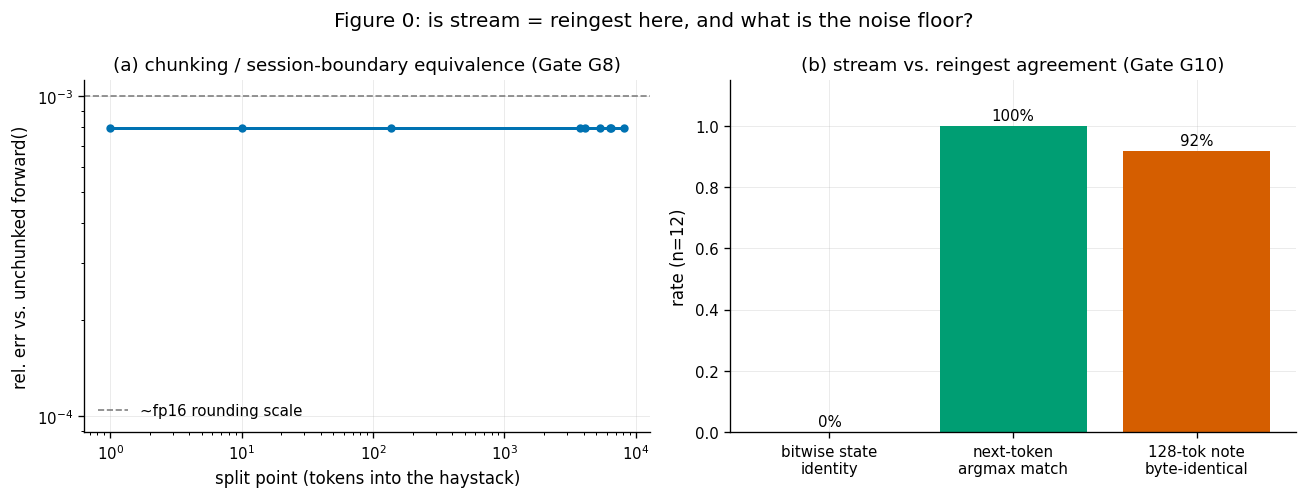

Panel (a): next-token relative error after splitting one real ~115k-token haystack at increasing
points (adversarial points plus every real session boundary). If this line trended upward with
split count, incremental feeding would not safely substitute for feeding the whole history at
once -- it does not (Gate G8 passed). Panel (b), n=12: how often a state built incrementally
(with a disk round-trip mid-stream) agrees with one built by a single full re-ingest, at three
levels of strictness. The falsifying number: if the argmax-match bar were below 100%, every
later comparison in this notebook would be unreliable. NOTE_DIVERGENCE_RATE=8.3% is the noise
floor every later figure caption cites -- any accuracy gap smaller than this could be decode-
path noise, not a real effect.


In [48]:

def report_fig0_equivalence():
    boundaries_path = STREAM_STORE / "gate_g8_boundaries.csv"
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

    ax = axes[0]
    if boundaries_path.exists():
        bdf = pd.read_csv(boundaries_path)
        ax.plot(bdf.split_point, bdf.rel_err.clip(lower=1e-12), "o-", color=OKABE_ITO[0], markersize=4)
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.axhline(1e-3, color="gray", linestyle="--", linewidth=1, label="~fp16 rounding scale")
        ax.legend()
    else:
        ax.text(0.5, 0.5, "Gate G8 CSV not found", ha="center", va="center")
    ax.set_xlabel("split point (tokens into the haystack)")
    ax.set_ylabel("rel. err vs. unchunked forward()")
    ax.set_title("(a) chunking / session-boundary equivalence (Gate G8)")

    ax2 = axes[1]
    n_eq = len(EQUIVALENCE_DF) if "EQUIVALENCE_DF" in globals() else 0
    if n_eq:
        bitwise_rate = EQUIVALENCE_DF.bitwise.mean() if EQUIVALENCE_LEVEL == "bitwise" else float("nan")
        names = ["bitwise state\nidentity", "next-token\nargmax match", "128-tok note\nbyte-identical"]
        vals = [bitwise_rate, EQUIVALENCE_DF.argmax_match.mean(), EQUIVALENCE_DF.note_identical.mean()]
        colors = [OKABE_ITO[0], OKABE_ITO[2], OKABE_ITO[4]]
        bars = ax2.bar(names, [0 if (isinstance(v, float) and np.isnan(v)) else v for v in vals], color=colors)
        for b, v in zip(bars, vals):
            label = "n/a" if (isinstance(v, float) and np.isnan(v)) else f"{v:.0%}"
            ax2.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.02, label, ha="center", fontsize=9)
        ax2.set_ylim(0, 1.15)
        ax2.set_ylabel(f"rate (n={n_eq})")
    ax2.set_title("(b) stream vs. reingest agreement (Gate G10)")

    fig.suptitle("Figure 0: is stream = reingest here, and what is the noise floor?")
    fig.tight_layout()
    fig.savefig(STREAM_RESULTS / "fig0_equivalence.png")
    plt.show()
    explain("fig0_equivalence",
        f"Panel (a): next-token relative error after splitting one real ~115k-token haystack at "
        f"increasing points (adversarial points plus every real session boundary). If this line trended "
        f"upward with split count, incremental feeding would not safely substitute for feeding the whole "
        f"history at once -- it does not (Gate G8 passed). Panel (b), n={n_eq}: how often a state built "
        f"incrementally (with a disk round-trip mid-stream) agrees with one built by a single full "
        f"re-ingest, at three levels of strictness. The falsifying number: if the argmax-match bar were "
        f"below 100%, every later comparison in this notebook would be unreliable. "
        f"NOTE_DIVERGENCE_RATE={NOTE_DIVERGENCE_RATE:.1%} is the noise floor every later figure caption "
        f"cites -- any accuracy gap smaller than this could be decode-path noise, not a real effect.")

report_fig0_equivalence()


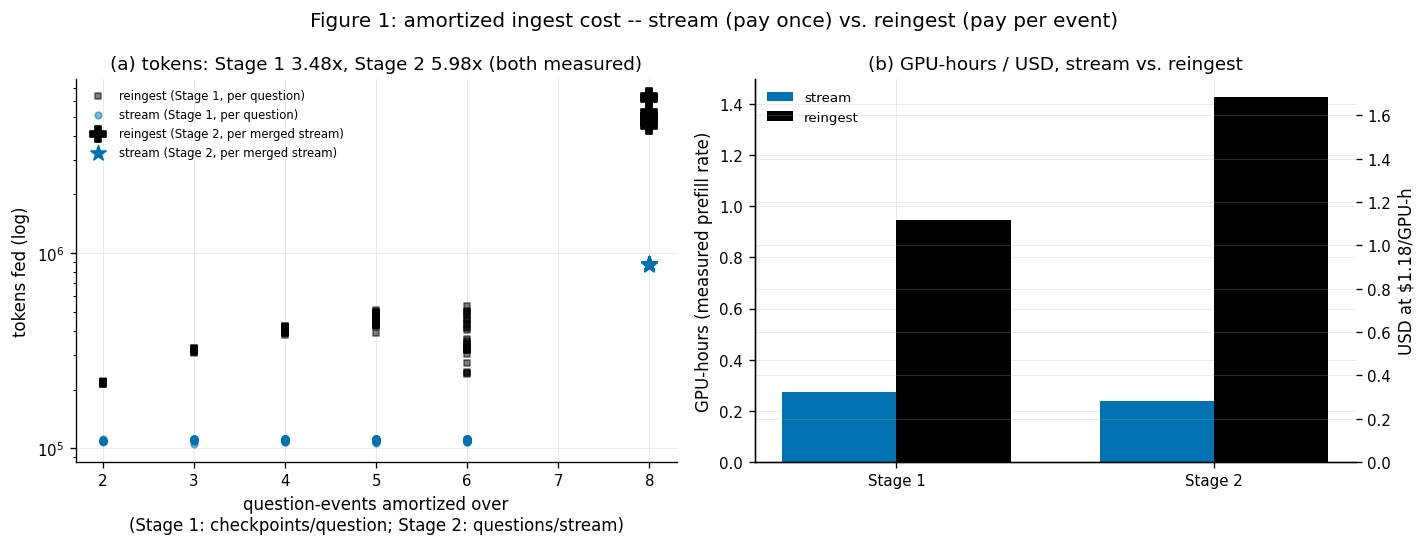

Every point is measured, not modeled: Stage 1's reingest-equivalent token count at checkpoint c
is the SAME prefix-length number `stream` itself recorded when it passed c, since re-ingesting
to c and streaming through c read the identical prefix. Stage 1 amortizes 3.48x over an average
of 4.5 checkpoints/question; Stage 2 amortizes 5.98x over 8.0 questions/merged stream. The
falsifying case: stream's token count exceeding reingest's -- by construction it cannot, since
feeding a session once can never cost more than feeding it once for every question that follows
it.


(      question_id  n_checkpoints  stream_tokens  reingest_tokens
 0        e66b632c              2         111128           217961
 1        dfde3500              6         109703           495873
 2        d7c942c3              5         111899           498637
 3        7a87bd0c              4         110307           398685
 4        42ec0761              3         109552           325413
 ..            ...            ...            ...              ...
 95  gpt4_ec93e27f              2         110608           220987
 96  gpt4_59149c78              5         110584           510400
 97  gpt4_b5700ca9              2         109067           218134
 98       8c18457d              3         110137           322385
 99  gpt4_6ed717ea              4         108799           417828
 
 [100 rows x 4 columns],
     stream_id  m  stream_tokens  reingest_tokens
 0           0  8         878351          6153765
 1           1  8         881240          6343561
 2           2  8         87768

In [49]:

def report_fig1_amortization():
    s1, s2 = STAGE1_AMORTIZATION_DF, STAGE2_AMORTIZATION_DF
    prefill_tok_s = RUN_PROJECTION["prefill_tok_s"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
    ax = axes[0]
    if len(s1):
        ax.scatter(s1.n_checkpoints, s1.reingest_tokens, s=16, color=POLICY_COLOR["reingest"],
                  marker="s", alpha=0.5, label="reingest (Stage 1, per question)")
        ax.scatter(s1.n_checkpoints, s1.stream_tokens, s=16, color=POLICY_COLOR["stream"],
                  marker="o", alpha=0.5, label="stream (Stage 1, per question)")
    if len(s2):
        ax.scatter(s2.m, s2.reingest_tokens, s=90, color=POLICY_COLOR["reingest"], marker="P",
                  label="reingest (Stage 2, per merged stream)")
        ax.scatter(s2.m, s2.stream_tokens, s=90, color=POLICY_COLOR["stream"], marker="*",
                  label="stream (Stage 2, per merged stream)")
    ax.set_yscale("log")
    ax.set_xlabel("question-events amortized over\n(Stage 1: checkpoints/question; Stage 2: questions/stream)")
    ax.set_ylabel("tokens fed (log)")
    ax.legend(fontsize=7, loc="upper left")
    s1_ratio = s1.reingest_tokens.sum() / max(1, s1.stream_tokens.sum()) if len(s1) else float("nan")
    s2_ratio = s2.reingest_tokens.sum() / max(1, s2.stream_tokens.sum()) if len(s2) else float("nan")
    ax.set_title(f"(a) tokens: Stage 1 {s1_ratio:.2f}x, Stage 2 {s2_ratio:.2f}x (both measured)")

    ax_b = axes[1]
    labels, stream_hs, reingest_hs = [], [], []
    for label, df in [("Stage 1", s1), ("Stage 2", s2)]:
        if not len(df):
            continue
        labels.append(label)
        stream_hs.append(df.stream_tokens.sum() / prefill_tok_s / 3600)
        reingest_hs.append(df.reingest_tokens.sum() / prefill_tok_s / 3600)
    x = np.arange(len(labels))
    ax_b.bar(x - 0.18, stream_hs, width=0.36, color=POLICY_COLOR["stream"], label="stream")
    ax_b.bar(x + 0.18, reingest_hs, width=0.36, color=POLICY_COLOR["reingest"], label="reingest")
    ax_b.set_xticks(x); ax_b.set_xticklabels(labels)
    ax_b.set_ylabel("GPU-hours (measured prefill rate)")
    ax_b2 = ax_b.twinx()
    ylim = ax_b.get_ylim()
    ax_b2.set_ylim(ylim[0] * GPU_USD_PER_HOUR, ylim[1] * GPU_USD_PER_HOUR)
    ax_b2.set_ylabel(f"USD at ${GPU_USD_PER_HOUR}/GPU-h")
    ax_b.legend(fontsize=8)
    ax_b.set_title("(b) GPU-hours / USD, stream vs. reingest")

    fig.suptitle("Figure 1: amortized ingest cost -- stream (pay once) vs. reingest (pay per event)")
    fig.tight_layout()
    fig.savefig(STREAM_RESULTS / "fig1_amortization.png")
    plt.show()
    s1.to_csv(STREAM_RESULTS / "fig1_amortization_stage1.csv", index=False)
    s2.to_csv(STREAM_RESULTS / "fig1_amortization_stage2.csv", index=False)
    explain("fig1_amortization",
        f"Every point is measured, not modeled: Stage 1's reingest-equivalent token count at checkpoint "
        f"c is the SAME prefix-length number `stream` itself recorded when it passed c, since re-ingesting "
        f"to c and streaming through c read the identical prefix. Stage 1 amortizes {s1_ratio:.2f}x over "
        f"an average of {s1.n_checkpoints.mean() if len(s1) else float('nan'):.1f} checkpoints/question; "
        f"Stage 2 amortizes {s2_ratio:.2f}x over {s2.m.mean() if len(s2) else float('nan'):.1f} "
        f"questions/merged stream. The falsifying case: stream's token count exceeding reingest's -- by "
        f"construction it cannot, since feeding a session once can never cost more than feeding it once "
        f"for every question that follows it.")
    return s1, s2

report_fig1_amortization()


In [50]:

def tokens_since_evidence(tag, qid, checkpoint_label):
    by_ckpt = stream_probes(tag).get(qid, {})
    d0, ck = by_ckpt.get("d0"), by_ckpt.get(checkpoint_label)
    if not d0 or not ck:
        return None
    return ck["tokens_ingested"] - d0["tokens_ingested"]


def build_decay_recall_df(tag=None, k=5, retriever_kind="bm25"):
    """Judge-free, reader-free: does the state's own clue at this checkpoint still retrieve the
    evidence session? Uses whichever clue text was actually decoded at that checkpoint (Section
    15's decode budget -- qa everywhere, sur/span only at 'end')."""
    tag = tag or PRIMARY_TAG
    retr = get_retriever(retriever_kind)
    rows = []
    for label in [f"d{d}" for d in DELTAS] + ["end"]:
        mem = MEMORY.get(f"{tag}__stream__{label}", {})
        for qid, m in mem.items():
            q = QID2S[qid]
            ids, values, keys, stamps = build_corpus(q, "session")
            correct = evidence_ids(q, "session")
            if not correct:
                continue
            query_lines = [s.strip() for s in (m.get("span") or "").split("\n") if len(s.split()) > 3]
            query = query_lines[0] if query_lines else q["question"]
            ranking = retr.rank(query, keys)
            recall_any, _recall_all, _ndcg = evaluate_retrieval(ranking, correct, ids, k=k)
            rows.append(dict(question_id=qid, checkpoint=label, question_type=q["question_type"],
                              tokens_since_evidence=tokens_since_evidence(tag, qid, label),
                              recall=recall_any))
    return pd.DataFrame(rows)

DECAY_RECALL_DF = build_decay_recall_df()


/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


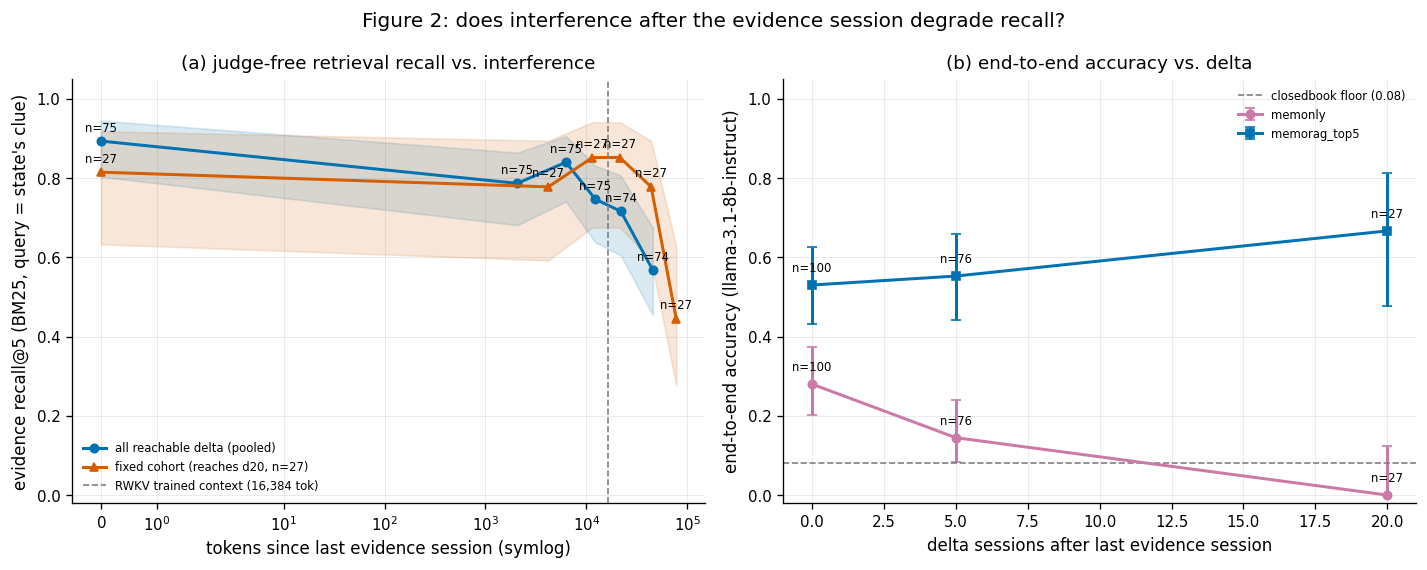

Panel (a) is judge-free and reader-free: does the state's own clue still retrieve the evidence
session, at increasing interference (x-axis is tokens, not sessions, since session length varies
~3x)? The pooled line risks a composition bias: easy single-session questions survive to large
delta far more often than multi-session/temporal ones, so the fixed-cohort line (only questions
reaching delta=20) is the one to trust for a real trend. Panel (b) is the same question end-to-
end, with closedbook drawn as the floor. The HEADLINE statistic is not a curve:
paired_drop_mcnemar (each question's own delta=0 vs. its own largest reachable delta) gives
memonly b=19 c=4 p=0.003 (n=76), memorag_top5 b=6 c=10 p=0.454 (n=76). A memonly effect
alongside a flat memorag_top5 curve would mean retrieval is repairing state decay -- a
legitimate finding, not a broken experiment.


In [52]:
def _binned_wilson(sub_df, n_bins=6):
    sub_df = sub_df.sort_values("tokens_since_evidence")
    if len(sub_df) == 0:
        return pd.DataFrame(columns=["median_tokens", "p", "lo", "hi", "n"])
    groups = np.array_split(sub_df, min(n_bins, len(sub_df)))
    rows = []
    for g in groups:
        if len(g) == 0:
            continue
        k, n = int(g.recall.sum()), len(g)
        p, lo, hi = wilson(k, n)
        rows.append(dict(median_tokens=g.tokens_since_evidence.median(), p=p, lo=lo, hi=hi, n=n))
    return pd.DataFrame(rows)


def report_fig2_decay():
    df = DECAY_RECALL_DF.dropna(subset=["tokens_since_evidence"]).copy()
    df = df[df.tokens_since_evidence >= 0]
    fixed_ids = set(fixed_cohort_qids(max_delta=20))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
    ax = axes[0]
    pooled = _binned_wilson(df)
    fixed = _binned_wilson(df[df.question_id.isin(fixed_ids)])
    for label, bdf, color, marker in [("all reachable delta (pooled)", pooled, OKABE_ITO[0], "o"),
                                       (f"fixed cohort (reaches d20, n={len(fixed_ids)})", fixed, OKABE_ITO[4], "^")]:
        if len(bdf) == 0:
            continue
        ax.plot(bdf.median_tokens, bdf.p, marker=marker, color=color, label=label)
        ax.fill_between(bdf.median_tokens, bdf.lo, bdf.hi, color=color, alpha=0.15)
        for _, r in bdf.iterrows():
            ax.annotate(f"n={int(r.n)}", (r.median_tokens, r.p), fontsize=7,
                       textcoords="offset points", xytext=(0, 6), ha="center")
    ax.set_xscale("symlog")
    ax.axvline(RWKV_TRAINED_CONTEXT, color="gray", linestyle="--", linewidth=1,
              label=f"RWKV trained context ({RWKV_TRAINED_CONTEXT:,} tok)")
    ax.set_xlabel("tokens since last evidence session (symlog)")
    ax.set_ylabel("evidence recall@5 (BM25, query = state's clue)")
    ax.set_ylim(-0.02, 1.05)
    ax.set_title("(a) judge-free retrieval recall vs. interference")
    ax.legend(fontsize=7)

    ax2 = axes[1]
    for route, color, marker in [("memonly", OKABE_ITO[3], "o"), ("memorag_top5", OKABE_ITO[0], "s")]:
        xs, ys, los, his, ns = [], [], [], [], []
        for d in (0, 5, 20):
            arm_name = f"s1__decay__{route}__d{d}"
            if arm_name not in ARMS:
                continue
            acc, k, n = accuracy_any(PRIMARY_READER, arm_name)
            if acc is None:
                continue
            _, lo, hi = wilson(k, n)
            # wilson()'s own [0,1] clamps can leave hi a float ULP below acc (or lo a ULP above
            # it) exactly at k==0/k==n, e.g. n=74,k=74 -> hi=0.9999999999999998 < acc=1.0 --
            # matplotlib's errorbar hard-rejects any negative yerr, so clamp the tiny fp noise.
            xs.append(d); ys.append(acc); los.append(max(0.0, acc - lo)); his.append(max(0.0, hi - acc)); ns.append(n)
        if xs:
            ax2.errorbar(xs, ys, yerr=[los, his], marker=marker, color=color, label=route, capsize=3)
            for x, y, n in zip(xs, ys, ns):
                ax2.annotate(f"n={n}", (x, y), fontsize=7, textcoords="offset points", xytext=(0, 8), ha="center")
    cb_acc, _k, _n = accuracy_any(PRIMARY_READER, "closedbook")
    if cb_acc is not None:
        ax2.axhline(cb_acc, color="gray", linestyle="--", linewidth=1, label=f"closedbook floor ({cb_acc:.2f})")
    ax2.set_xlabel("delta sessions after last evidence session")
    ax2.set_ylabel(f"end-to-end accuracy ({PRIMARY_READER})")
    ax2.set_ylim(-0.02, 1.05)
    ax2.set_title("(b) end-to-end accuracy vs. delta")
    ax2.legend(fontsize=7)

    drop_memonly = paired_drop_mcnemar(PRIMARY_READER, "s1__decay__memonly")
    drop_memorag = paired_drop_mcnemar(PRIMARY_READER, "s1__decay__memorag_top5")

    fig.suptitle("Figure 2: does interference after the evidence session degrade recall?")
    fig.tight_layout()
    fig.savefig(STREAM_RESULTS / "fig2_decay.png")
    plt.show()
    df.to_csv(STREAM_RESULTS / "fig2_decay_recall.csv", index=False)

    explain("fig2_decay",
        f"Panel (a) is judge-free and reader-free: does the state's own clue still retrieve the evidence "
        f"session, at increasing interference (x-axis is tokens, not sessions, since session length "
        f"varies ~3x)? The pooled line risks a composition bias: easy single-session questions survive "
        f"to large delta far more often than multi-session/temporal ones, so the fixed-cohort line (only "
        f"questions reaching delta=20) is the one to trust for a real trend. Panel (b) is the same "
        f"question end-to-end, with closedbook drawn as the floor. The HEADLINE statistic is not a curve: "
        f"paired_drop_mcnemar (each question's own delta=0 vs. its own largest reachable delta) gives "
        f"memonly b={drop_memonly['b']} c={drop_memonly['c']} p={drop_memonly['p']:.3f} "
        f"(n={drop_memonly['n']}), memorag_top5 b={drop_memorag['b']} c={drop_memorag['c']} "
        f"p={drop_memorag['p']:.3f} (n={drop_memorag['n']}). A memonly effect alongside a flat "
        f"memorag_top5 curve would mean retrieval is repairing state decay -- a legitimate finding, not "
        f"a broken experiment.")
    return dict(memonly=drop_memonly, memorag_top5=drop_memorag)

FIG2_HEADLINE = report_fig2_decay()

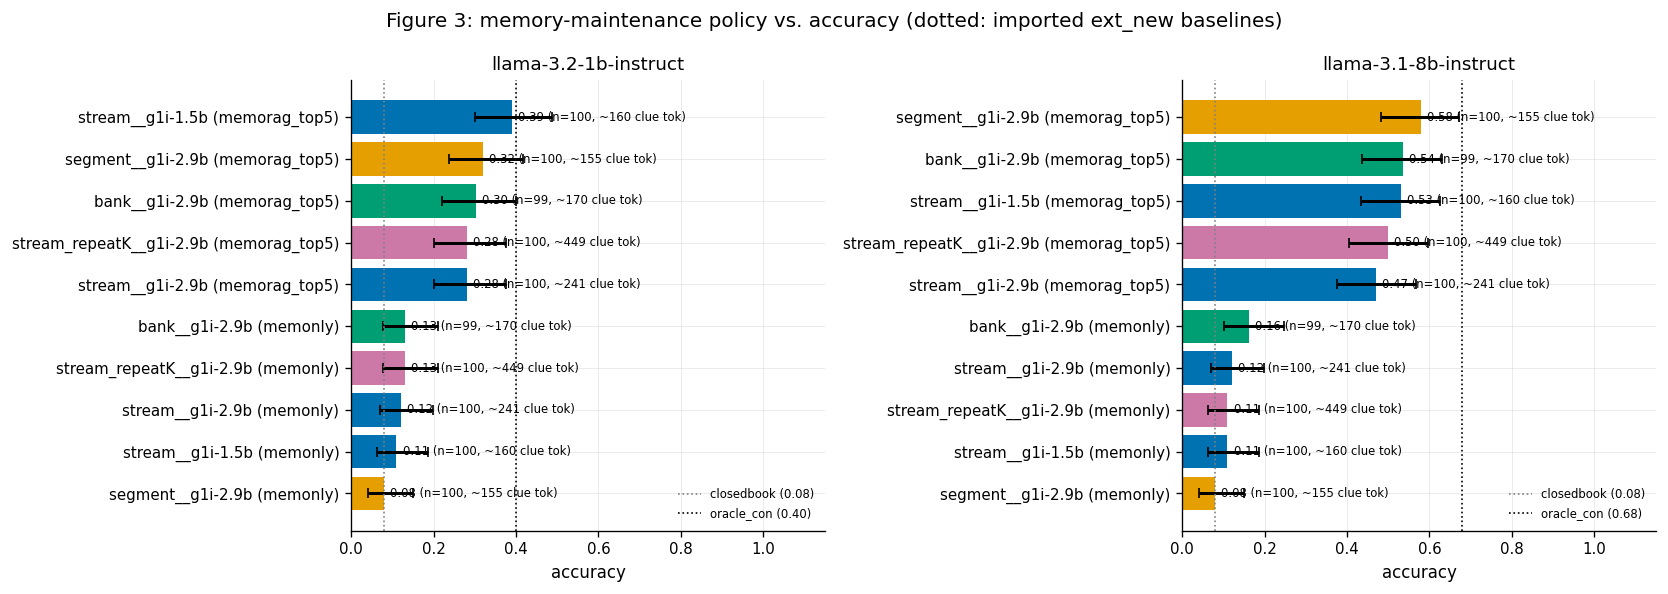

Each bar is one (policy, tag, route) arm's accuracy with a 95% Wilson interval; the grey/black
dotted lines are the closedbook floor and oracle_con ceiling IMPORTED from ext_new (Section 24),
not re-run. The clue-token count printed on each bar matters: bank/segment/stream_repeatK hand
the generator more text than stream by construction (Section 16), so a policy beating stream
here could be 'more text reached the generator' rather than 'more memory' -- stream_repeatK
exists specifically as the control that separates the two (same token count as bank/segment, but
content pinned to the single final state).


In [53]:
def _mean_clue_tokens(memory_source):
    mem = MEMORY.get(memory_source, {})
    if not mem:
        return None
    lens = [(len(m.get("span") or "") + len(m.get("sur") or "")) // 4 for m in mem.values()]
    return int(np.mean(lens)) if lens else None


def report_fig3_policy():
    policy_tag_pairs = [("stream", t) for t in RWKV_ACTIVE] + \
        [(p, PRIMARY_TAG) for p in ("bank", "segment", "stream_repeatK")]

    rows = []
    for reader in READER_ORDER:
        for policy, tag in policy_tag_pairs:
            for route in ("memonly", "memorag_top5"):
                arm_name = f"s1__{policy}__{route}__{tag}"
                if arm_name not in ARMS:
                    continue
                acc, k, n = accuracy_any(reader, arm_name)
                if acc is None:
                    continue
                _, lo, hi = wilson(k, n)
                rows.append(dict(reader=reader, policy=policy, tag=tag, route=route, arm=arm_name,
                                  acc=acc, lo=lo, hi=hi, n=n,
                                  mean_clue_tokens=_mean_clue_tokens(ARMS[arm_name].memory_source)))
    df = pd.DataFrame(rows)
    df.to_csv(STREAM_RESULTS / "fig3_policy.csv", index=False)

    n_readers = max(1, len(READER_ORDER))
    fig, axes = plt.subplots(1, n_readers, figsize=(7 * n_readers, 5), squeeze=False)
    for ax, reader in zip(axes[0], READER_ORDER):
        sub = df[df.reader == reader].copy()
        if not len(sub):
            continue
        sub["label"] = sub.apply(lambda r: f"{r.policy}__{r.tag} ({r.route})", axis=1)
        sub = sub.sort_values("acc")
        colors = [POLICY_COLOR.get(r.policy, "#888888") for r in sub.itertuples()]
        # clip(lower=0): same wilson() fp-boundary guard as Figure 2 (k==0/k==n can leave hi/lo a
        # ULP on the wrong side of acc), applied vectorized since this is a whole Series here.
        ax.barh(sub.label, sub.acc, xerr=[(sub.acc - sub.lo).clip(lower=0), (sub.hi - sub.acc).clip(lower=0)],
               color=colors, capsize=3)
        for y, r in enumerate(sub.itertuples()):
            extra = f", ~{r.mean_clue_tokens} clue tok" if r.mean_clue_tokens else ""
            ax.text(r.acc + 0.015, y, f"{r.acc:.2f} (n={r.n}{extra})", va="center", fontsize=7)
        cb_acc, _, _ = accuracy_any(reader, "closedbook")
        oc_acc, _, _ = accuracy_any(reader, "oracle_con")
        if cb_acc is not None:
            ax.axvline(cb_acc, color="gray", linestyle=":", linewidth=1, label=f"closedbook ({cb_acc:.2f})")
        if oc_acc is not None:
            ax.axvline(oc_acc, color="black", linestyle=":", linewidth=1, label=f"oracle_con ({oc_acc:.2f})")
        ax.set_xlim(0, 1.15)
        ax.set_title(reader)
        ax.set_xlabel("accuracy")
        ax.legend(fontsize=7, loc="lower right")

    fig.suptitle("Figure 3: memory-maintenance policy vs. accuracy (dotted: imported ext_new baselines)")
    fig.tight_layout()
    fig.savefig(STREAM_RESULTS / "fig3_policy.png")
    plt.show()
    explain("fig3_policy",
        f"Each bar is one (policy, tag, route) arm's accuracy with a 95% Wilson interval; the grey/black "
        f"dotted lines are the closedbook floor and oracle_con ceiling IMPORTED from ext_new (Section 24), "
        f"not re-run. The clue-token count printed on each bar matters: bank/segment/stream_repeatK hand "
        f"the generator more text than stream by construction (Section 16), so a policy beating stream "
        f"here could be 'more text reached the generator' rather than 'more memory' -- stream_repeatK "
        f"exists specifically as the control that separates the two (same token count as bank/segment, "
        f"but content pinned to the single final state).")
    return df

FIG3_DF = report_fig3_policy()

In [54]:

def report_fig3_significance():
    rows, pvals = [], []
    for reader in READER_ORDER:
        for route in ("memonly", "memorag_top5"):
            base_arm = f"s1__stream__{route}__{PRIMARY_TAG}"
            if base_arm not in ARMS:
                continue
            base_labels = arm_labels(reader, base_arm)
            if not base_labels:
                continue
            for policy in ("bank", "segment", "stream_repeatK"):
                arm_name = f"s1__{policy}__{route}__{PRIMARY_TAG}"
                if arm_name not in ARMS:
                    continue
                other_labels = arm_labels(reader, arm_name)
                shared = [q for q in base_labels if q in other_labels]
                if not shared:
                    continue
                b, c, p = mcnemar_exact([base_labels[q] for q in shared], [other_labels[q] for q in shared])
                rows.append(dict(reader=reader, route=route, policy=policy, n=len(shared), b=b, c=c, p=p))
                pvals.append(p)
    if pvals:
        for r, h in zip(rows, holm_bonferroni(pvals)):
            r["holm_p"] = h
    df = pd.DataFrame(rows)
    df.to_csv(STREAM_RESULTS / "fig3_significance.csv", index=False)
    print("Each policy vs. `stream` at the same (reader, route, tag), exact McNemar + Holm-Bonferroni:")
    print(df.round(4).to_string(index=False) if len(df) else "  (no comparable pairs)")
    return df

FIG3_SIGNIFICANCE_DF = report_fig3_significance()


Each policy vs. `stream` at the same (reader, route, tag), exact McNemar + Holm-Bonferroni:
               reader        route         policy   n  b  c      p  holm_p
llama-3.2-1b-instruct      memonly           bank  99  2  3 1.0000  1.0000
llama-3.2-1b-instruct      memonly        segment 100  7  3 0.3438  1.0000
llama-3.2-1b-instruct      memonly stream_repeatK 100  4  5 1.0000  1.0000
llama-3.2-1b-instruct memorag_top5           bank  99  9 12 0.6636  1.0000
llama-3.2-1b-instruct memorag_top5        segment 100  6 10 0.4545  1.0000
llama-3.2-1b-instruct memorag_top5 stream_repeatK 100  0  0 1.0000  1.0000
llama-3.1-8b-instruct      memonly           bank  99  4  8 0.3877  1.0000
llama-3.1-8b-instruct      memonly        segment 100  7  3 0.3438  1.0000
llama-3.1-8b-instruct      memonly stream_repeatK 100  2  1 1.0000  1.0000
llama-3.1-8b-instruct memorag_top5           bank  99  7 14 0.1892  1.0000
llama-3.1-8b-instruct memorag_top5        segment 100  2 13 0.0074  0.0886
llama-3.

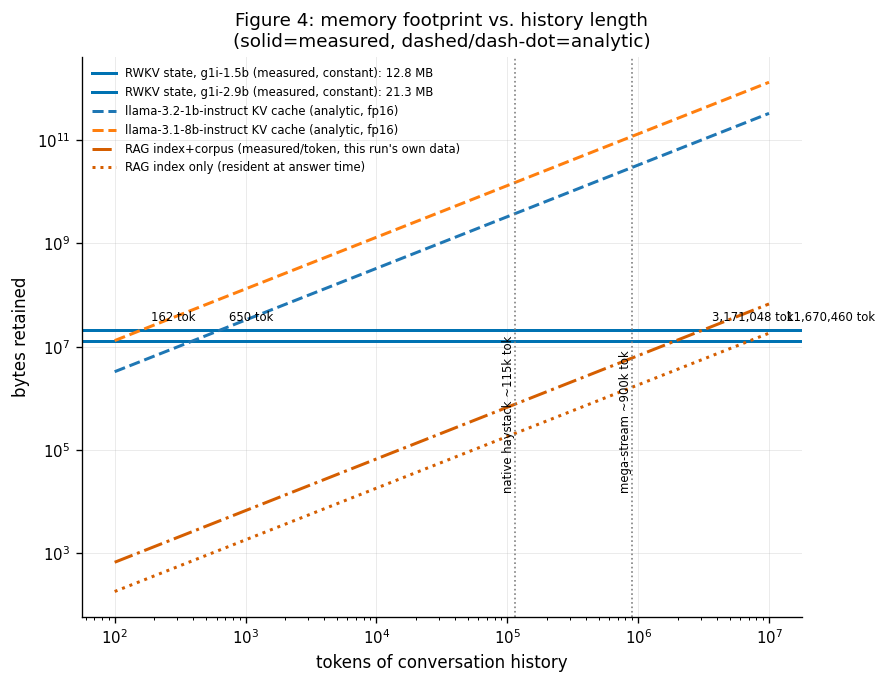

RWKV's recurrent state is the only FLAT line -- 21.3 MB regardless of how much conversation it
has folded in, measured live, not assumed. It crosses an 8B model's KV cache almost immediately
(~162 tokens if computed) -- but a RAG index+corpus is MORE byte-efficient than the RWKV state
across this entire benchmark's range (crossover at ~3,171,048 tokens). The honest claim is
narrower than 'incremental memory wins on bytes': it is 'constant vs. linear, with the crossover
where it actually is' -- and a RAG index is also incrementally updatable, so bytes-per-user
alone is not a reason to prefer a persisted RWKV state over RAG.


In [55]:

def report_fig4_footprint():
    rwkv_bytes = {}
    for tag in RWKV_ACTIVE:
        row = next((r.get("end") for r in stream_probes(tag).values() if r.get("end")), None)
        if row:
            rwkv_bytes[tag] = row["state_bytes"]

    # Analytic fp16 GQA KV-cache bytes/token: 2 (K+V) * n_kv_heads * head_dim * n_layers * 2 bytes.
    KV_BYTES_PER_TOKEN = {
        "llama-3.2-1b-instruct": 2 * 8 * 64 * 16 * 2,
        "llama-3.1-8b-instruct": 2 * 8 * 128 * 32 * 2,
    }

    sample_qid = QUESTION_IDS[0]
    sq = QID2S[sample_qid]
    _ids, values, _keys, _stamps = build_corpus(sq, "session")
    corpus_chars = sum(len(json.dumps(v)) for v in values)
    hist_text = render_history_dialogue(sq["haystack_sessions"], sq["haystack_dates"])
    corpus_tokens_est = count_tokens(hist_text, PRIMARY_READER)
    rag_corpus_bytes_per_tok = corpus_chars / max(1, corpus_tokens_est)
    EMBED_DIM = 1024   # stella_en_1.5B_v5 output dimensionality
    rag_index_bytes_per_tok = (len(values) * EMBED_DIM * 4) / max(1, corpus_tokens_est)
    rag_total_bytes_per_tok = rag_corpus_bytes_per_tok + rag_index_bytes_per_tok

    xs = np.logspace(2, 7, 60)
    fig, ax = plt.subplots(figsize=(7.5, 5.8))
    for tag, b in rwkv_bytes.items():
        ax.axhline(b, color=POLICY_COLOR["stream"], linestyle="-",
                  label=f"RWKV state, {tag} (measured, constant): {b/1e6:.1f} MB")
    for reader, bpt in KV_BYTES_PER_TOKEN.items():
        ax.plot(xs, xs * bpt, "--", label=f"{reader} KV cache (analytic, fp16)")
    ax.plot(xs, xs * rag_total_bytes_per_tok, "-.", color=POLICY_COLOR["rag_q_top5"],
           label="RAG index+corpus (measured/token, this run's own data)")
    ax.plot(xs, xs * rag_index_bytes_per_tok, ":", color=POLICY_COLOR["rag_q_top5"],
           label="RAG index only (resident at answer time)")

    primary_bytes = rwkv_bytes.get(PRIMARY_TAG)
    crossovers = {}
    if primary_bytes:
        for reader, bpt in KV_BYTES_PER_TOKEN.items():
            crossovers[reader] = primary_bytes / bpt
        crossovers["rag_index_corpus"] = primary_bytes / rag_total_bytes_per_tok
        crossovers["rag_index_only"] = primary_bytes / rag_index_bytes_per_tok
        for name, xc in crossovers.items():
            ax.annotate(f"{xc:,.0f} tok", (xc, primary_bytes), fontsize=7,
                       textcoords="offset points", xytext=(5, 5))

    ymid = np.sqrt(max(rwkv_bytes.values(), default=1e6) * 10)
    for tok_mark, label in [(115_000, "native haystack ~115k tok"), (900_000, "mega-stream ~900k tok")]:
        ax.axvline(tok_mark, color="gray", linestyle=":", linewidth=1)
        ax.annotate(label, (tok_mark, ymid), rotation=90, fontsize=7, va="bottom", ha="right")

    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("tokens of conversation history"); ax.set_ylabel("bytes retained")
    ax.legend(fontsize=7, loc="upper left")
    ax.set_title("Figure 4: memory footprint vs. history length\n(solid=measured, dashed/dash-dot=analytic)")
    fig.tight_layout()
    fig.savefig(STREAM_RESULTS / "fig4_footprint.png")
    plt.show()

    rows = [dict(method=f"rwkv_{t}", bytes_per_token=0, constant_bytes=b, source="measured")
            for t, b in rwkv_bytes.items()]
    rows += [dict(method=r, bytes_per_token=bpt, constant_bytes=None, source="analytic")
             for r, bpt in KV_BYTES_PER_TOKEN.items()]
    rows += [dict(method="rag_index_corpus", bytes_per_token=rag_total_bytes_per_tok,
                  constant_bytes=None, source="measured-per-token"),
             dict(method="rag_index_only", bytes_per_token=rag_index_bytes_per_tok,
                  constant_bytes=None, source="measured-per-token")]
    pd.DataFrame(rows).to_csv(STREAM_RESULTS / "fig4_footprint.csv", index=False)

    kv8b_cross = crossovers.get("llama-3.1-8b-instruct")
    rag_cross = crossovers.get("rag_index_corpus")
    explain("fig4_footprint",
        f"RWKV's recurrent state is the only FLAT line -- {primary_bytes/1e6:.1f} MB regardless of how "
        f"much conversation it has folded in, measured live, not assumed. It crosses an 8B model's KV "
        f"cache almost immediately (~{kv8b_cross:,.0f} tokens if computed) -- but a RAG index+corpus is "
        f"MORE byte-efficient than the RWKV state across this entire benchmark's range (crossover at "
        f"~{rag_cross:,.0f} tokens). The honest claim is narrower than 'incremental memory wins on "
        f"bytes': it is 'constant vs. linear, with the crossover where it actually is' -- and a RAG "
        f"index is also incrementally updatable, so bytes-per-user alone is not a reason to prefer a "
        f"persisted RWKV state over RAG.")
    return rwkv_bytes, crossovers

FIG4_RESULT = report_fig4_footprint()


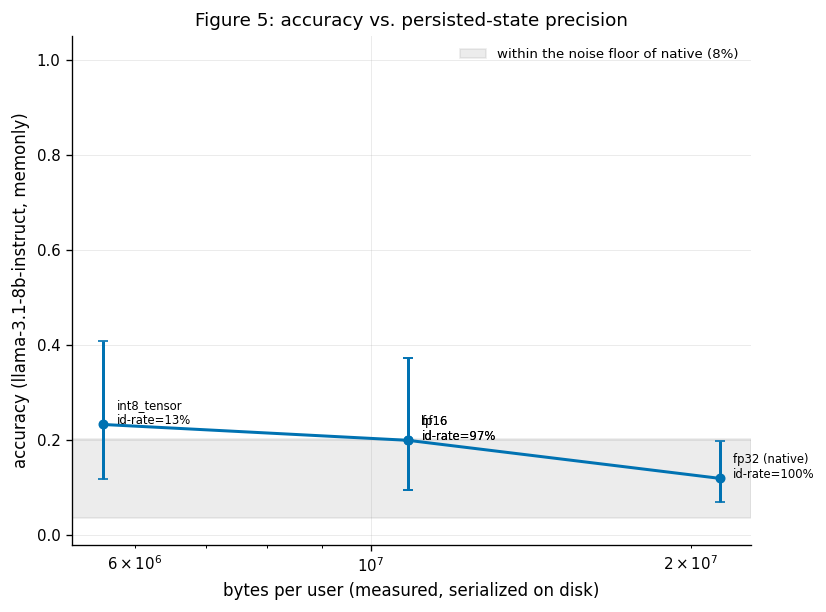

Each point is one persisted-state precision, x-axis is the MEASURED file size on disk (not a
formula), y-axis its end-to-end accuracy. The shaded band around the native (fp32) point is the
equivalence gate's own NOTE_DIVERGENCE_RATE=8.3% -- a lower-precision point landing inside it is
statistically indistinguishable from lossless, and the point should be read that way rather than
as a real accuracy cost. int8 modes are expected to show the largest functional-identity drop
(Gate G9); that drop, not a crash, is this ablation's result.


In [56]:
def report_fig5_precision():
    rows = []
    end_row = next((r.get("end") for r in stream_probes(PRIMARY_TAG).values() if r.get("end")), None)
    if end_row:
        acc, k, n = accuracy_any(PRIMARY_READER, f"s1__stream__memonly__{PRIMARY_TAG}")
        if acc is not None:
            _, lo, hi = wilson(k, n)
            rows.append(dict(mode="fp32 (native)", bytes_per_user=end_row["state_bytes"],
                              acc=acc, lo=lo, hi=hi, n=n, functional_identity=1.0))

    for mode in PRECISION_ABLATION_DTYPES:
        sub = PRECISION_ABLATION_DF[PRECISION_ABLATION_DF["mode"] == mode] \
            if "mode" in PRECISION_ABLATION_DF.columns else pd.DataFrame()
        acc, k, n = accuracy_any(PRIMARY_READER, f"s1__precision_{mode}__memonly")
        if acc is None or len(sub) == 0:
            continue
        _, lo, hi = wilson(k, n)
        rows.append(dict(mode=mode, bytes_per_user=sub.bytes_per_user_serialized.mean(),
                          acc=acc, lo=lo, hi=hi, n=n, functional_identity=sub.functional_identical.mean()))

    pdf = pd.DataFrame(rows).sort_values("bytes_per_user") if rows else pd.DataFrame()
    pdf.to_csv(STREAM_RESULTS / "fig5_precision.csv", index=False)

    fig, ax = plt.subplots(figsize=(7, 5.2))
    if len(pdf):
        # same wilson() fp-boundary guard as Figure 2/3 (k==0/k==n can leave hi/lo a ULP on the
        # wrong side of acc, which errorbar rejects as a "negative" yerr).
        ax.errorbar(pdf.bytes_per_user, pdf.acc, yerr=[(pdf.acc - pdf.lo).clip(lower=0), (pdf.hi - pdf.acc).clip(lower=0)],
                   marker="o", linestyle="-", color=OKABE_ITO[0], capsize=3)
        for _, r in pdf.iterrows():
            ax.annotate(f"{r['mode']}\nid-rate={r.functional_identity:.0%}", (r.bytes_per_user, r.acc),
                       fontsize=7, textcoords="offset points", xytext=(8, 0))
        native_row = pdf[pdf["mode"] == "fp32 (native)"]
        if len(native_row):
            na = native_row.acc.iloc[0]
            band = NOTE_DIVERGENCE_RATE if NOTE_DIVERGENCE_RATE else 0.05
            ax.axhspan(max(0, na - band), min(1, na + band), color="gray", alpha=0.15,
                      label=f"within the noise floor of native ({band:.0%})")
        ax.legend(fontsize=8)
    ax.set_xscale("log")
    ax.set_xlabel("bytes per user (measured, serialized on disk)")
    ax.set_ylabel(f"accuracy ({PRIMARY_READER}, memonly)")
    ax.set_ylim(-0.02, 1.05)
    ax.set_title("Figure 5: accuracy vs. persisted-state precision")
    fig.tight_layout()
    fig.savefig(STREAM_RESULTS / "fig5_precision.png")
    plt.show()
    explain("fig5_precision",
        f"Each point is one persisted-state precision, x-axis is the MEASURED file size on disk (not a "
        f"formula), y-axis its end-to-end accuracy. The shaded band around the native (fp32) point is "
        f"the equivalence gate's own NOTE_DIVERGENCE_RATE={NOTE_DIVERGENCE_RATE:.1%} -- a lower-precision "
        f"point landing inside it is statistically indistinguishable from lossless, and the point should "
        f"be read that way rather than as a real accuracy cost. int8 modes are expected to show the "
        f"largest functional-identity drop (Gate G9); that drop, not a crash, is this ablation's result.")
    return pdf

FIG5_DF = report_fig5_precision()

## Section 27f: The flip table -- how the primary model's answers change when stacked on MemoRAG

The user's own framing of this extension: does the primary Llama model's answer change
differently when the secondary model's clues are fed to it directly (`memonly`) versus used as
retrieval queries (`memorag_top5`)? This is that comparison, paired per question, at every policy
this notebook ran, plus a sample of the actual answers that flipped.

In [57]:

def report_flip_table():
    rows, all_flips = [], []
    policy_tags = [("stream", t) for t in RWKV_ACTIVE] + \
        [(p, PRIMARY_TAG) for p in ("bank", "segment", "stream_repeatK")]
    for reader in READER_ORDER:
        for policy, tag in policy_tags:
            a_name, b_name = f"s1__{policy}__memonly__{tag}", f"s1__{policy}__memorag_top5__{tag}"
            if a_name not in ARMS or b_name not in ARMS:
                continue
            a_lab, b_lab = arm_labels(reader, a_name), arm_labels(reader, b_name)
            shared = [q for q in a_lab if q in b_lab]
            if not shared:
                continue
            b_cnt, c_cnt, p = mcnemar_exact([a_lab[q] for q in shared], [b_lab[q] for q in shared])
            rows.append(dict(reader=reader, tag=tag, policy=policy, n=len(shared), b=b_cnt, c=c_cnt, p=p))
            a_recs = _load_arm_records(RUNS / reader / f"{a_name}.jsonl")
            b_recs = _load_arm_records(RUNS / reader / f"{b_name}.jsonl")
            for q in shared:
                if a_lab[q] != b_lab[q]:
                    all_flips.append(dict(
                        reader=reader, tag=tag, policy=policy, question_id=q,
                        question=QID2S[q]["question"], gold=QID2S[q]["answer"],
                        memonly_hyp=a_recs.get(q, {}).get("hypothesis", ""),
                        memorag_hyp=b_recs.get(q, {}).get("hypothesis", ""),
                        memonly_label=a_lab[q], memorag_label=b_lab[q]))
    if rows:
        for r, h in zip(rows, holm_bonferroni([r["p"] for r in rows])):
            r["holm_p"] = h
    df = pd.DataFrame(rows)
    flips_df = pd.DataFrame(all_flips)
    df.to_csv(STREAM_RESULTS / "flip_table.csv", index=False)
    flips_df.to_csv(STREAM_RESULTS / "answer_flips.csv", index=False)

    print("memonly vs. memorag_top5, paired exact McNemar per (reader, tag, policy):")
    print(df.round(4).to_string(index=False) if len(df) else "  (nothing comparable)")
    print(f"\n{len(flips_df)} question-level flips across all comparisons. Sample:")
    for r in flips_df.head(8).itertuples():
        print(f"\n  [{r.reader} / {r.tag} / {r.policy}] {r.question_id}: {r.question!r}")
        print(f"    gold answer:            {r.gold!r}")
        print(f"    memonly ({r.memonly_label!s:>5}):      {r.memonly_hyp[:140]!r}")
        print(f"    memorag_top5 ({r.memorag_label!s:>5}): {r.memorag_hyp[:140]!r}")
    return df, flips_df

FLIP_TABLE_DF, ANSWER_FLIPS_DF = report_flip_table()


memonly vs. memorag_top5, paired exact McNemar per (reader, tag, policy):
               reader      tag         policy   n  b  c      p  holm_p
llama-3.2-1b-instruct g1i-1.5b         stream 100  5 33 0.0000  0.0000
llama-3.2-1b-instruct g1i-2.9b         stream 100  8 24 0.0070  0.0140
llama-3.2-1b-instruct g1i-2.9b           bank  99  7 24 0.0033  0.0100
llama-3.2-1b-instruct g1i-2.9b        segment 100  6 30 0.0001  0.0003
llama-3.2-1b-instruct g1i-2.9b stream_repeatK 100  8 23 0.0107  0.0140
llama-3.1-8b-instruct g1i-1.5b         stream 100  5 47 0.0000  0.0000
llama-3.1-8b-instruct g1i-2.9b         stream 100  2 37 0.0000  0.0000
llama-3.1-8b-instruct g1i-2.9b           bank  99  6 43 0.0000  0.0000
llama-3.1-8b-instruct g1i-2.9b        segment 100  2 52 0.0000  0.0000
llama-3.1-8b-instruct g1i-2.9b stream_repeatK 100  3 42 0.0000  0.0000

407 question-level flips across all comparisons. Sample:

  [llama-3.2-1b-instruct / g1i-1.5b / stream] dfde3500: 'What day of the week did I me

## Section 28: Cost ledger

In [58]:

def cost_ledger():
    print("=" * 90)
    print("Cost and volume ledger (measured from the run records, not estimated)")
    print("=" * 90)
    agg = {}
    for r in iter_generations():
        k = (r.get("reader", "?"), r.get("artifact", "?"))
        a = agg.setdefault(k, dict(n=0, pin=0, pout=0, cost=0.0, lat=0.0, err=0))
        a["n"] += 1
        a["pin"] += r.get("prompt_tokens", 0) or 0
        a["pout"] += r.get("completion_tokens", 0) or 0
        a["cost"] += r.get("cost_usd", 0.0) or 0.0
        a["lat"] += r.get("latency_s", 0.0) or 0.0
        a["err"] += 1 if r.get("error") else 0
    rows = [dict(reader=k[0], artifact=k[1], n=v["n"], in_Mtok=v["pin"] / 1e6, out_Mtok=v["pout"] / 1e6,
                gen_cost_usd=v["cost"], mean_latency_s=v["lat"] / max(1, v["n"]), errors=v["err"])
           for k, v in sorted(agg.items())]
    df = pd.DataFrame(rows)
    print(df.round(3).to_string(index=False) if len(df) else "  no generations on disk yet")

    n_judged = len(JUDGED) if "JUDGED" in globals() else 0
    judge_cost = n_judged * 400 / 1e6 * PRICE_IN_PER_MTOK
    gen_cost = df.gen_cost_usd.sum() if len(df) else 0.0

    # RWKV GPU time -- measured from every probe row's own ingest_s/probe_s, not billed per
    # token, reported in GPU-hours/USD at the stated GPU_USD_PER_HOUR.
    rwkv_seconds, rwkv_rows = 0.0, 0
    for tag in RWKV_ACTIVE:
        for by_ckpt in stream_probes(tag).values():
            for row in by_ckpt.values():
                rwkv_seconds += (row.get("ingest_s") or 0.0) + (row.get("probe_s") or 0.0)
                rwkv_rows += 1
    for by_ckpt in stream_s2_probes(PRIMARY_TAG).values():
        for row in by_ckpt.values():
            rwkv_seconds += (row.get("ingest_s") or 0.0) + (row.get("probe_s") or 0.0)
            rwkv_rows += 1
    rwkv_hours = rwkv_seconds / 3600
    rwkv_usd = rwkv_hours * GPU_USD_PER_HOUR

    print(f"\n  generation (OpenRouter + local vLLM):   ${gen_cost:8.2f}")
    print(f"  RWKV ingest+probe GPU time:              {rwkv_hours:8.2f} h  (${rwkv_usd:.2f} at "
          f"${GPU_USD_PER_HOUR}/GPU-h, {rwkv_rows} probe rows across {len(RWKV_ACTIVE)} tag(s))")
    print(f"  judge ({n_judged:,} calls, GPT-4o):           ${judge_cost:8.2f}")
    print(f"  {'-' * 62}")
    print(f"  TOTAL (API + GPU at the stated rate):    ${gen_cost + judge_cost + rwkv_usd:8.2f}")

    df.to_csv(STREAM_RESULTS / "cost_ledger.csv", index=False)
    print("\nResults written to:", STREAM_RESULTS)
    for p in sorted(STREAM_RESULTS.glob("*")):
        print(" ", p.name)
    return df

COST_LEDGER_DF = cost_ledger()


def footprint_table():
    rwkv_bytes, crossovers = FIG4_RESULT
    print("\nFootprint summary:")
    for tag, b in rwkv_bytes.items():
        print(f"  RWKV state, {tag:>10s}: {b / 1e6:8.2f} MB  (measured, constant regardless of history length)")
    for name, xc in crossovers.items():
        print(f"  crossover vs {name:>18s}: {xc:12,.0f} tokens")
    return rwkv_bytes, crossovers

footprint_table()


Cost and volume ledger (measured from the run records, not estimated)
               reader        artifact   n  in_Mtok  out_Mtok  gen_cost_usd  mean_latency_s  errors
llama-3.1-8b-instruct           decay 406    2.987     0.025         0.061           4.488       0
llama-3.1-8b-instruct ext_new_pairing 200    5.336     0.016         0.107          12.094       0
llama-3.1-8b-instruct          policy 998    6.996     0.065         0.143           4.155       0
llama-3.1-8b-instruct       precision  90    0.015     0.002         0.000           1.525       0
llama-3.1-8b-instruct          stage2 176    1.160     0.011         0.024           5.312       0
llama-3.2-1b-instruct           decay 406    2.998     0.021         0.000           0.159       0
llama-3.2-1b-instruct ext_new_pairing 200    5.342     0.011         0.000           0.723       0
llama-3.2-1b-instruct          policy 998    7.022     0.061         0.000           0.168       0
llama-3.2-1b-instruct       precision  

({'g1i-1.5b': 12779520, 'g1i-2.9b': 21299200},
 {'llama-3.2-1b-instruct': 650.0,
  'llama-3.1-8b-instruct': 162.5,
  'rag_index_corpus': 3171048.212221509,
  'rag_index_only': 11670459.574468086})

## Section 29: Deviations, and how to read the results

**Deviations from ext_new / from the paper (continuing ext_new's own numbering):**

- **#12** -- the streaming protocol, checkpointing, state persistence layer, and mega-stream
  construction have no counterpart in the original LongMemEval paper or in ext_new; they are this
  notebook's own contribution, gated far more heavily than a straight transcription would be
  (Gates G2, G6-G13, G17).
- **#13** -- `closedbook` / `oracle_con` / `s_con` / `rag_q_top5` baseline labels are imported
  from ext_new's `judged.jsonl` rather than re-run (Section 24), made valid by Gate 4's subset
  guarantee.
- **#14** -- `bank`/`segment`/`stream_repeatK`'s clue set is built from unioned/cycled `qa`
  (draft-answer) text, not `sur`+`span`, because those are only decoded at the final checkpoint
  under this notebook's decode budget (Section 15). This is a real, stated limitation of the
  policy comparison, not a hidden one.
- **#15** -- Stage-2 `memorag_top5` retrieves over each question's own *native* haystack, not the
  full merged corpus (Section 22) -- the state that produced its clues was still built by folding
  through the entire merged stream first.

**How to read the numbers above, in the order the user should trust them:**

1. **Gate G10's `NOTE_DIVERGENCE_RATE`** is the noise floor. Any gap between `stream` and anything
   else that is smaller than this number is not distinguishable from decode-path noise.
2. **Figure 1** is the uncontroversial part: the token/cost savings from incremental ingestion are
   measured, not modeled, and follow from arithmetic no result in this notebook can overturn.
3. **Figure 2's `paired_drop_mcnemar`** is the headline decay statistic, not the pooled curve
   (which is biased toward easy question types that survive to large delta).
4. **Figure 3** is where a real accuracy difference would show up, if there is one -- read it
   together with the mean-clue-token annotation and `stream_repeatK`'s control before crediting
   any `bank`/`segment` win to "more memory" rather than "more text".
5. **Figures 4 and 5** answer "is a persisted RWKV state actually a good idea, byte-wise" --
   honestly, mostly no, except against a transformer's own KV cache. That is stated plainly, not
   softened.
6. **The flip table** is the direct answer to the question that motivated this notebook: how does
   stacking the primary model on the secondary model's clues, versus not, change what it answers
   -- concretely, on real questions, not just in aggregate accuracy.

In [59]:

manifest = dict(
    preset=PRESET, n_questions=N_QUESTIONS, seed=SEED, rwkv_active=RWKV_ACTIVE, primary_tag=PRIMARY_TAG,
    primary_reader=PRIMARY_READER, reader_order=READER_ORDER, deltas=DELTAS, mega_m=MEGA_M,
    equivalence_level=EQUIVALENCE_LEVEL, note_divergence_rate=NOTE_DIVERGENCE_RATE,
    n_megastreams=len(MEGASTREAM_GROUPS), n_arms=len(ARMS),
    gpu_usd_per_hour=GPU_USD_PER_HOUR, judge_spend_cap_usd=JUDGE_SPEND_CAP_USD,
)
(STREAM_RESULTS / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
print("Run manifest:")
for k, v in manifest.items():
    print(f"  {k}: {v}")
print(f"\nAll results under: {STREAM_RESULTS}")


Run manifest:
  preset: pilot
  n_questions: 100
  seed: 0
  rwkv_active: ['g1i-1.5b', 'g1i-2.9b']
  primary_tag: g1i-2.9b
  primary_reader: llama-3.1-8b-instruct
  reader_order: ['llama-3.2-1b-instruct', 'llama-3.1-8b-instruct']
  deltas: [0, 2, 5, 10, 20]
  mega_m: 8
  equivalence_level: bitwise
  note_divergence_rate: 0.08333333333333337
  n_megastreams: 11
  n_arms: 23
  gpu_usd_per_hour: 1.18
  judge_spend_cap_usd: 12.0

All results under: /content/drive/MyDrive/lme_memorag/stream/results
